# Calculate params for transitions specific to cluster

In [3]:
import numpy as np
import pandas as pd
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, linregress
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
import os
import glob
import networkx as nx
import pwlf
import pickle
import umap

In [4]:
algo_umap = UmapAlgo()
algo= AlgoParFull()
analyse= AnalysisFunc()
reader = DataRead()
comm_ops = CommPercentages()
utils = DataUtils()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


Clustering using  UMAP fitted on partial data of FN

In [ ]:
# fit UMAP to partial fn data
df_fn_comm_par= reader.data_read_bz2('results/comm_umap_results/pca_part_df_fn')
df_fn_comm_full=reader.data_read_bz2('results/comm_umap_results/pca_full_df_fn')
umap_model = umap.UMAP(n_neighbors=5,n_components=2,random_state=42)
# removing NaN if any 
df_fn_comm_par.dropna(inplace=True)

# comment out after finalised
df_combined= pd.concat([df_fn_comm_full,df_fn_comm_par],axis = 0)

_reducer = umap_model.fit(df_fn_comm_par.values)

# transforming using reducer
embedding_full = _reducer.transform(df_fn_comm_full.values)
embedding_part = _reducer.transform(df_fn_comm_par.values)
whole_embedding = np.concatenate((embedding_full, embedding_part), axis=0)
    
# finding reference centroids
kmeans_ref=KMeans(n_clusters=5, random_state=42).fit(whole_embedding)
ref_labels = kmeans_ref.labels_
ref_centroids = kmeans_ref.cluster_centers_


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Use main network reducer to transform every network

In [ ]:
data_folder=Path('../../data/results/comm_umap_results/')
file_full=glob.glob(str(data_folder/'pca_full_df_*'))
file_part=glob.glob(str(data_folder/'pca_part_df_*'))

# to store all networks UMAP transformed embeddings
embeddings=[]

# to store full embeddings
full_embeddings = []

# to store partial embeddings
part_embeddings = []

for f_full,f_part in zip(file_full,file_part):
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_part.dropna(inplace=True)
    
    em_full = _reducer.transform(df_full.values)
    em_part = _reducer.transform(df_part.values)
    em_whole = np.concatenate((em_full,em_part),axis=0)

    full_embeddings.append(em_full)
    part_embeddings.append(em_part)
    embeddings.append(em_whole)


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

Instead of refitting Kmeans, clustering with nearest centroid so that cluster labels remains consistent throughout

In [ ]:
def assign_clusters(embedding, centroids):
    return pairwise_distances_argmin(embedding, centroids)

In [54]:

# list of labels for each network embedding
network_labels = [assign_clusters(embed, ref_centroids) for embed in embeddings]

Define a consistent colormap for 5 clusters

In [55]:
colors = {0: "red", 1: "green", 2: "blue",3:"orange",4:"cyan"}

Plot clusterisation of all networks

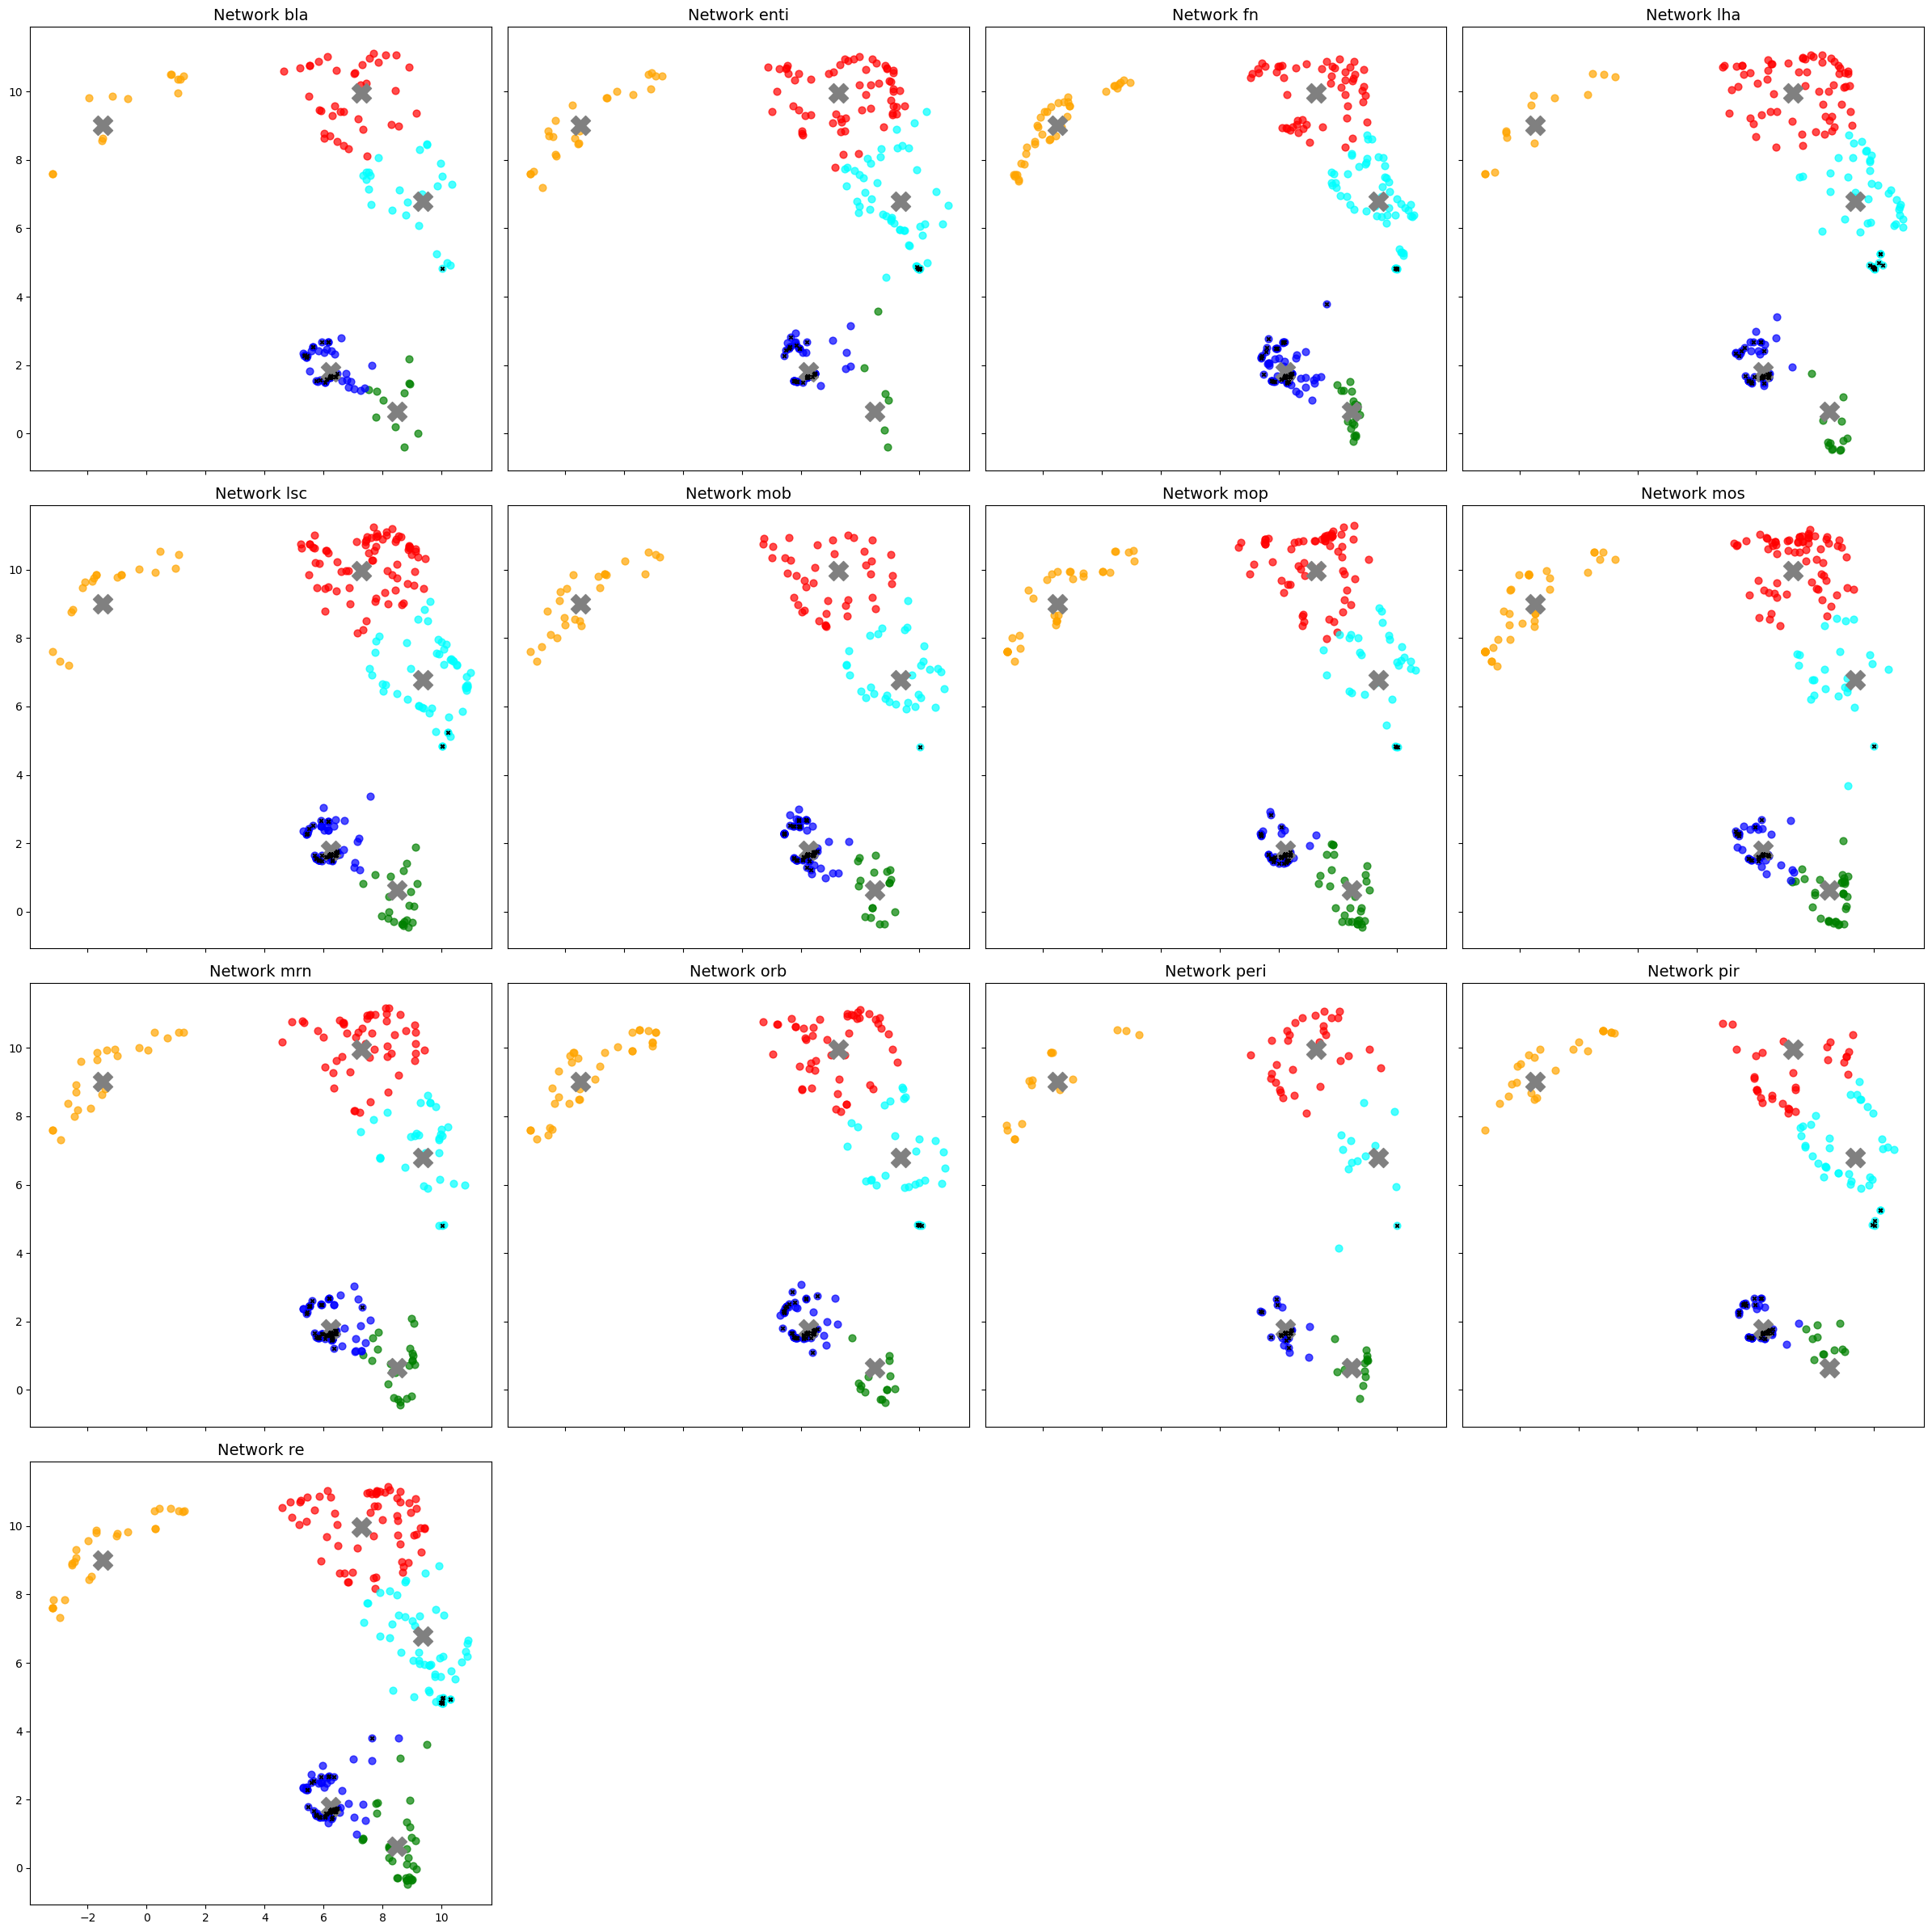

In [ ]:
n_networks = len(embeddings)
n_cols = 4  # number of plots per row
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows), sharex=True, sharey=True)

axes = axes.flatten()

for i, (embed, labels, ax, f_embed) in enumerate(zip(embeddings, network_labels, axes, full_embeddings)):
    for cluster_id in np.unique(labels):
        cluster_points = embed[labels == cluster_id]
        ax.scatter(cluster_points[:,0], cluster_points[:,1],
                   c=colors[cluster_id], s=40, alpha=0.7)
        
        
    ax.scatter(ref_centroids[:,0], ref_centroids[:,1],
               c="gray", marker="X", s=300)
    
    # plot full embedding to see where it lies
    ax.scatter(f_embed[:,0],f_embed[:,1], s=10, c='k',marker='x')

    network_name = Path(file_full[i]).stem.rsplit("_", 1)[-1]
    ax.set_title(f"Network {network_name}", fontsize=14)

# Hide unused axes if networks < n_rows*n_cols
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# plt.suptitle("UMAP Embeddings with Consistent KMeans Clusters", fontsize=5)
plt.tight_layout()
# plt.savefig('../../data/results/fig_5_clusters.pdf',format='pdf')


Find the ratio of points in a specific cluster to all the points in the partial network

In [ ]:
# df_par= reader.data_read_bz2('raw/workstation/pca_results/pca_part_df_fn')
# df_full=reader.data_read_bz2('raw/workstation/pca_results/pca_full_df_fn')

def compute_cluster_count_ratio(df_par,network):

    # removing NaN if any 
    df_par.dropna(inplace=True)

    embedding_part = _reducer.transform(df_par.values)
    part_network_labels = assign_clusters(embedding_part,ref_centroids)
    # print(len(part_network_labels))

    # Assigning cluster labels to data points

    df_embed = pd.DataFrame(embedding_part)

    df_embed['cluster'] = part_network_labels

    df_count = df_embed.groupby('cluster').count()
    cluster_count = df_count[0]
    # print(cluster_count)
    total_count = df_count.sum()[0]
    # print(total_count)
    ratio=cluster_count/total_count
    ratio=ratio.to_frame()
    ratio.columns=[network]
    return ratio


In [ ]:
df_cluster_count = pd.DataFrame()
for f_part in file_part:
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_part.dropna(inplace=True)
    # print(f_part)
    data_part = compute_cluster_count_ratio(df_part,f_part.split('_')[-1])
    df_cluster_count=pd.concat([df_cluster_count,data_part],axis=1)
df_cluster_count

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

,bla,enti,fn,lha,lsc,mob,mop,mos,mrn,orb,peri,pir,re
cluster,,,,,,,,,,,,,
0,0.355140,0.410596,0.284946,0.450000,0.401070,0.310606,0.390244,0.370968,0.344595,0.360294,0.397436,0.290909,0.315
1,0.102804,0.039735,0.112903,0.092857,0.117647,0.136364,0.182927,0.177419,0.162162,0.110294,0.166667,0.100000,0.165
2,0.196262,0.086093,0.129032,0.085714,0.122995,0.121212,0.054878,0.086022,0.128378,0.080882,0.076923,0.072727,0.140
3,0.121495,0.158940,0.204301,0.100000,0.101604,0.189394,0.207317,0.236559,0.155405,0.250000,0.205128,0.218182,0.135
4,0.224299,0.304636,0.268817,0.271429,0.256684,0.242424,0.164634,0.129032,0.209459,0.198529,0.153846,0.318182,0.245


Text(0, 0.5, 'ratio')

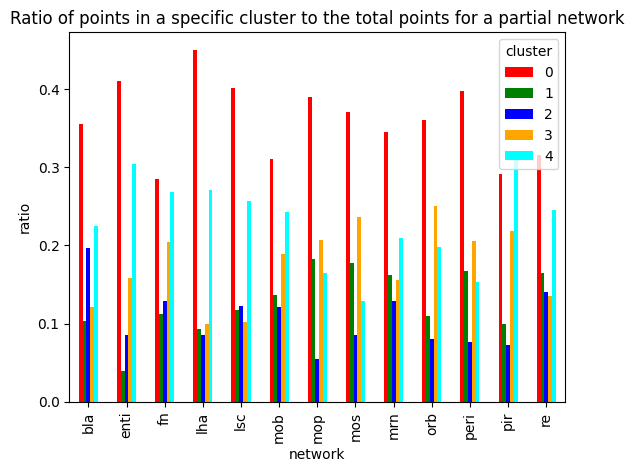

In [59]:

df_cluster_count.T.plot(kind='bar',color=colors)
plt.title('Ratio of points in a specific cluster to the total points for a partial network')
plt.xlabel('network')
plt.ylabel('ratio')

Find ratio of full to partial in a given cluster for a specific network

In [ ]:
# df_par= reader.data_read_bz2('raw/workstation/pca_results/pca_part_df_fn')
# df_full=reader.data_read_bz2('raw/workstation/pca_results/pca_full_df_fn')

def compute_full_part_ratio(df_full,df_par,network):
    expected_clusters=[0,1,2,3,4]
    df_par.dropna(inplace=True)
    df_combined = pd.concat([df_full,df_par],axis=0)

    embedding_full=_reducer.transform(df_full.values)
    embedding_part = _reducer.transform(df_par.values)

    whole_embedding = np.concatenate((embedding_full, embedding_part), axis=0)

    # assign cluster labels
    whole_cluster_labels = assign_clusters(whole_embedding,ref_centroids)

    df_embed = pd.DataFrame(whole_embedding)
    df_embed['cluster']=whole_cluster_labels

    df_full_cluster = df_embed.iloc[0:df_full.shape[0]]
    df_full_cluster_count = df_full_cluster.groupby('cluster').count()
    fc_count = df_full_cluster_count[0].to_frame()
    fc_count=fc_count.reindex(expected_clusters,fill_value=0)
    # print(fc_count)


    df_part_cluster = df_embed.iloc[df_full.shape[0]:]
    df_part_cluster_count = df_part_cluster.groupby('cluster').count()
    fp_count = df_part_cluster_count[0].to_frame()
    fp_count=fp_count.reindex(expected_clusters,fill_value=0)
    # print(fp_count)

    ratio = (fc_count/fp_count)
    ratio.columns=[network]
    return ratio
# ratio.columns=[network]



In [ ]:
df_parfull_ratio = pd.DataFrame()
for f_full,f_part in zip(file_full,file_part):
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    # df_part.dropna(inplace=True)
    # print(f_part)
    data_part = compute_full_part_ratio(df_full,df_part,f_part.split('_')[-1])
    df_parfull_ratio=pd.concat([df_parfull_ratio,data_part],axis=1)
df_parfull_ratio

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

,bla,enti,fn,lha,lsc,mob,mop,mos,mrn,orb,peri,pir,re
cluster,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2.380952,3.923077,4.041667,3.666667,4.086957,5.81250,7.666667,2.562500,4.105263,8.090909,7.666667,7.750000,2.964286
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.041667,0.130435,0.120000,0.289474,0.062500,0.03125,0.111111,0.041667,0.032258,0.185185,0.083333,0.142857,0.183673


Text(0, 0.5, 'ratio')

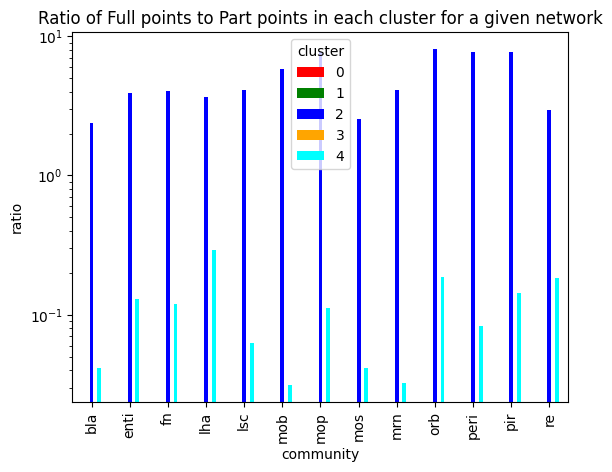

In [63]:

df_parfull_ratio.T.plot(kind='bar',color=colors,logy=True)
plt.title('Ratio of Full points to Part points in each cluster for a given network')
plt.xlabel('community')
plt.ylabel('ratio')

Find cluster community wise mean

In [ ]:

def compute_cluster_comm_partcptn(df_f,df_p,n):
    df_p.dropna(inplace=True)
    df_combined = pd.concat([df_f,df_p],axis=0)
    # print(df_f.shape)
    # print(df_p.shape)
    # print(df_combined.shape)

    df_combined['cluster']=network_labels[n]
    # print(df_combined.shape)

    # removing df_full rows from combined
    df_work=df_combined.iloc[df_f.shape[0]:,:]
    # print(df_work.shape)
    # df_work.head()

    # take average clusterwise for each column

    communities = list(df_work.columns[:-1])
    # print(communities)
    cluster_data = pd.DataFrame()
    for comm in communities:
        # print(comm)
        df_cluster = df_work.groupby('cluster')[comm].mean()
        cluster_data=pd.concat([cluster_data,df_cluster],axis=1)

    # Plot bar chart using cluster data
    # take avg of each cluster excluding hind
    # print(cluster_data)
    avg_0 = cluster_data.loc[0][:-1].mean()
    avg_1 = cluster_data.loc[1][:-1].mean()
    avg_2 = cluster_data.loc[2][:-1].mean()

    # comment when using 3 clusters only
    avg_3 = cluster_data.loc[3][:-1].mean()
    avg_4 = cluster_data.loc[4][:-1].mean()

    # Normalizing each cluster 
    c_0 = cluster_data.loc[0]/avg_0
    c_1 = cluster_data.loc[1]/avg_1
    c_2 = cluster_data.loc[2]/avg_2

    # comment when using 3 clusters
    c_3 = cluster_data.loc[3]/avg_3
    c_4 = cluster_data.loc[4]/avg_4

    # print(cluster_data.head(3))
    # Updating cluster data to plot
    cluster_data.loc[0]=c_0
    cluster_data.loc[1]=c_1
    cluster_data.loc[2]=c_2

    # comment when using 3 clusters
    cluster_data.loc[3]=c_3
    cluster_data.loc[4]=c_4
    
    # cluster_data.head(3)
    cluster_plot = cluster_data.copy()

    # cluster_plot.head()
    # print(cluster_plot)
    return cluster_plot
    



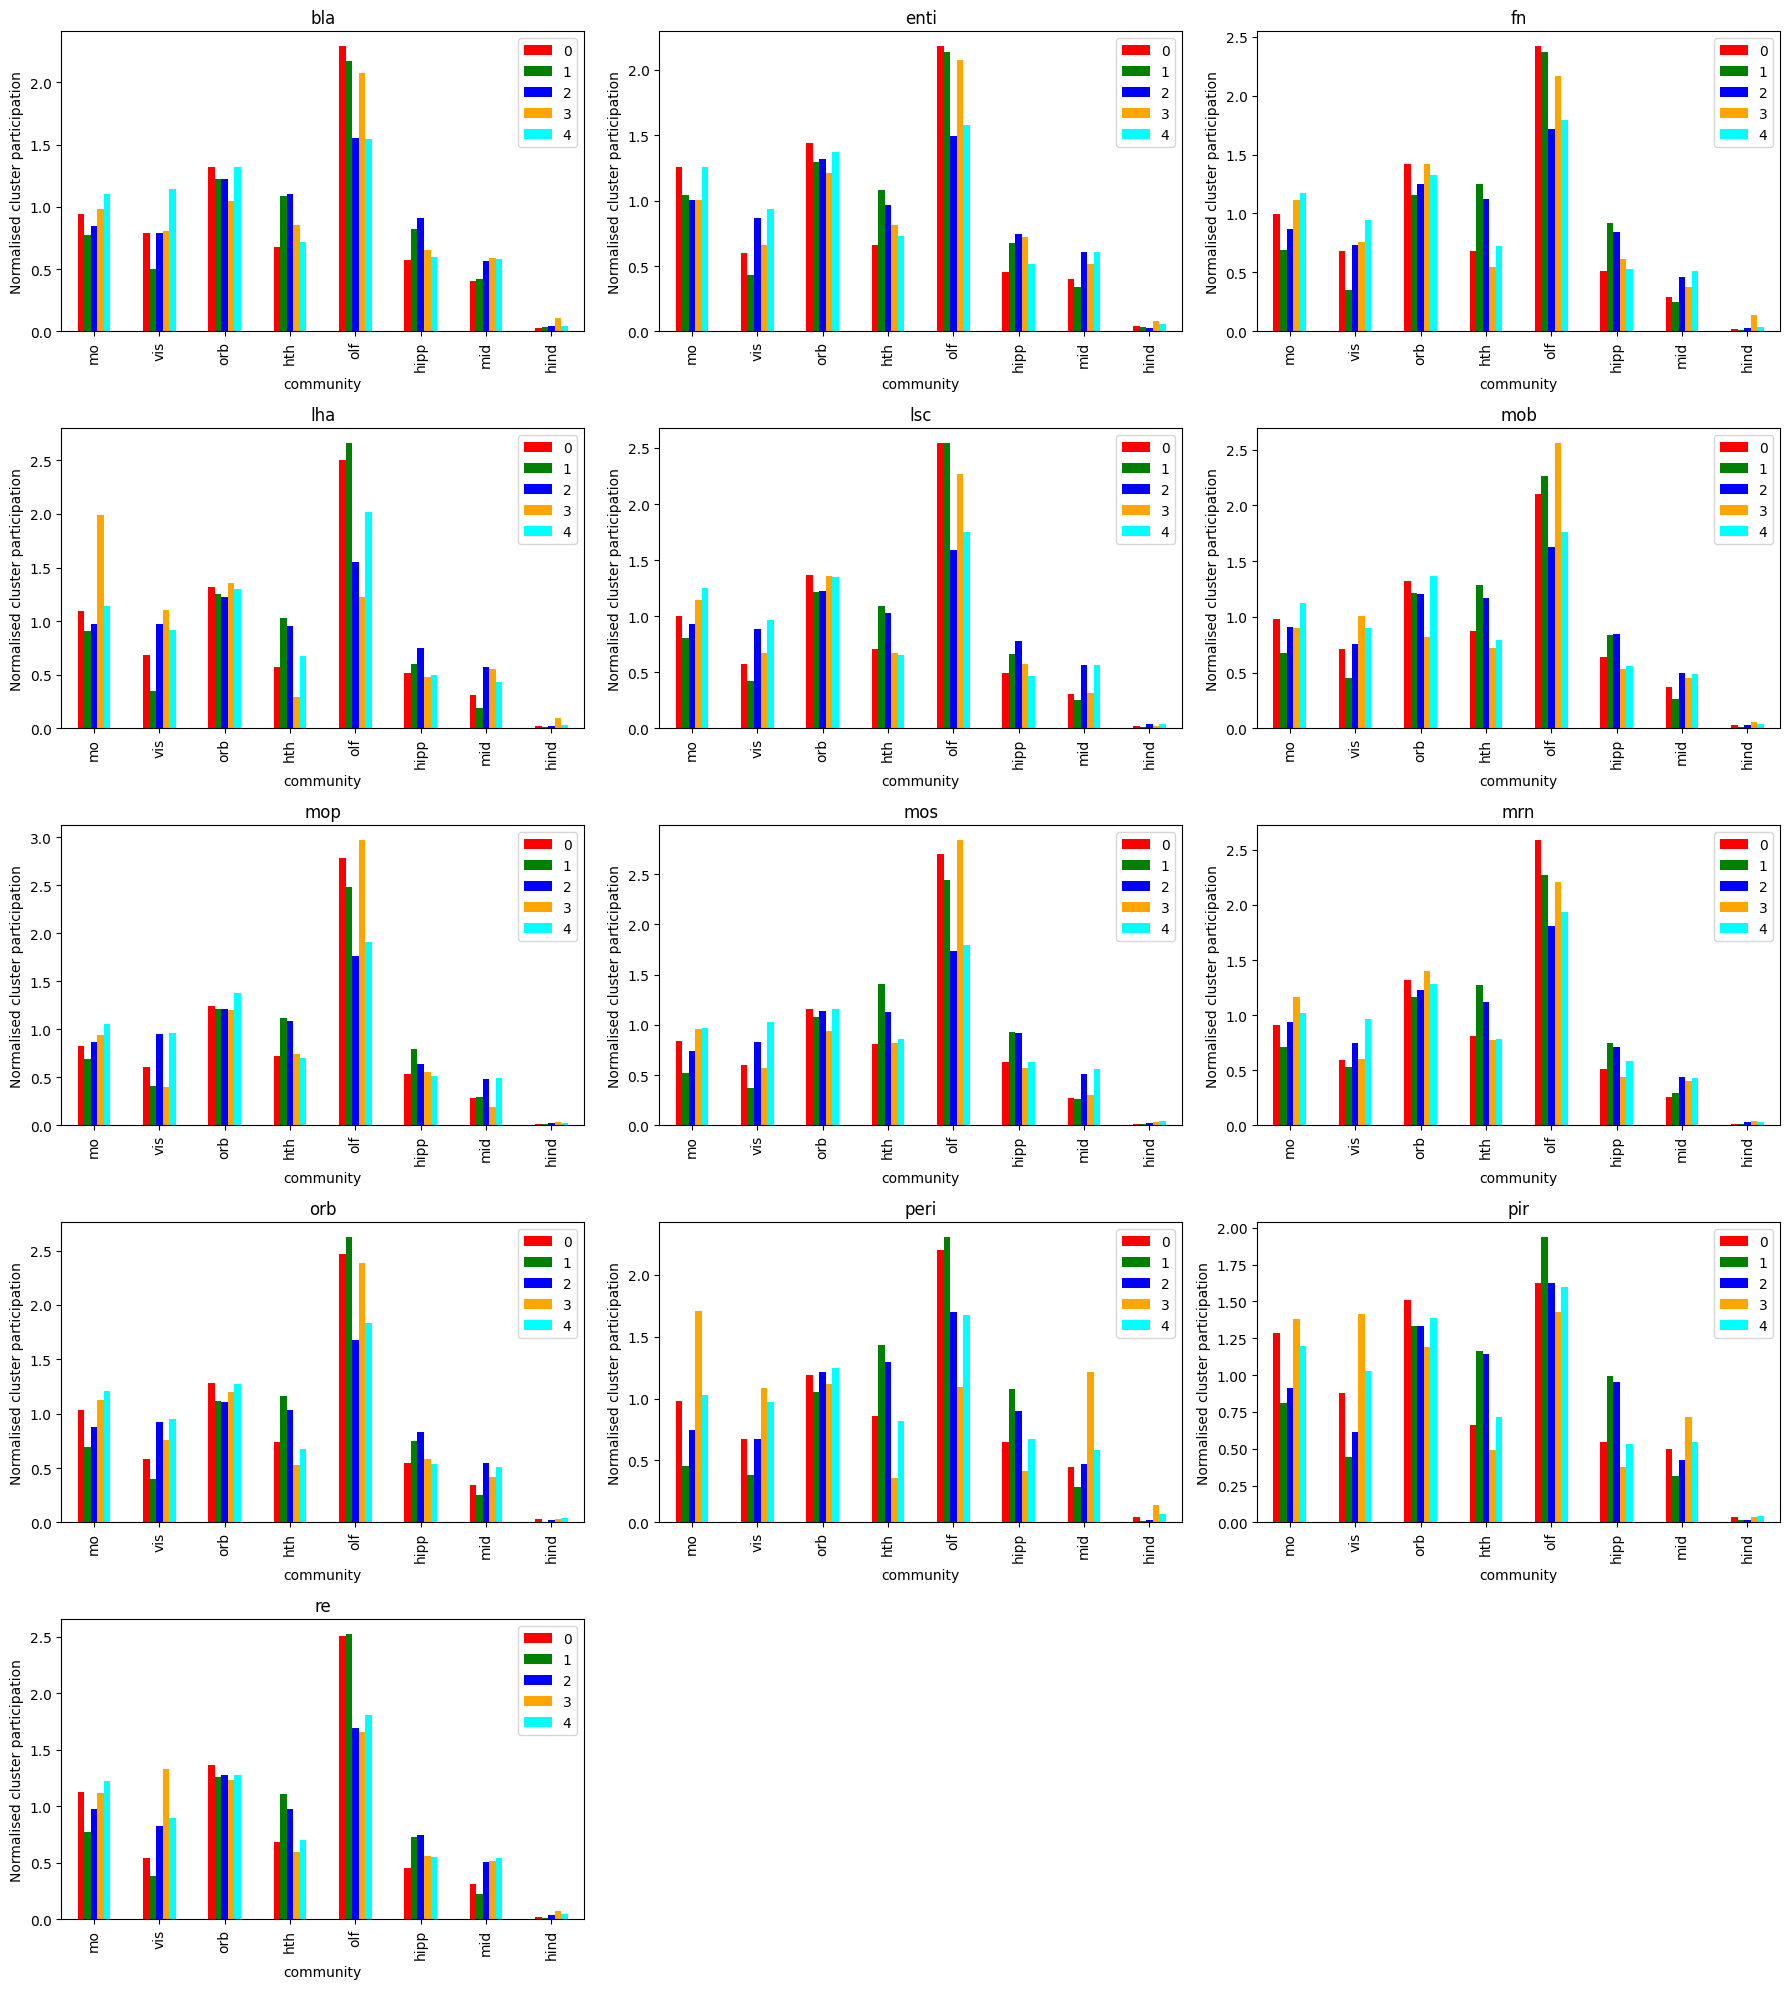

In [ ]:
import math

n_files = len(file_full)   # should be 13
n_cols = 3                 # number of columns you want
n_rows = math.ceil(n_files / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()   # flatten to 1D array for easy looping

cluster_colors = {0: "red", 1: "green", 2: "blue", 3: "orange", 4: "cyan"}

for n, (f_full, f_part, ax) in enumerate(zip(file_full, file_part, axes)):
    df_f = pd.read_pickle(f_full, compression='bz2')
    df_p = pd.read_pickle(f_part, compression='bz2')
    
    clusterData = compute_cluster_comm_partcptn(df_f, df_p, n)
    
    clusterData.T.plot(
        kind='bar',
        ax=ax,
        color=[cluster_colors.get(c, "gray") for c in clusterData.T.columns]
    )
    
    ax.set_xlabel('community')
    ax.set_ylabel('Normalised cluster participation')
    ax.set_title(file_full[n].split('_')[-1])

# Hide any unused subplots if n_files doesn’t fill the grid
for ax in axes[n_files:]:
    ax.set_visible(False)

plt.tight_layout()

# plt.savefig('../../data/results/fig_5_cluster_bar.pdf',format='pdf')


In [ ]:
cluster_part=[]
network_names=[]

# to store avg community participation for a cluster


for n,(f_full,f_part) in enumerate(zip(file_full,file_part)):
    df_f = pd.read_pickle(f_full, compression='bz2')
    df_p = pd.read_pickle(f_part, compression='bz2')
    
    network_names.append(f_full.split('_')[-1])
    clusterData = compute_cluster_comm_partcptn(df_f, df_p, n)
    cluster_part.append(clusterData.values)

column_header = clusterData.columns
print(network_names)


    


    


['bla', 'enti', 'fn', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']


In [ ]:
# from each network cluster, extract communities

c_0_parcptn=pd.DataFrame()
c_1_parcptn=pd.DataFrame()
c_2_parcptn=pd.DataFrame()
c_3_parcptn=pd.DataFrame()
c_4_parcptn=pd.DataFrame()

for clus_data,nw in zip(cluster_part,network_names):
    df_clus = pd.DataFrame(clus_data)
    df_clus.columns = column_header

    
    # for cluster 0
    row_c0=df_clus.loc[0].to_frame().T
    row_c0.index=[nw]
    c_0_parcptn=pd.concat([c_0_parcptn,row_c0],axis=0)
    

    #for cluster 1
    row_c1=df_clus.loc[1].to_frame().T
    row_c1.index=[nw]
    c_1_parcptn=pd.concat([c_1_parcptn,row_c1],axis=0)

    #for cluster 2
    row_c2=df_clus.loc[2].to_frame().T
    row_c2.index=[nw]
    c_2_parcptn=pd.concat([c_2_parcptn,row_c2],axis=0)
    
    #for cluster 3
    row_c3=df_clus.loc[3].to_frame().T
    row_c3.index=[nw]
    c_3_parcptn=pd.concat([c_3_parcptn,row_c3],axis=0)

    #for cluster 4
    row_c4=df_clus.loc[4].to_frame().T
    row_c4.index=[nw]
    c_4_parcptn=pd.concat([c_4_parcptn,row_c4],axis=0)



        


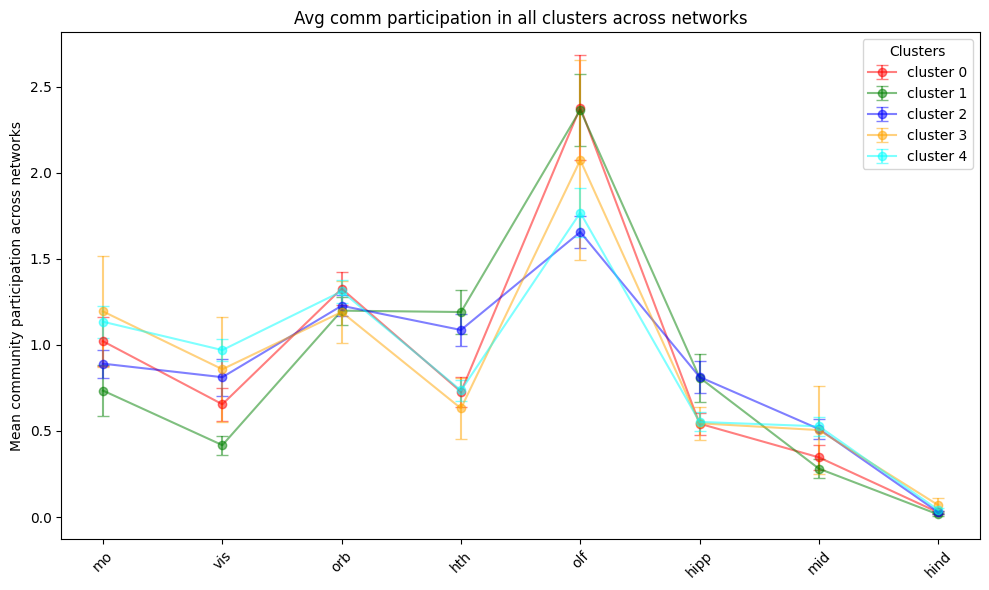

In [ ]:


# Your cluster DataFrames
dfs = [c_0_parcptn, c_1_parcptn, c_2_parcptn, c_3_parcptn, c_4_parcptn]

# Define cluster colors
cluster_colors = {0: "red", 1: "green", 2: "blue", 3: "orange", 4: "cyan"}

plt.figure(figsize=(10,6))

for i, df in enumerate(dfs, start=0):
    # Vertical mean (row-wise mean for each column)
    mean_vals = df.mean(axis=0)
    # Vertical standard deviation
    std_vals = df.std(axis=0)

    # Plot with error bars, using your chosen cluster color
    plt.errorbar(df.columns, mean_vals, yerr=std_vals,
                 label=f'cluster {i}',
                 color=cluster_colors[i],
                 capsize=4, marker='o', linestyle='-', alpha=0.5)

plt.xticks(rotation=45)
plt.ylabel("Mean community participation across networks")
plt.title("Avg comm participation in all clusters across networks")
plt.legend(title="Clusters")
plt.tight_layout()
plt.show()




## Compute clusterwise params

Use this file which contains iteration number and the transition in it for every network  
Saved in 'results/comm_umap_results/part_full_comm_ind.pkl'

- Network based iteration number and index result
- Tuple index is row number of your 'trans x 8' file
- Tuple 1st element is iteration number
- Tuple 2nd element is the index number of the transition in that iteration

In [10]:
nw_itr= reader.data_read_pkl('results/comm_umap_results/part_full_comm_ind.pkl')

Peek inside above file

In [45]:
# nw_itr.keys()    
# ['bla', 'enti', 'fn', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']
# nw_itr['bla'].keys()
# ['part_ind', 'full_ind']
# nw_itr['bla']['full_ind']    
# list of tuples

Define function which labels each transition by it's cluster  
INPUT: trans x 8, nw_itr, _reducer, ref_centroids  
OUTPUT:   Cluster indices i.e row index of trans x 8  

In [76]:
df_par= reader.data_read_bz2('results/comm_umap_results/pca_full_df_fn')

In [ ]:
def compute_cluster_indices(df,nw_itr,_reducer, ref_centroids, nw, trans_type):
    """Compute index of rows of df specific to a cluster

    Args:
        df (dataframe): number of transitions x 8 (Community wise participation for each transition)
        nw_itr (dict): Contains iteration number and the transition in it for all networks (Partial and Full transitions both)
        _reducer (UMAP): UMAP reduced on partial FN data
        ref_centroids (nd array): Centroids as per FN data after clustering
        nw (string): ['bla', 'enti', 'fn', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']
        trans_type (string): ['part_ind', 'full_ind']

    Returns:
        dictionary: keys: 'cluster_ind',''new_ind'
    """
    i_part=nw_itr[nw][trans_type].copy()
    # find NaN rows index of entries x 8 vector space
    nan_indices = df.index[df.isnull().any(axis=1)].tolist()

    # removing the NaN row
    if not nan_indices:
        pass
        new_ind=i_part
    else:
        # dropping NaN value
        df.dropna(inplace = True)
        # removing nan entries from nw_itr of given network
        
        for i in nan_indices:
            new_ind = [val for i, val in enumerate(i_part) if i not in nan_indices]

    

    embedding = _reducer.transform(df.values)
    network_labels = assign_clusters(embedding,ref_centroids)

    # assigning cluster labels to our 186 x2 vector space  
    df_embed = pd.DataFrame(embedding)
    df_embed['cluster'] = network_labels

    cluster_indices = {c: df_embed.index[df_embed['cluster'] == c].tolist() for c in df_embed['cluster'].unique()}
    
    return {'cluster_ind':cluster_indices,'nw_new':new_ind}



   

In [78]:
l=compute_cluster_indices(df_par,nw_itr,_reducer,ref_centroids,'fn','full_ind')


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [79]:
l['cluster_ind'].keys()

dict_keys([2, 4])

Define function which computes parameters clusterwise

In [ ]:
def compute_cluster_params(cluster_indices,new_ind,df_go,df_nc):
    """Computes cluster wise params and stores them in dict

    Args:
        cluster_indices (_type_): _description_
        new_ind (_type_): _description_
        df_go (_type_): _description_
        df_nc (_type_): _description_

    Returns:
        _type_: _description_
    """
    clus_params={}
    for i in list(l['cluster_ind'].keys()):

        # saving clusterwise params data
        fpt=[]
        st=[]
        cov=[]
        tt=[]
        for ind in cluster_indices[i]:
            

            # getting actual iteration number
            itrn = new_ind[ind]
            
            # compute params
            pts=algo_umap.compute_parameters(df_go[itrn[0]])
            fpt_list=algo.compute_fpt(pts['start_points'].copy(),pts['stop_points'].copy())[itrn[1]]
            fpt.append(fpt_list)
            st_list = algo.compute_sync(pts['start_points'].copy(),pts['stop_points'].copy())
            if itrn[1]  < len(st_list):
                # consider case when transition doesn't falls back
                st.append(st_list[itrn[1]])
            
            cov_list = comm_ops.compute_individual_coverage_nc(df_nc.loc[itrn[0]], df_go[itrn[0]])[itrn[1]]
            cov.append(cov_list)
            tt_list = algo_umap.compute_transition_time(df_go[itrn[0]],pts['start_points'].copy())[itrn[1]]
            tt.append(tt_list)

        clus_params[i]={'fpt':fpt,'st':st, 'cov':cov, 'tt':tt}
    return clus_params
        

In [81]:
df_go = reader.data_read_bz2('raw/workstation/tes_fn_go.bz2')
df_nc = reader.data_read_bz2('raw/workstation/tes_fn_nc.bz2')

In [82]:
f_full=compute_cluster_params(l['cluster_ind'],l['nw_new'],df_go,df_nc)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

#### Compute for full params clusterwise

In [7]:
data_folder=Path('../../data/results/comm_umap_results/')
file_full=glob.glob(str(data_folder/'pca_full_df_*'))
file_part=glob.glob(str(data_folder/'pca_part_df_*'))



In [8]:
data_folder = Path('../../data/raw/workstation')
file_go =glob.glob(str(data_folder/'tes_*_go.bz2'))
file_nc=glob.glob(str(data_folder/'tes_*_nc.bz2'))

In [108]:
f_name = file_full[0]

In [109]:
f_name.split('_')[-1]

'bla'

In [ ]:
for f_full,f_part,f_go,f_nc in zip(file_full,file_part,file_go,file_nc):
    nw=f_full.split('_')[-1]
    
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_go=pd.read_pickle(f_go,compression='bz2')
    df_nc=pd.read_pickle(f_nc,compression='bz2')
    # computing full
    l=compute_cluster_indices(df_full,nw_itr,_reducer,ref_centroids,nw,'full_ind')
    f_full=compute_cluster_params(l['cluster_ind'],l['nw_new'],df_go,df_nc)
    # save
    reader.data_dump_pkl(f'results/comm_umap_results/comm_wise_params/full_{nw}',f_full)


    #computing part
    l=compute_cluster_indices(df_part,nw_itr,_reducer,ref_centroids,nw,'part_ind')
    f_part=compute_cluster_params(l['cluster_ind'],l['nw_new'],df_go,df_nc)
    reader.data_dump_pkl(f'results/comm_umap_results/comm_wise_params/part_{nw}',f_part)


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

...

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


this cell
this cell
this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


this cell
this cell
this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


#### Read cluster wise params and plot

In [ ]:
def plot_params(data,label):
    """Plots violinplots for every parameter clusterwise

    Args:
        data (dictionary): cluster wise param data
        label (string): network name
    """

    fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(15, 15))
    key_list=['fpt', 'st', 'cov', 'tt']
    for i in list(data.keys()):              # outer loop (rows)
        for j in range(4):
                    # inner loop (columns)
            ax = axes[i, j]         # select subplot
            plt_data = data[i][key_list[j]]  # get the data from dictionary

            # Example: violin plot
            if plt_data:
                ax.violinplot(plt_data, showmedians=True)
                ax.set_title(f"cluster {i}, {key_list[j]}")
            else:
                ax.text(0.5, 0.5, "Empty", ha='center')

    plt.suptitle(f'Cluster wise {label}')
    plt.tight_layout()
    plt.savefig(f'../../data/results/comm_umap_results/comm_wise_params/cw_{label}.pdf', format='pdf')
    
    
    
    plt.show()


    

In [8]:
data_folder = Path('../../data/results/comm_umap_results/comm_wise_params')
file_full = glob.glob(str(data_folder/'full_*'))
file_part = glob.glob(str(data_folder/'part_*'))



full_bla


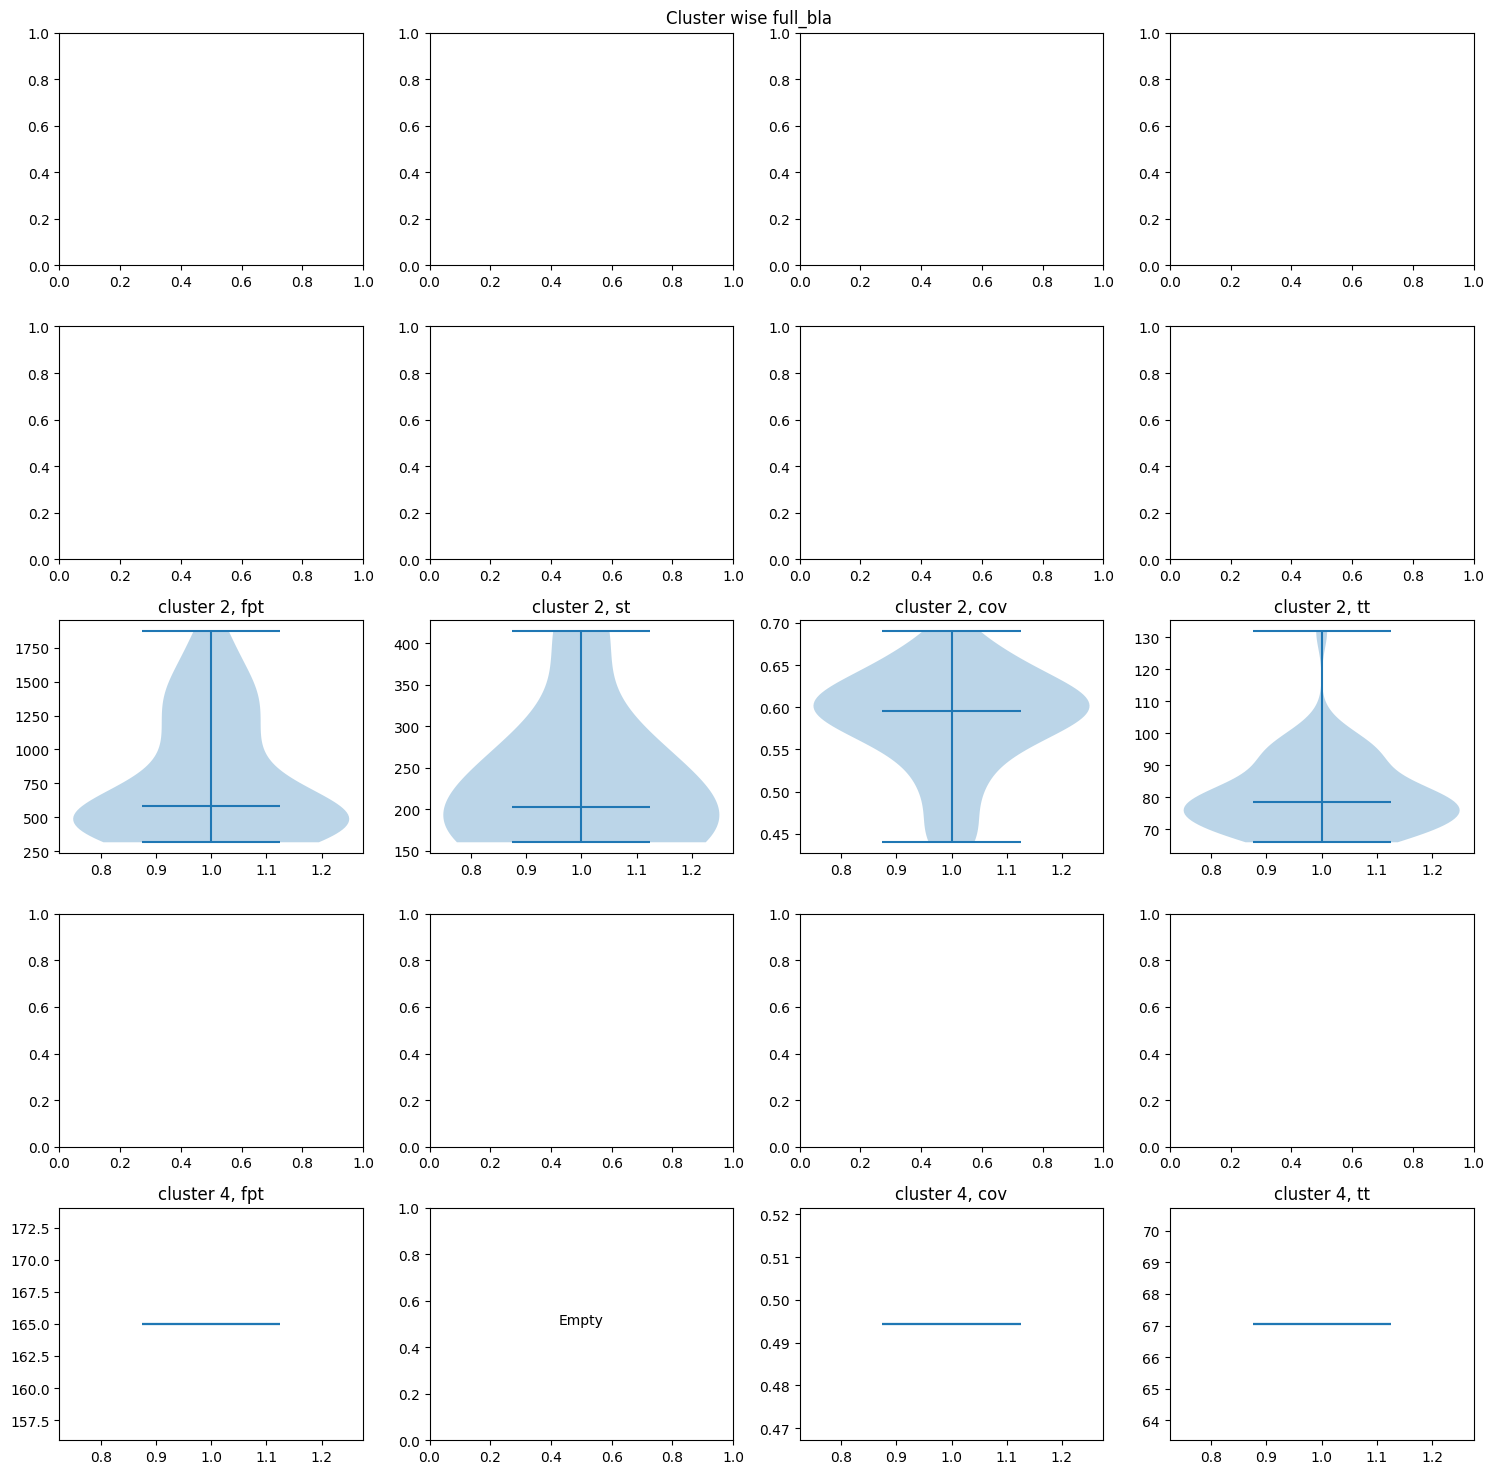

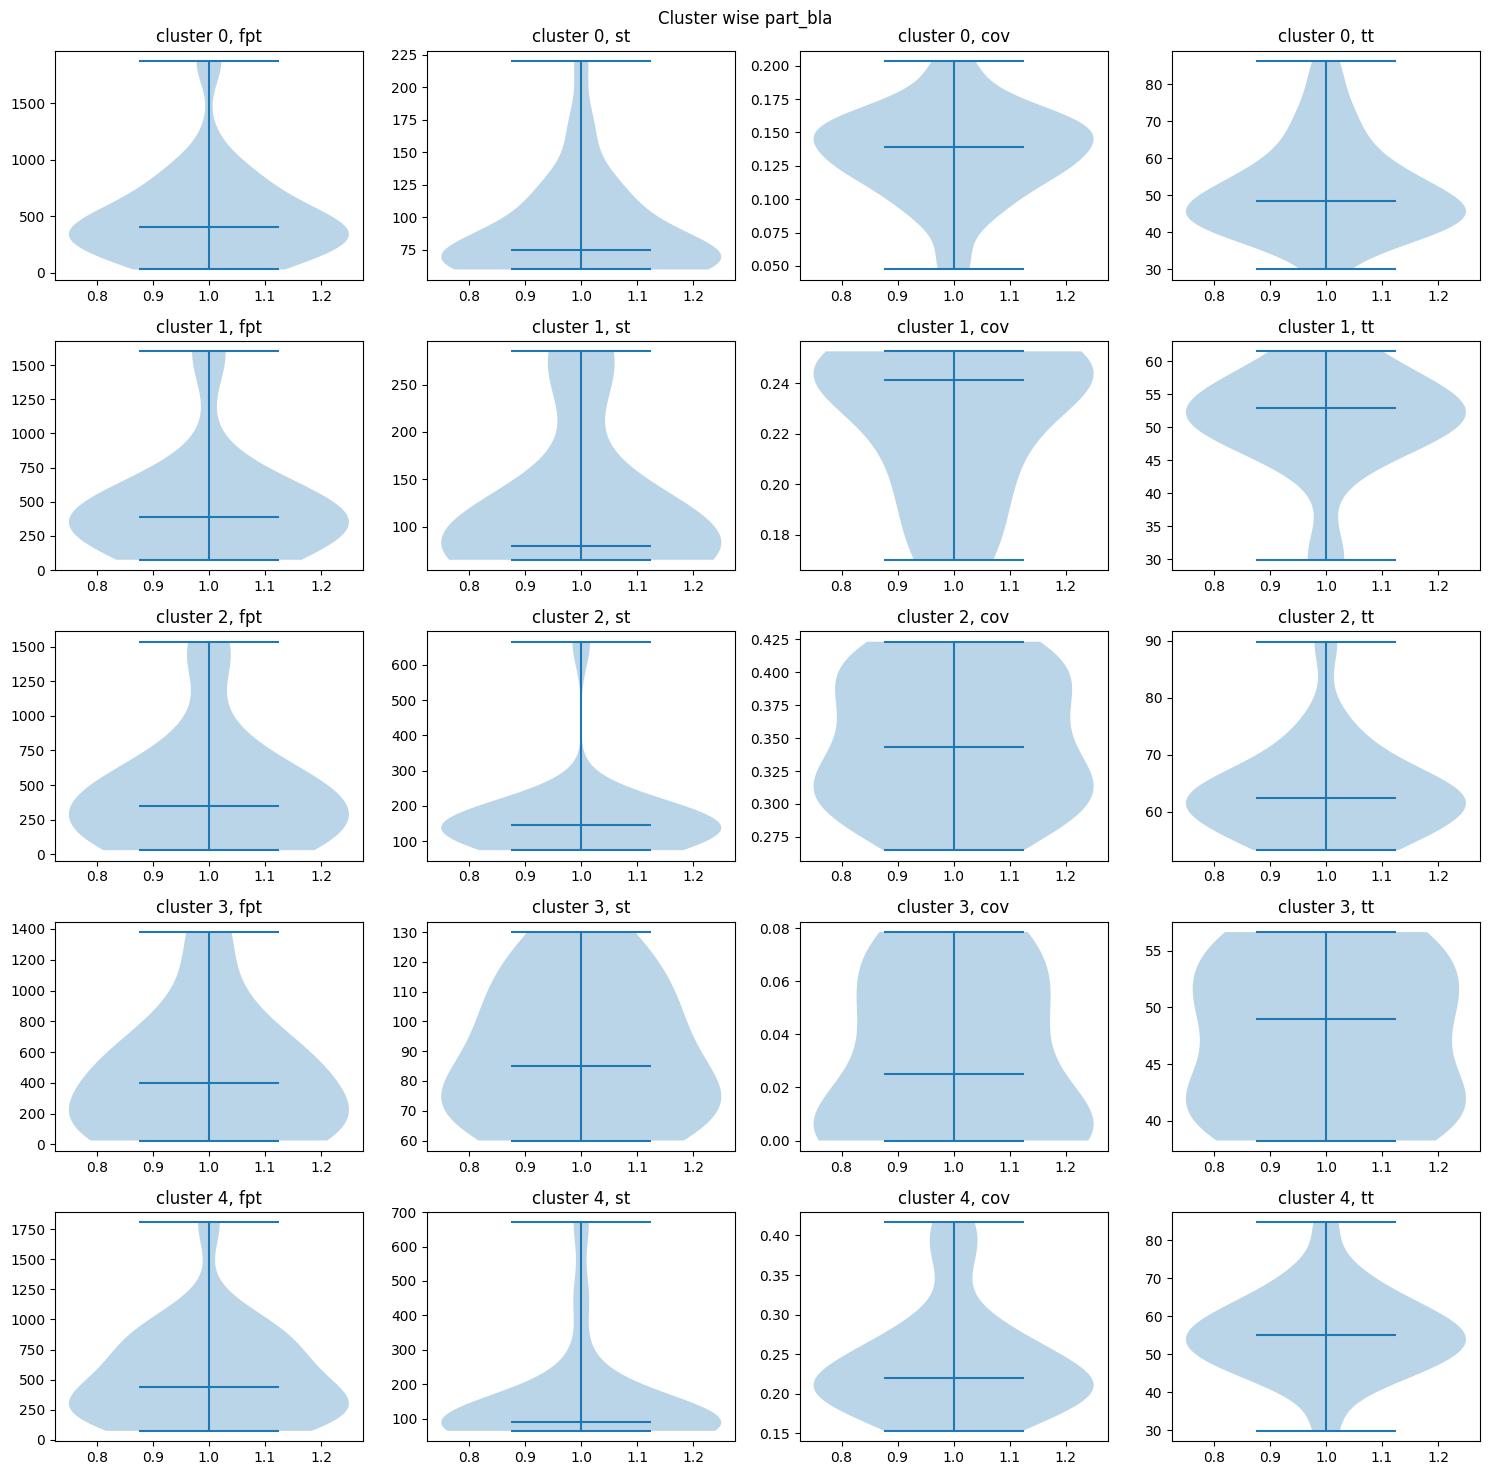

full_bla
full_enti


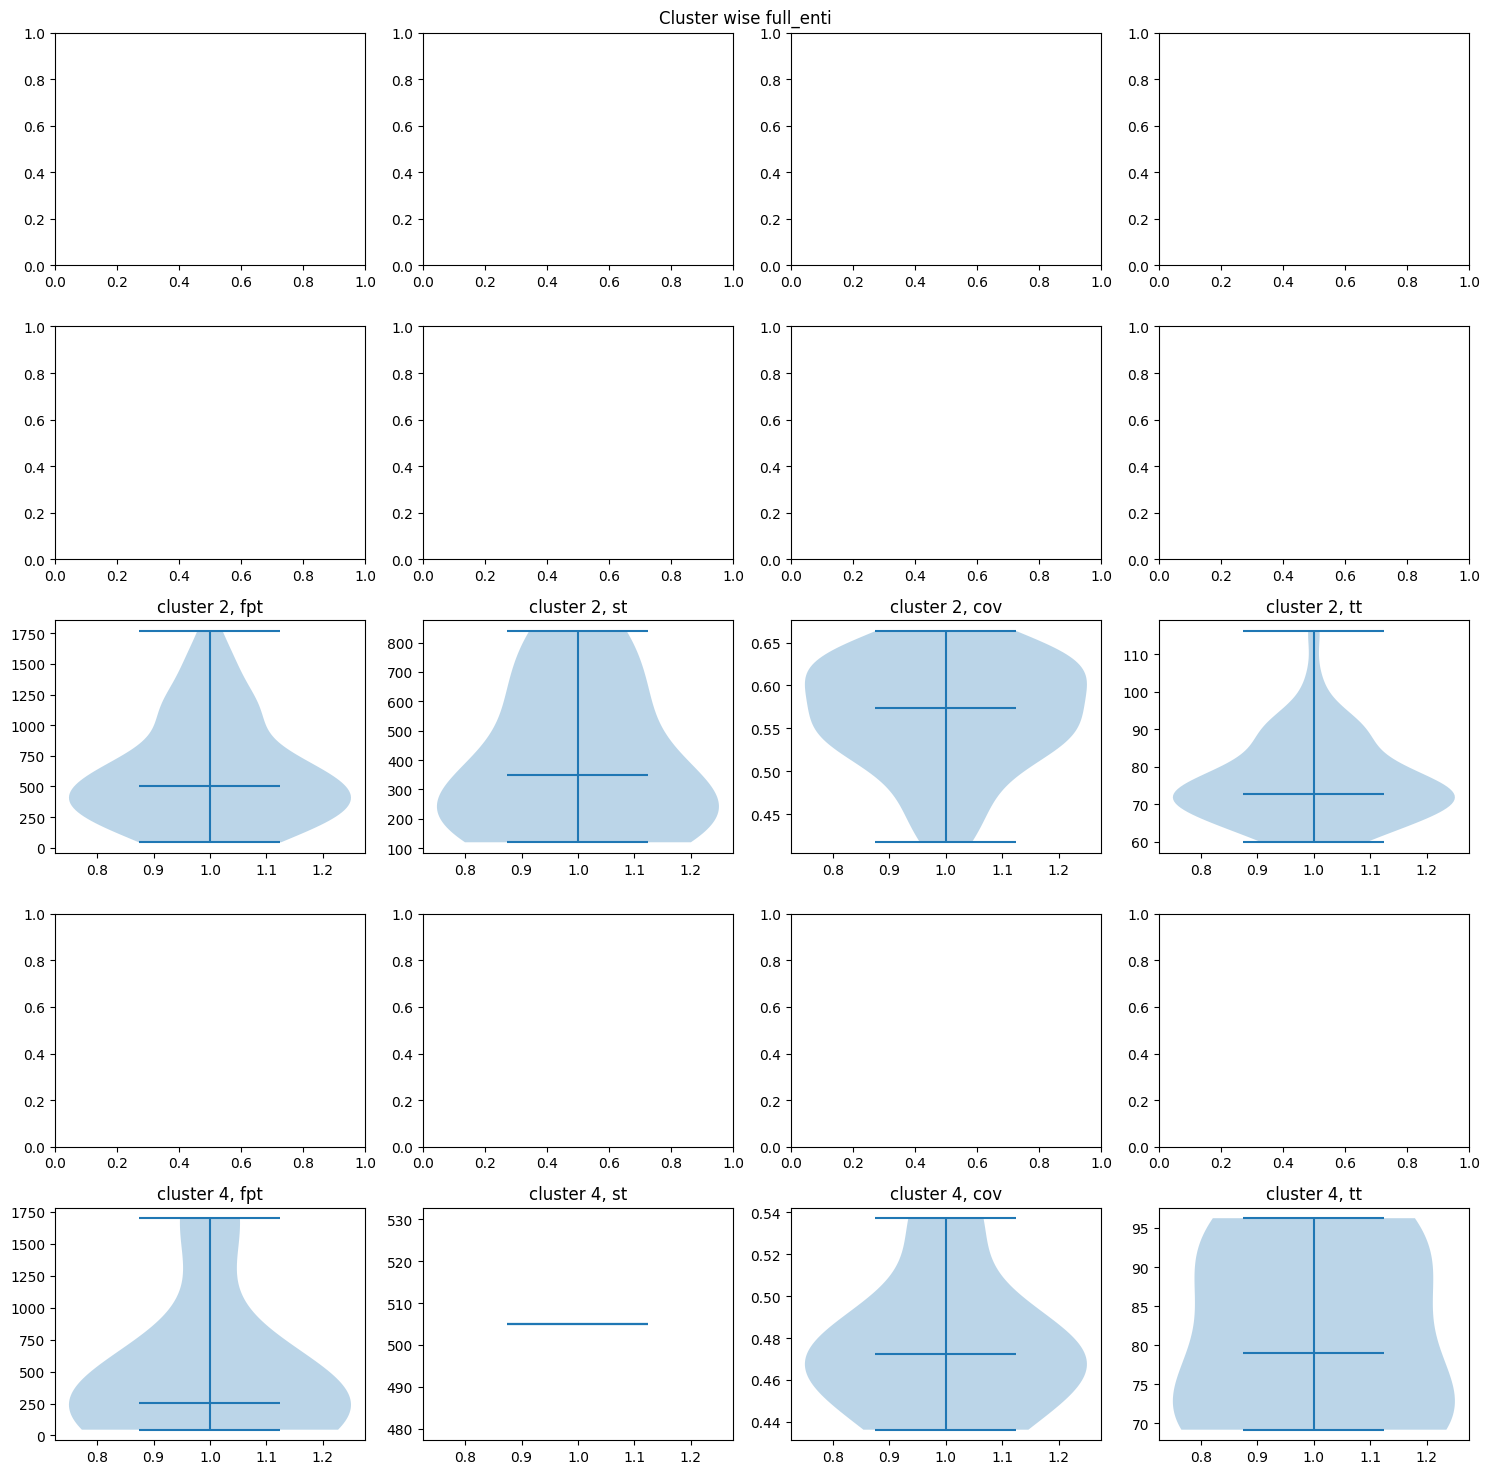

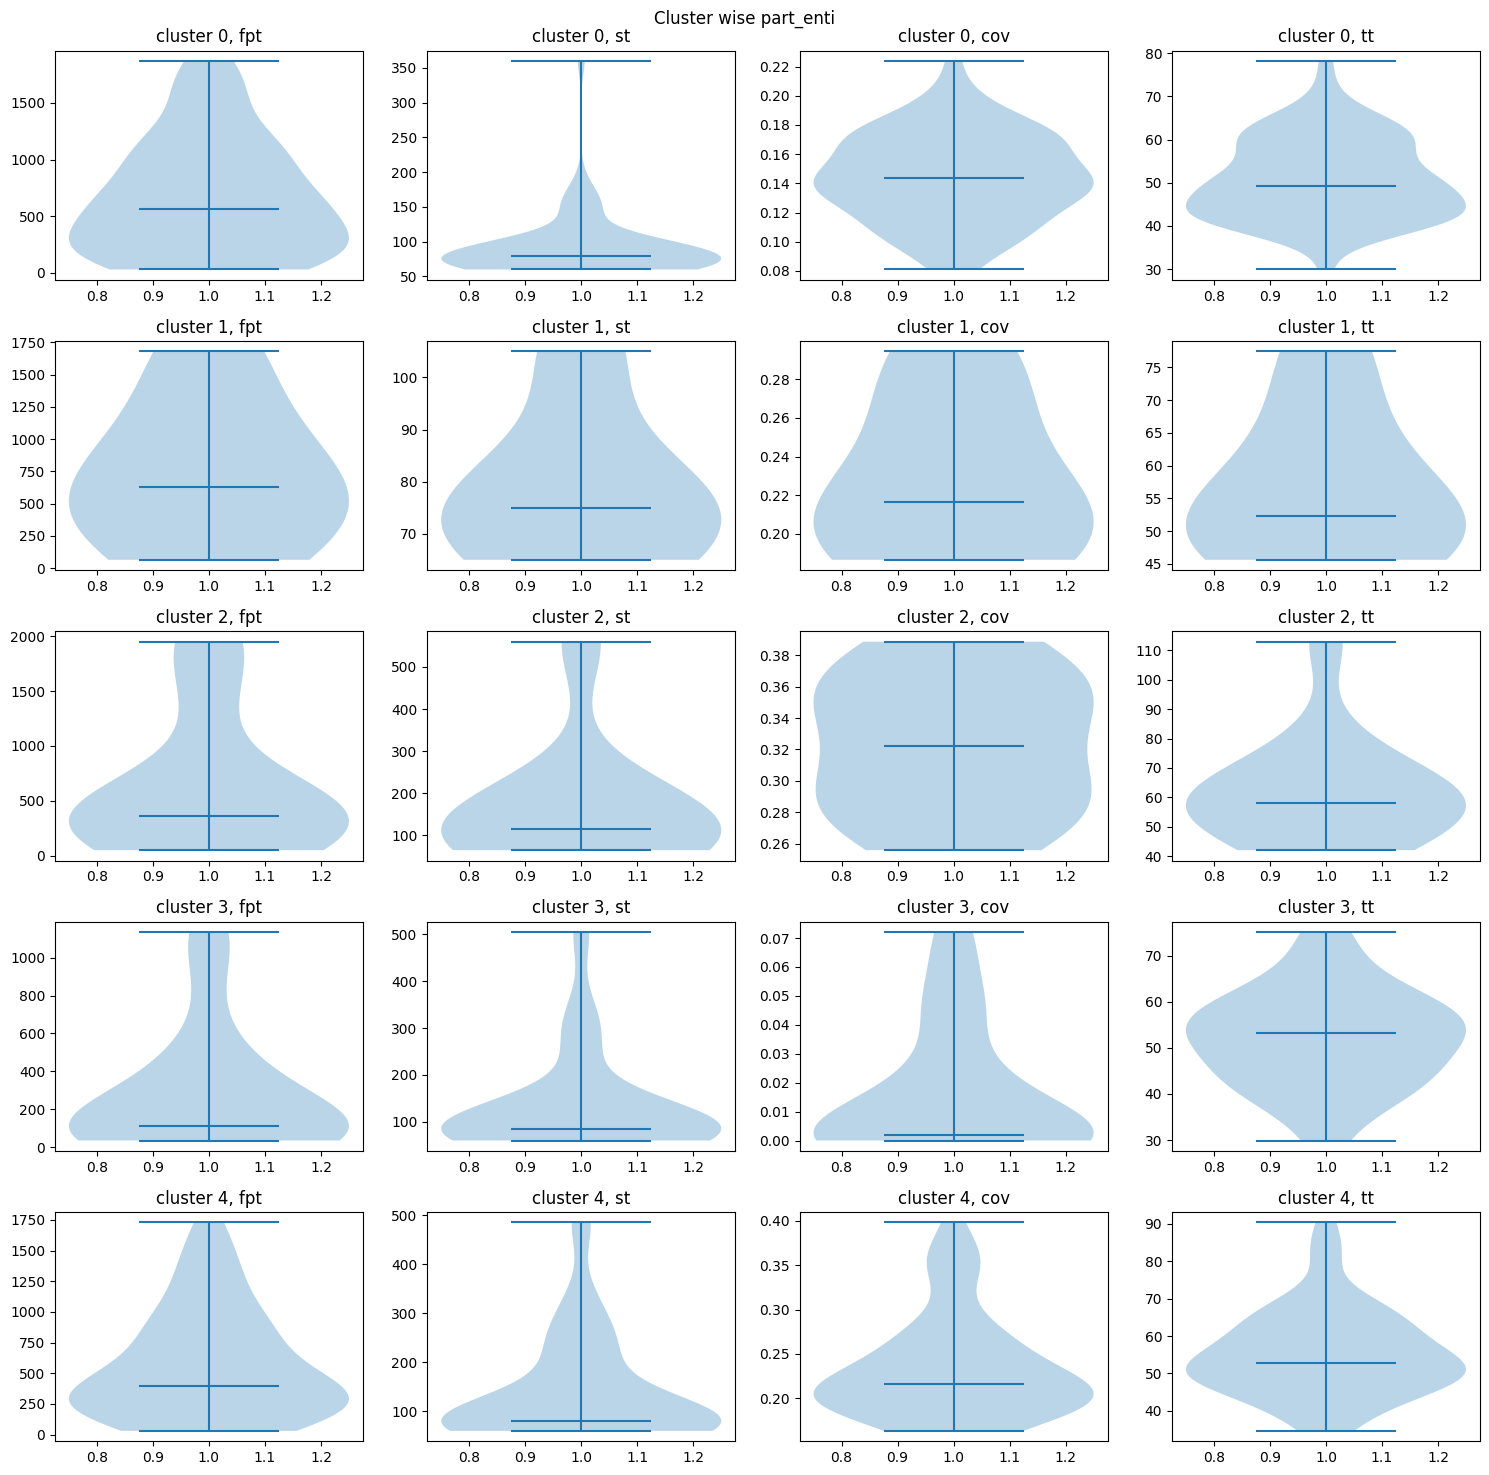

full_enti
full_fn


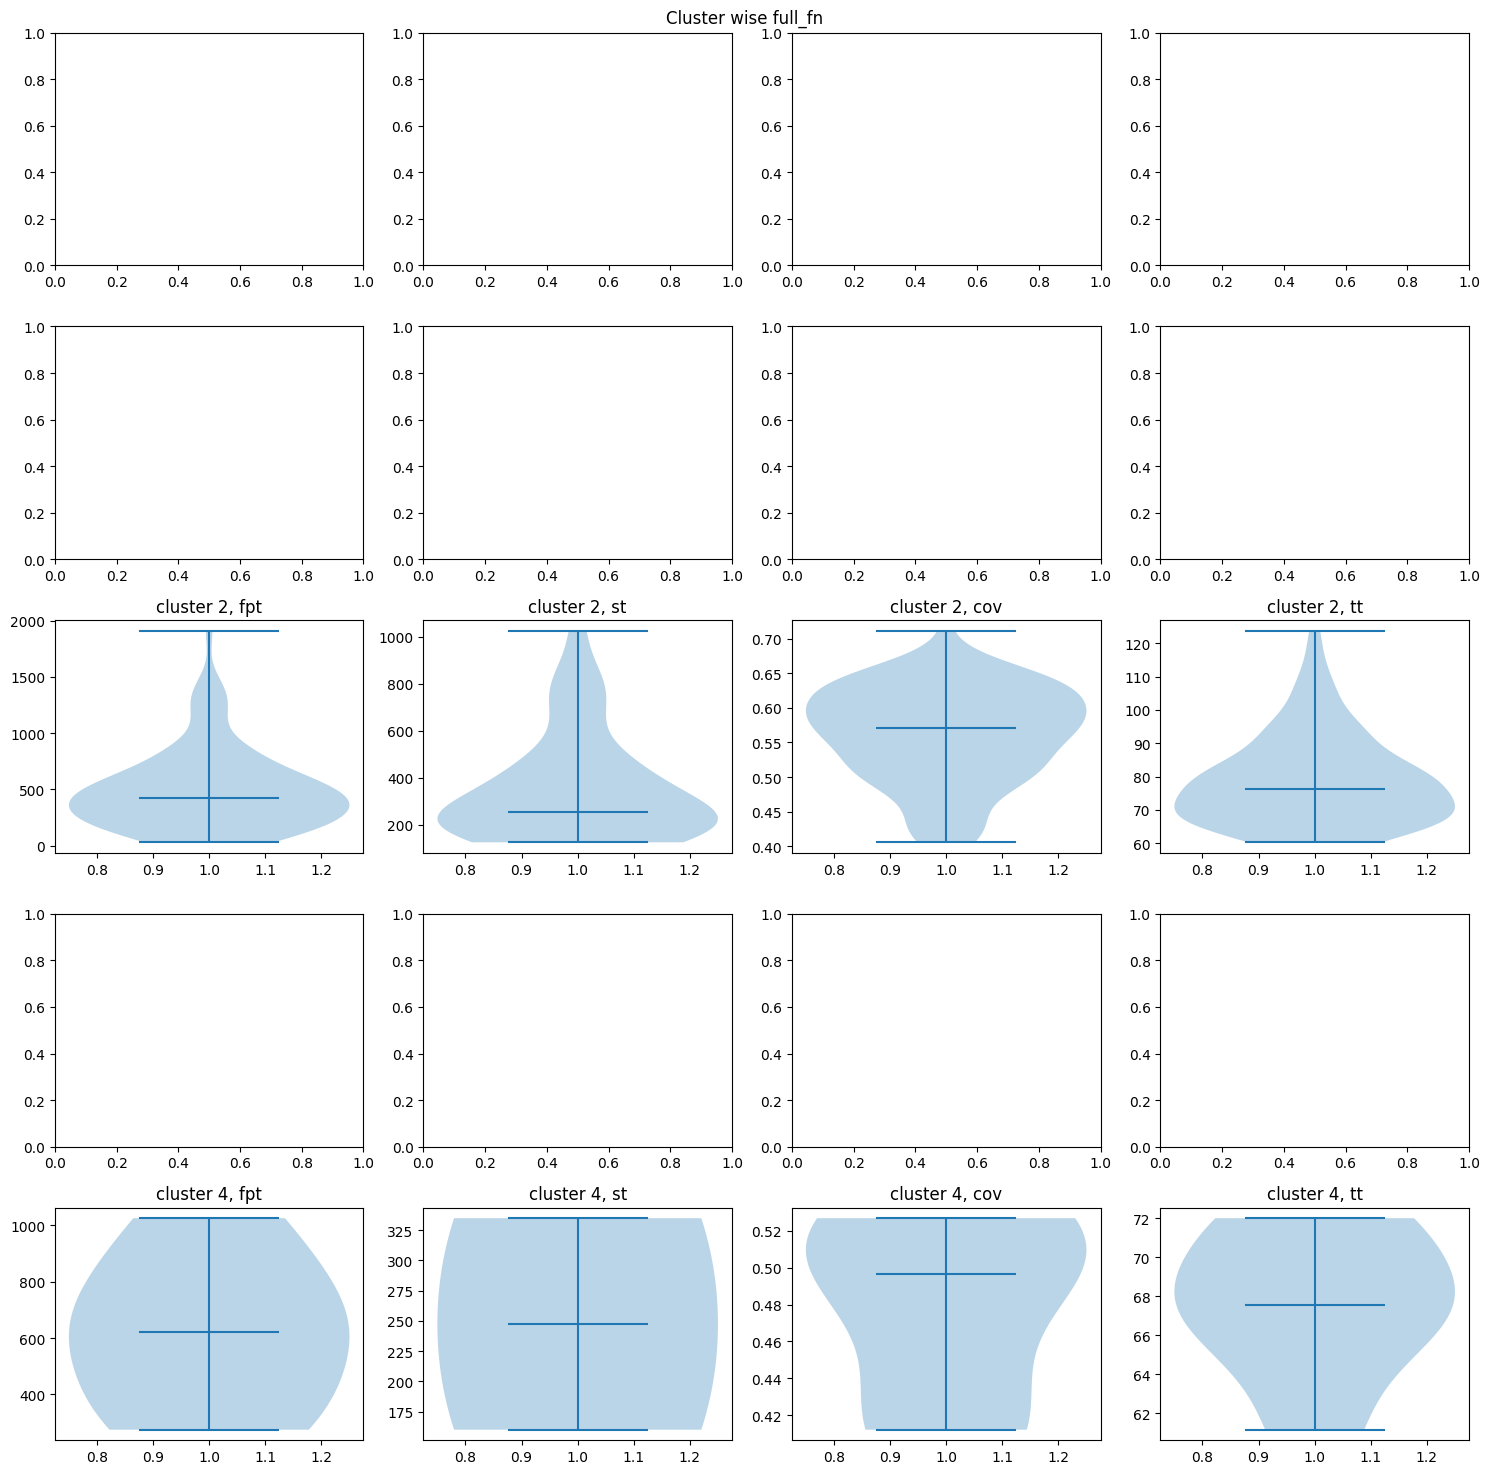

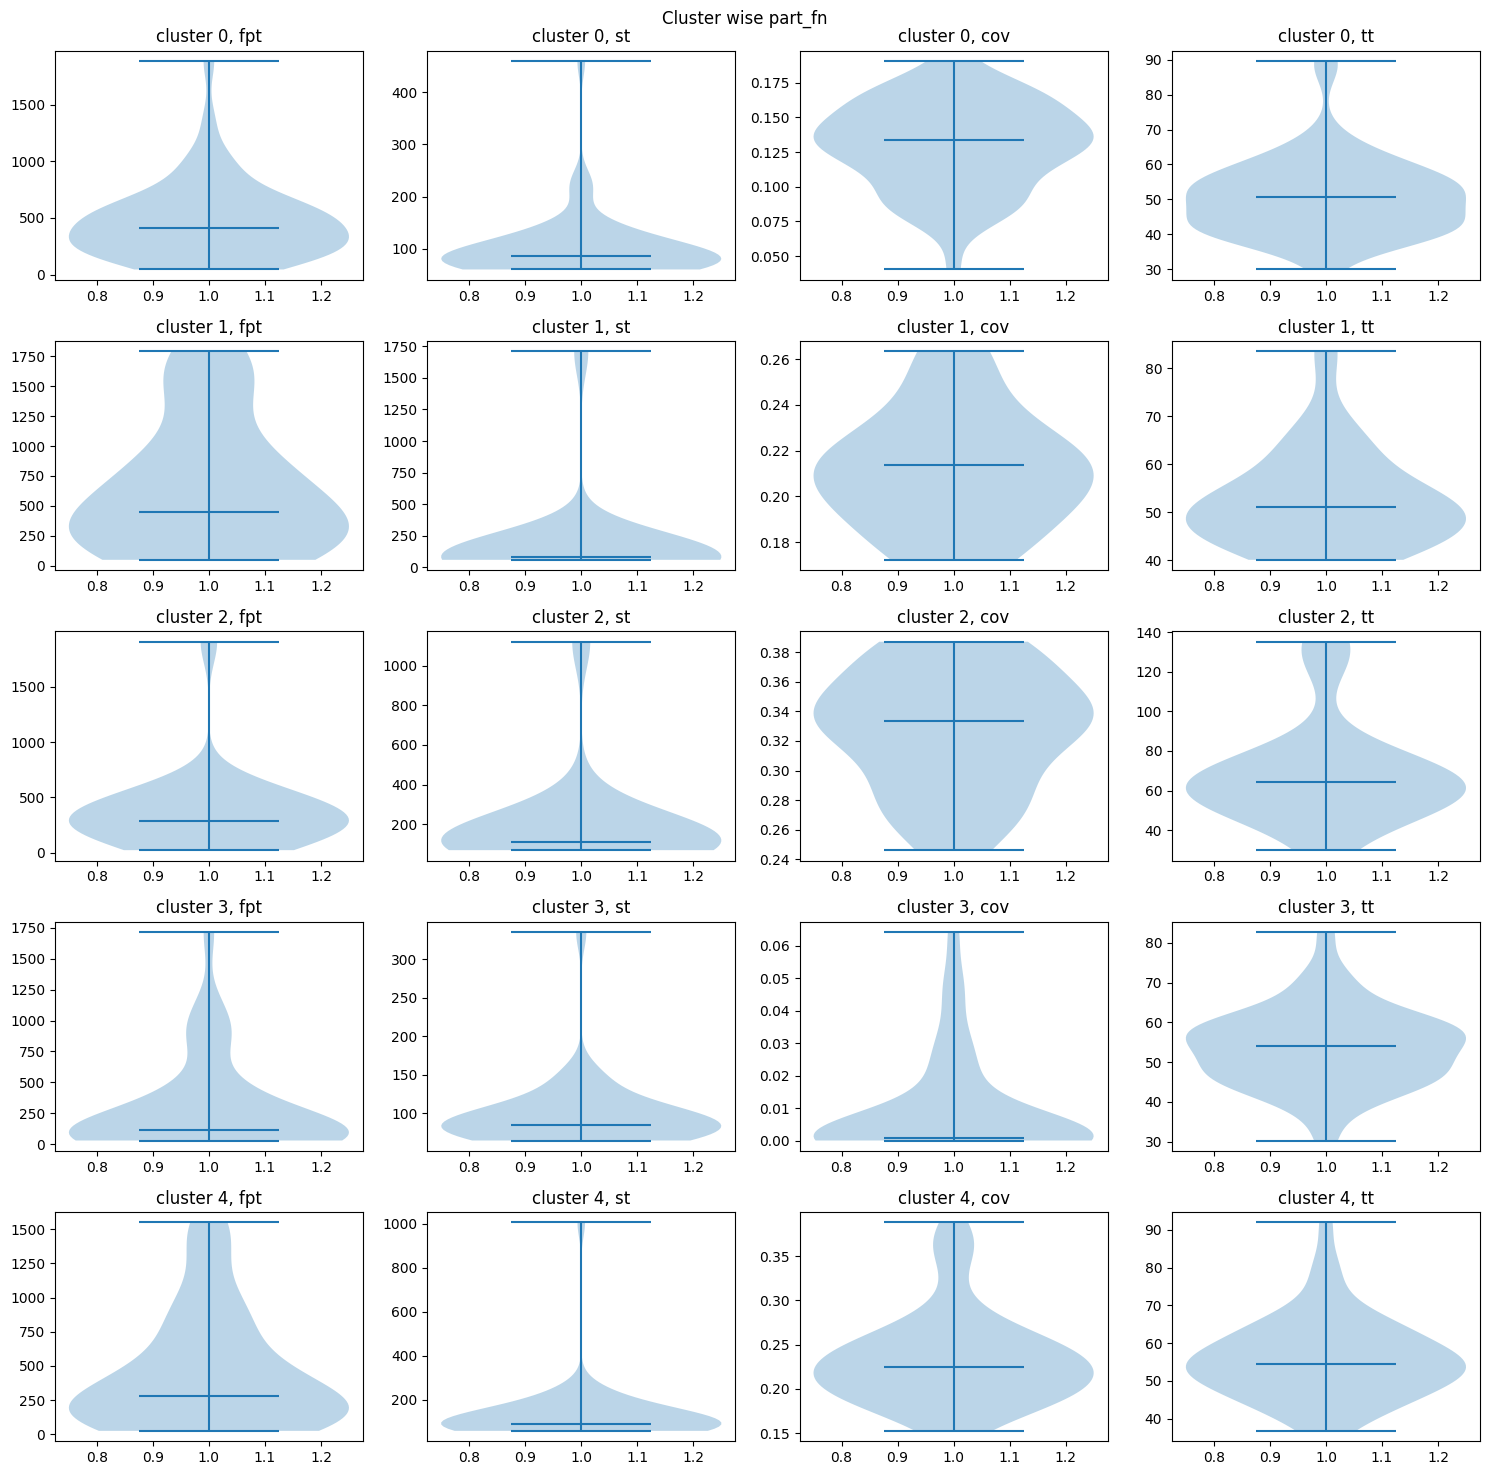

full_fn
full_lha


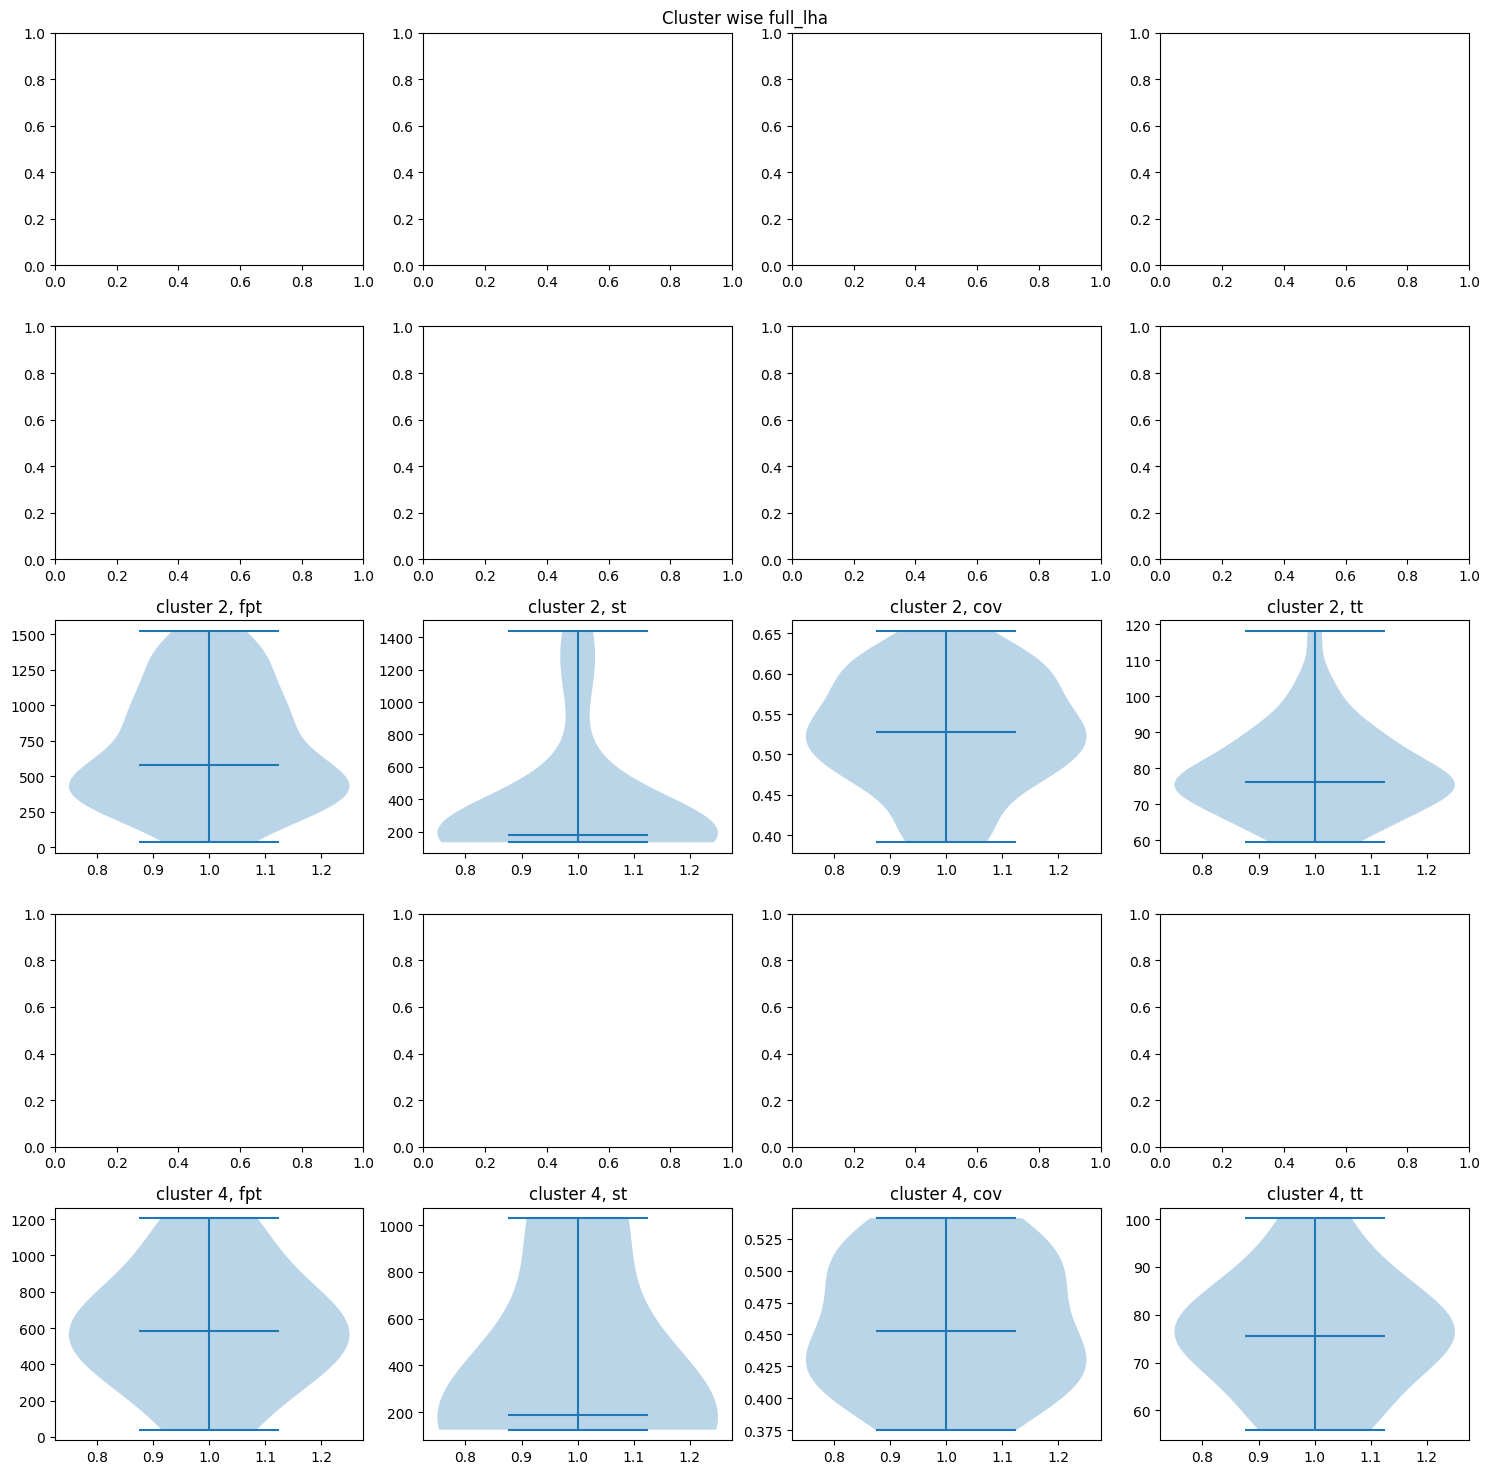

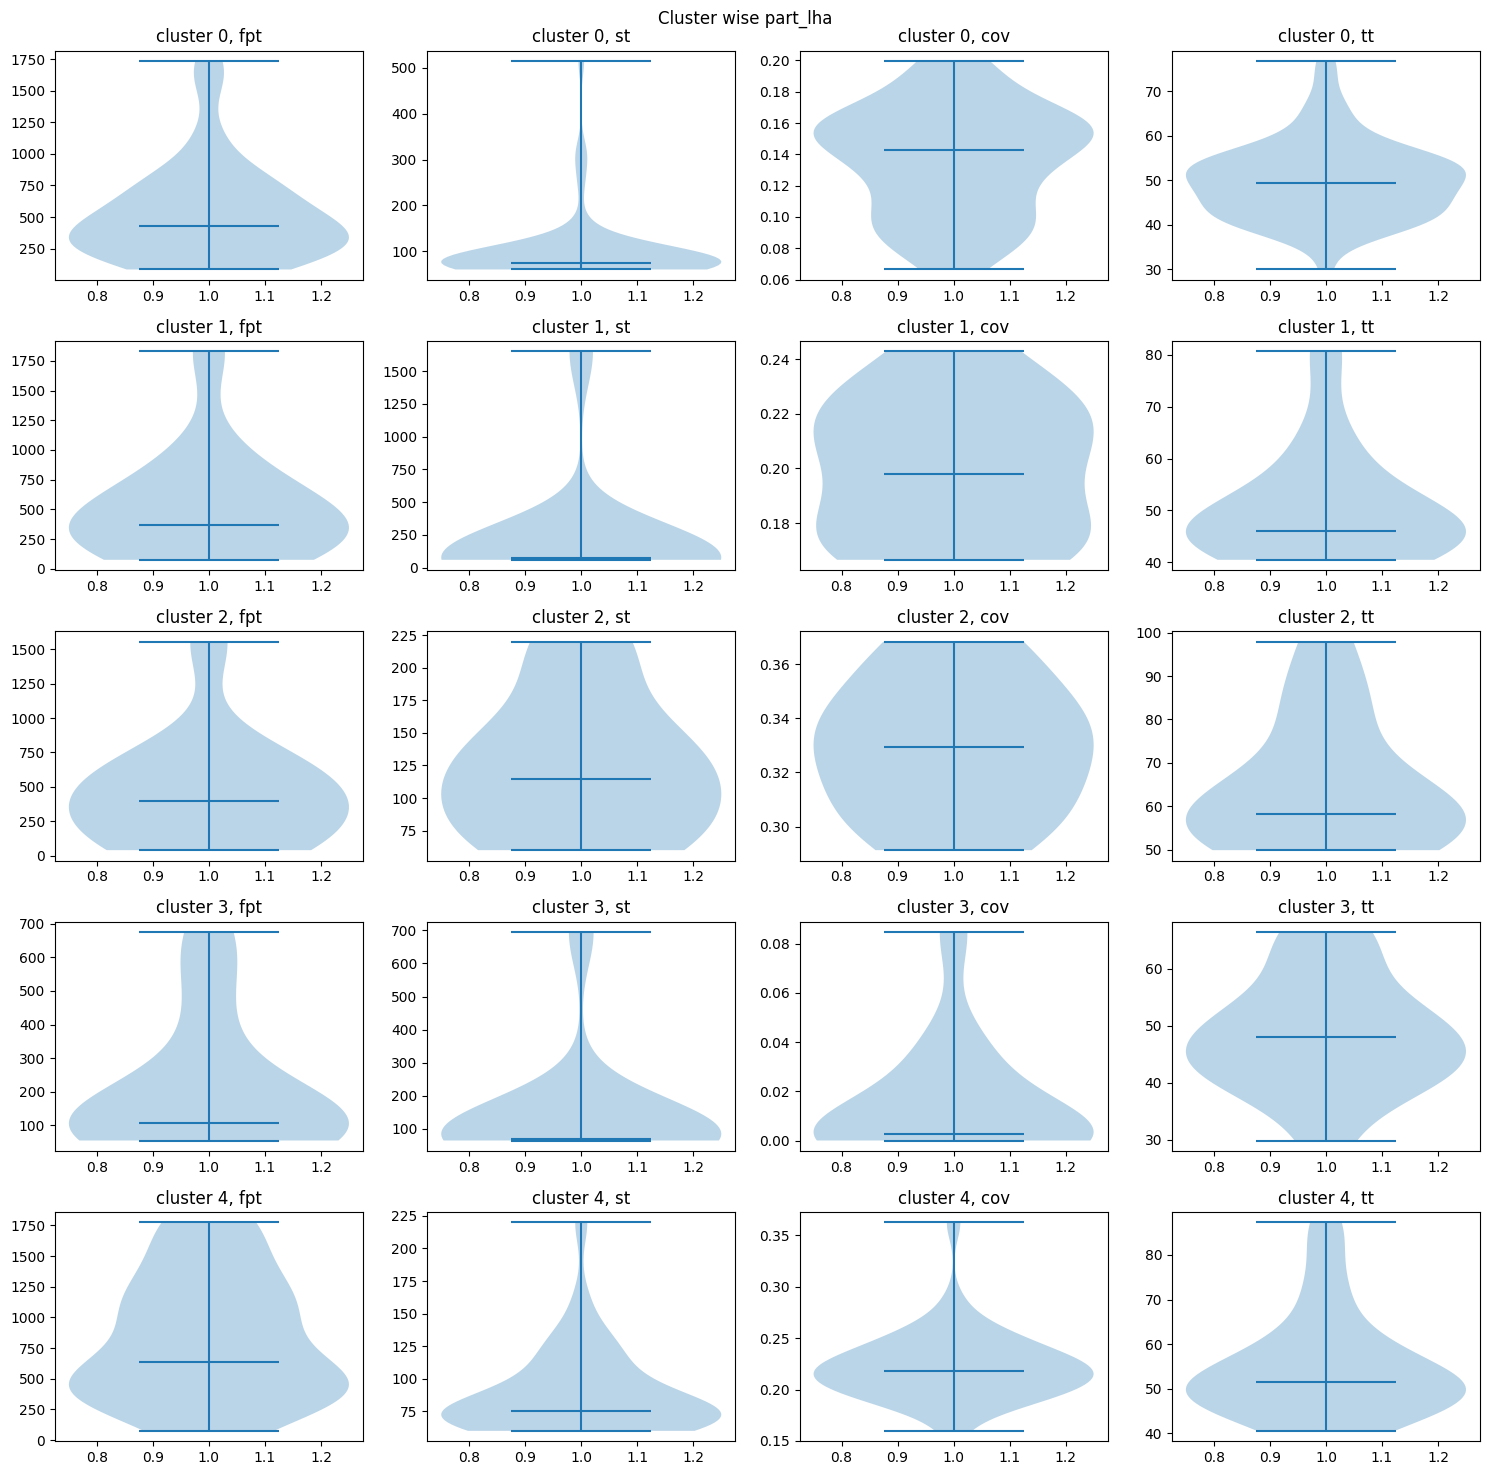

full_lha
full_lsc


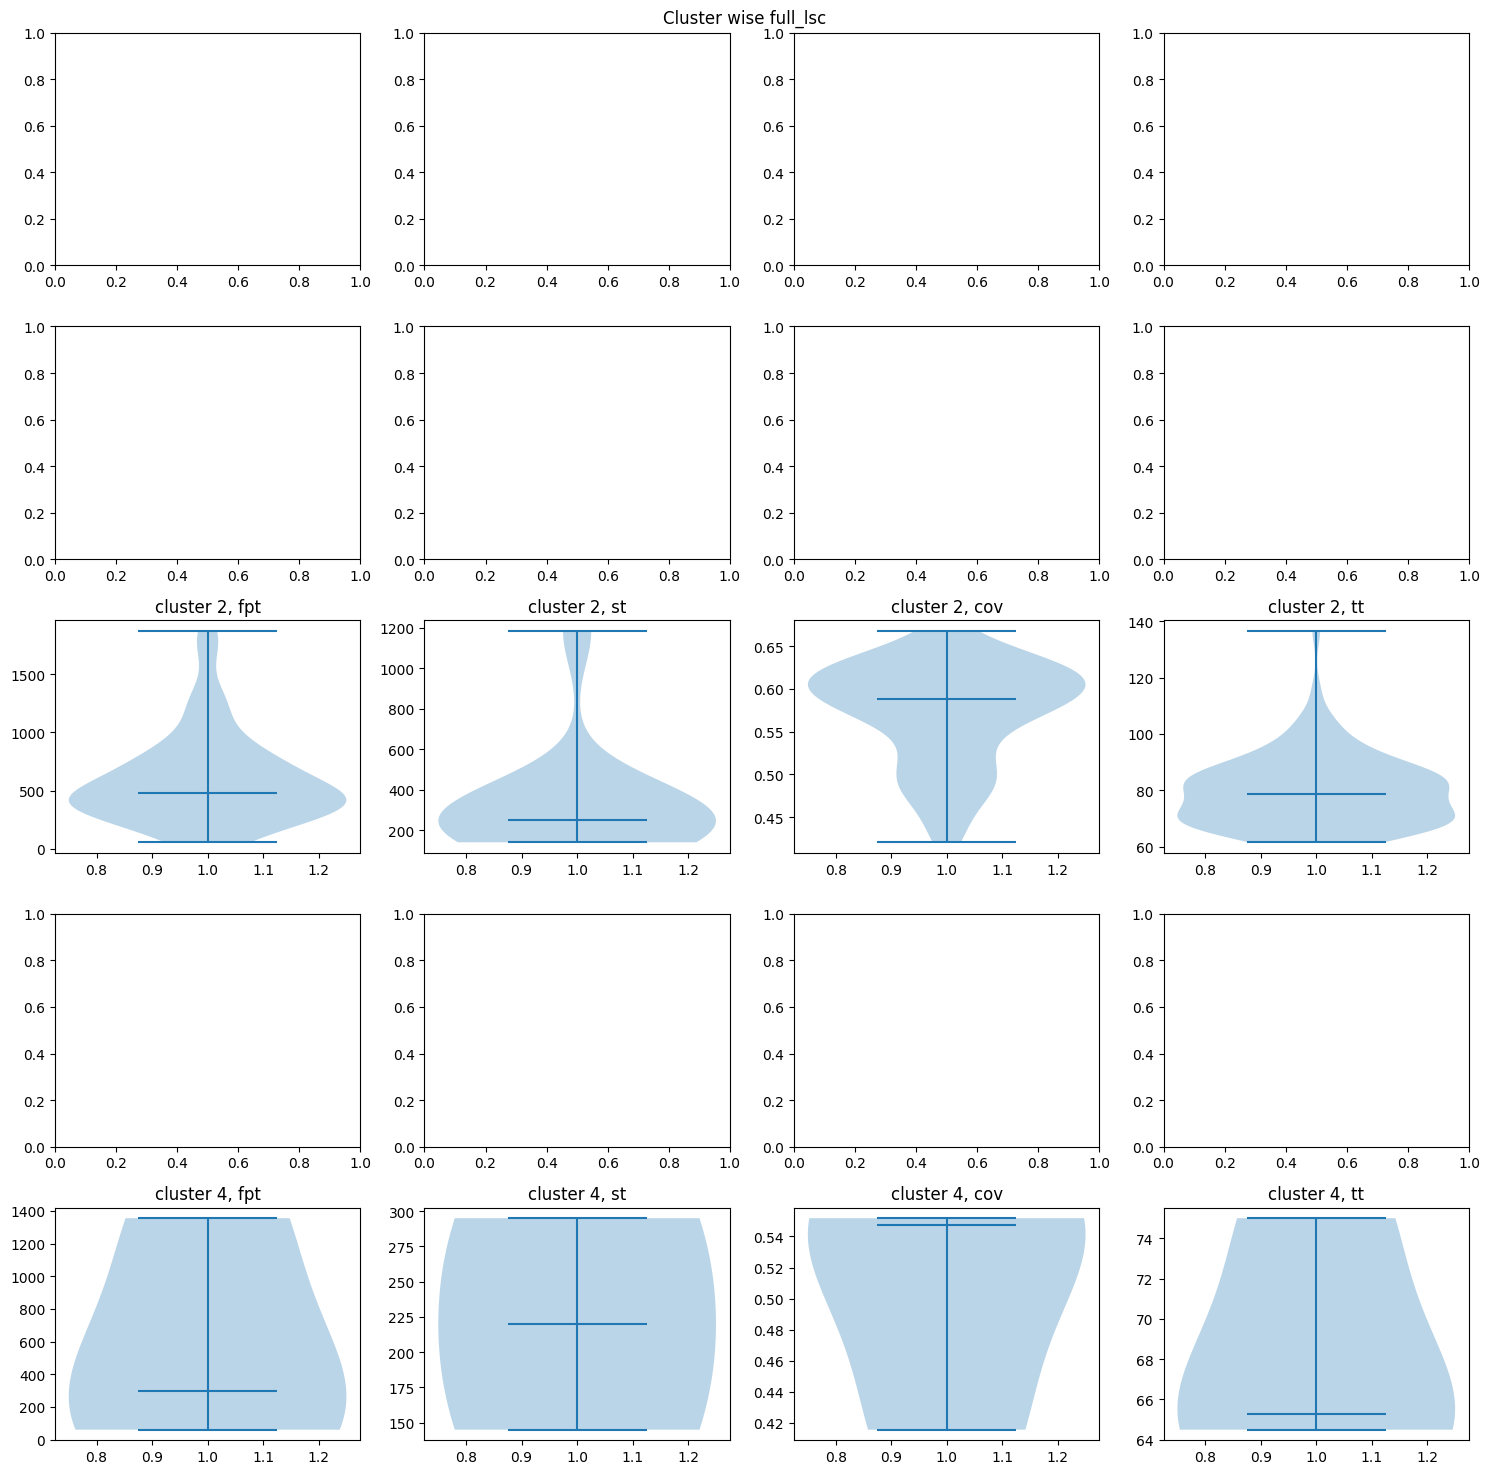

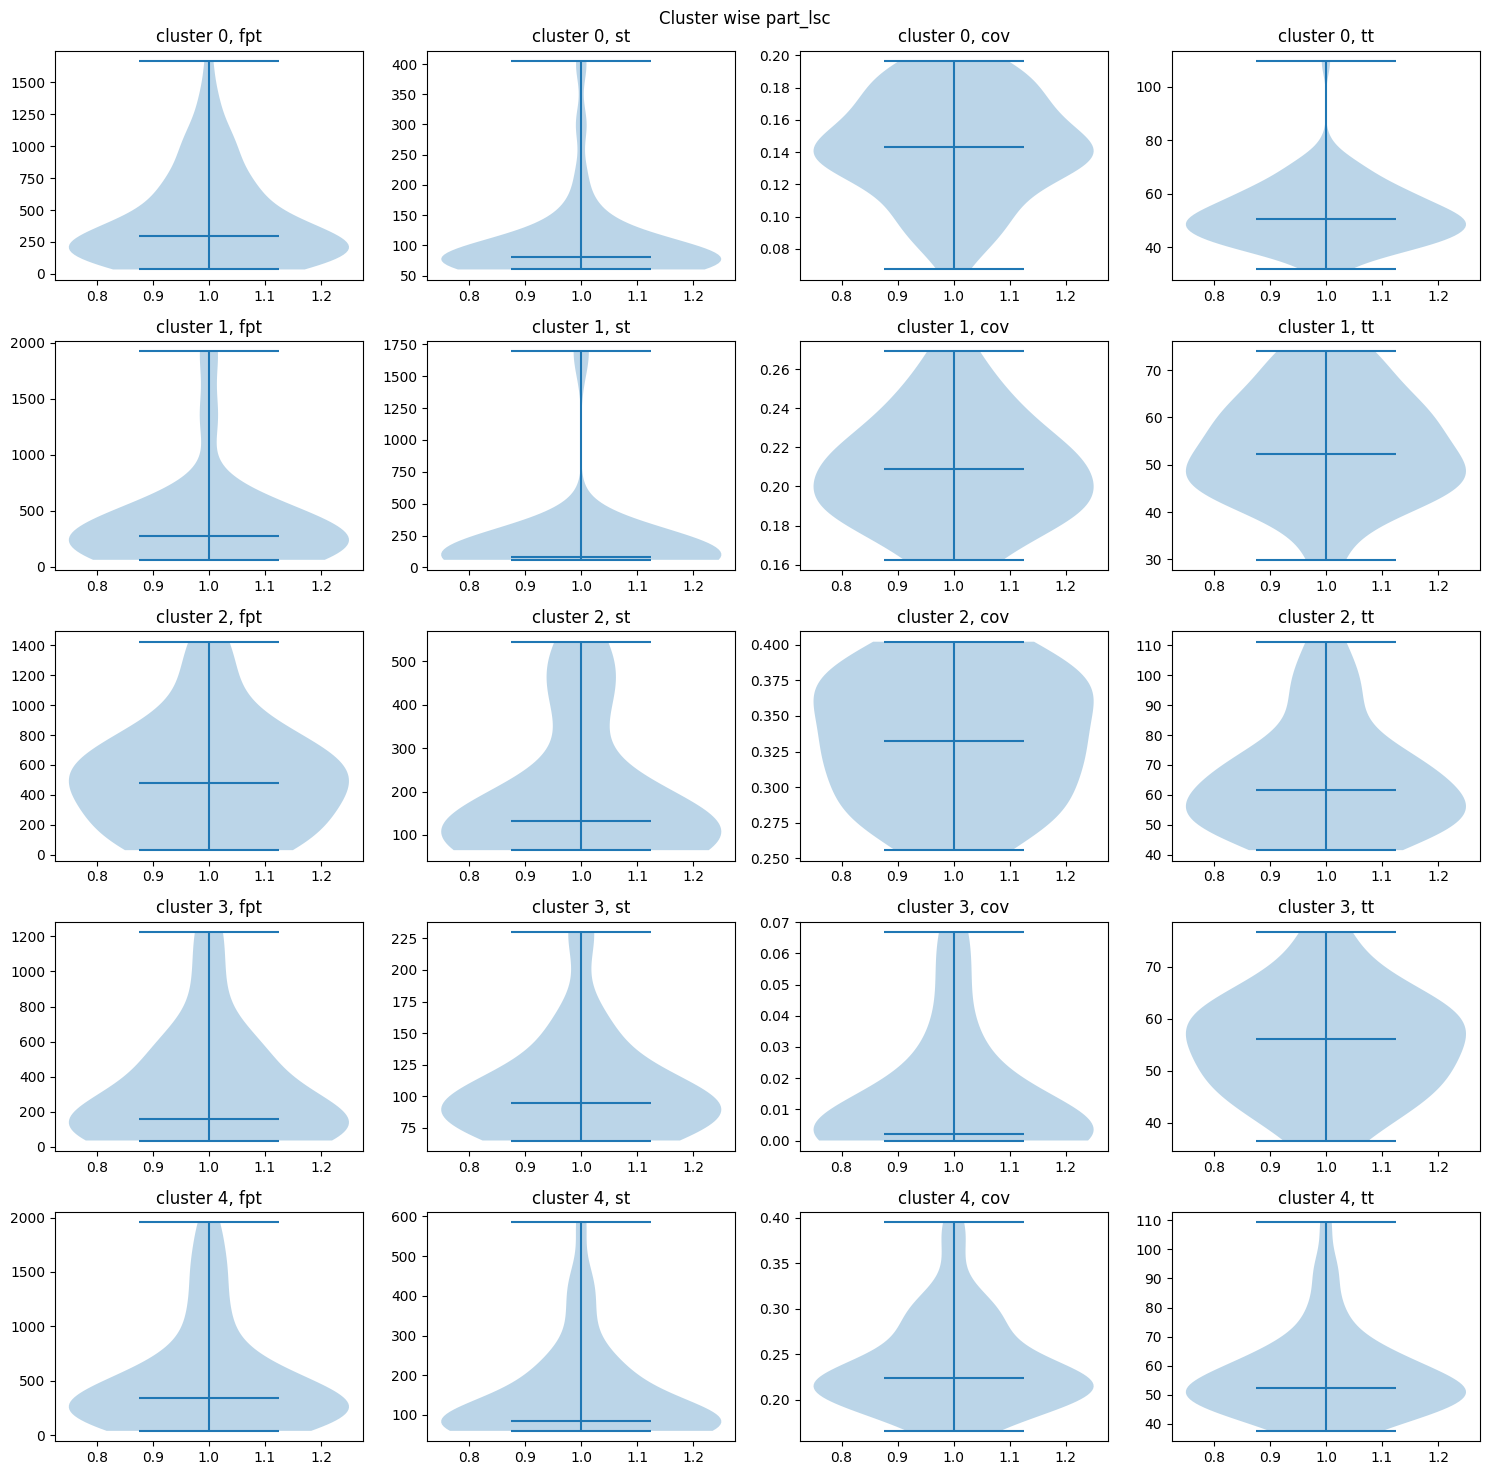

full_lsc
full_mob


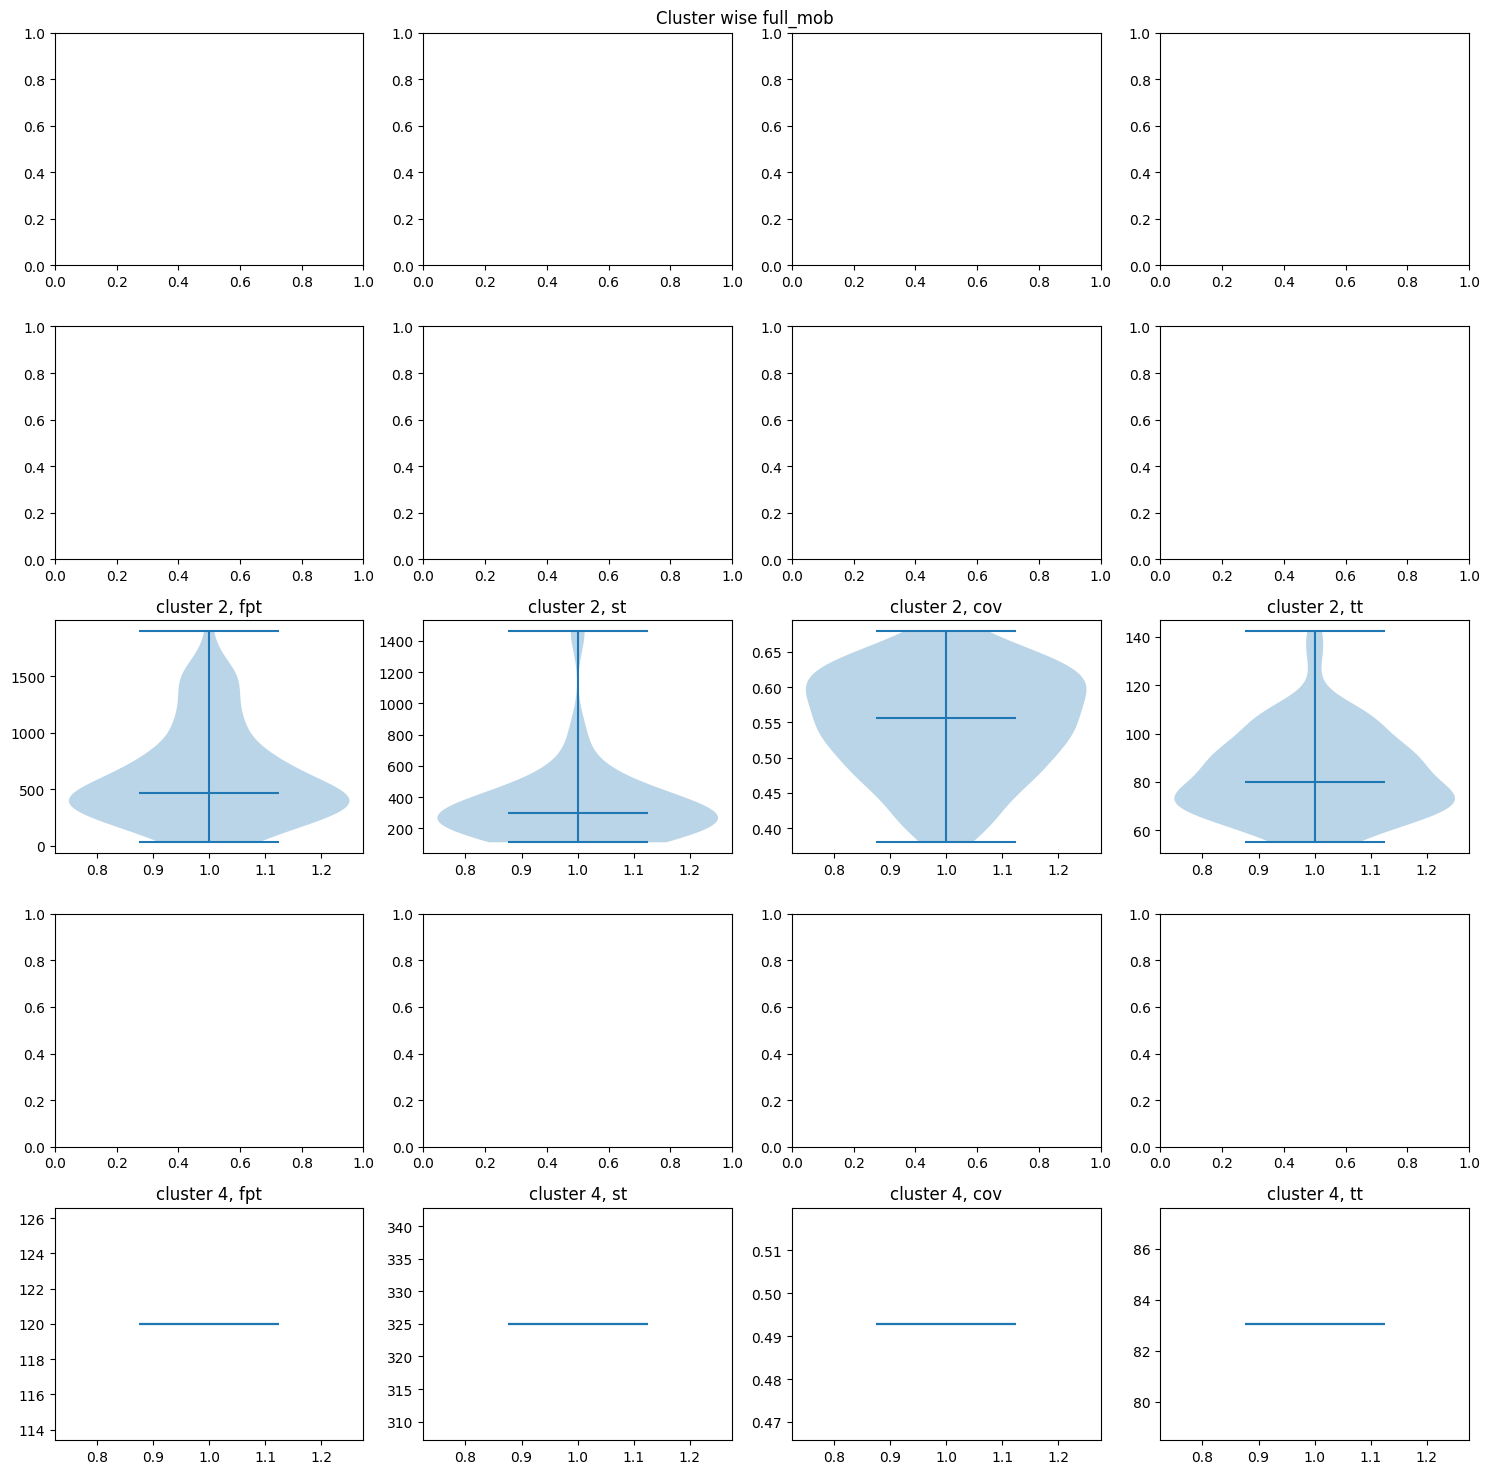

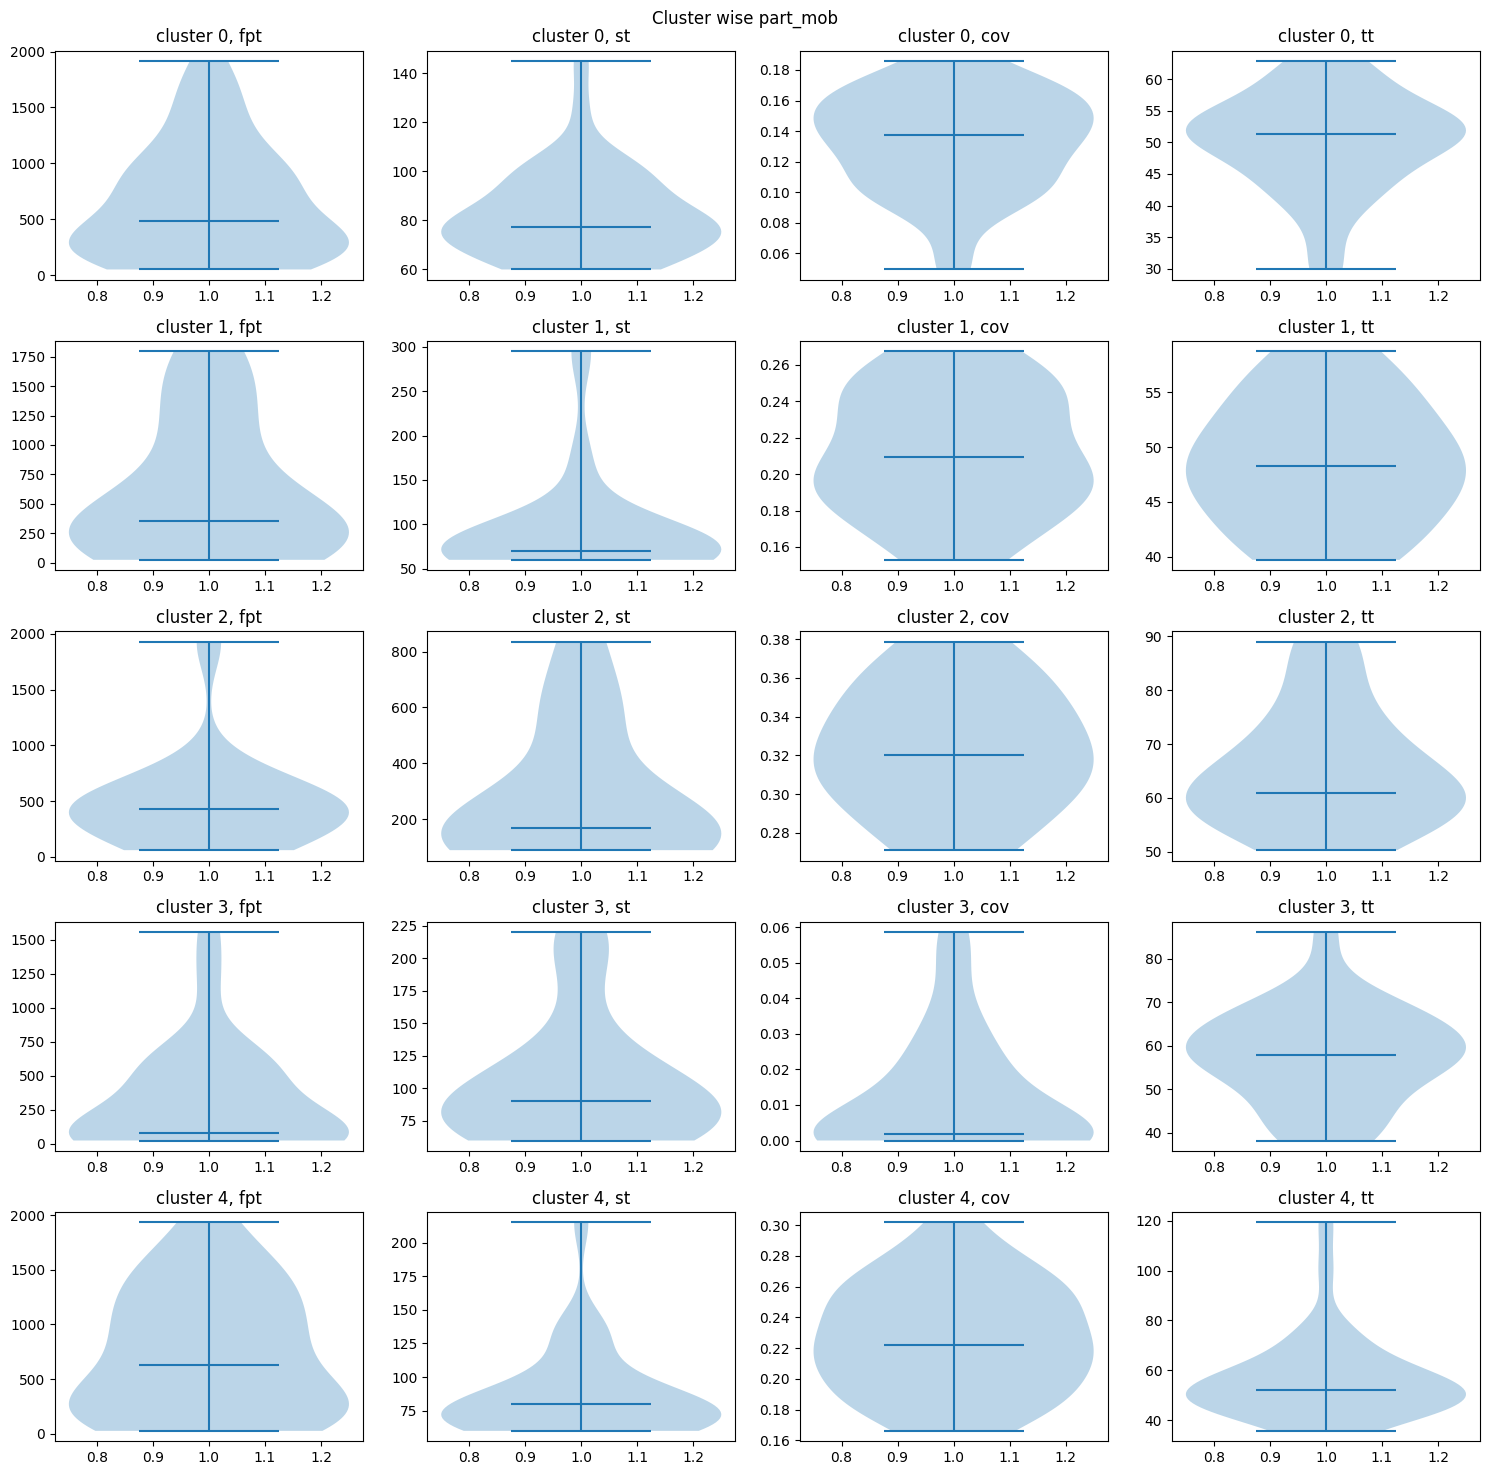

full_mob
full_mop


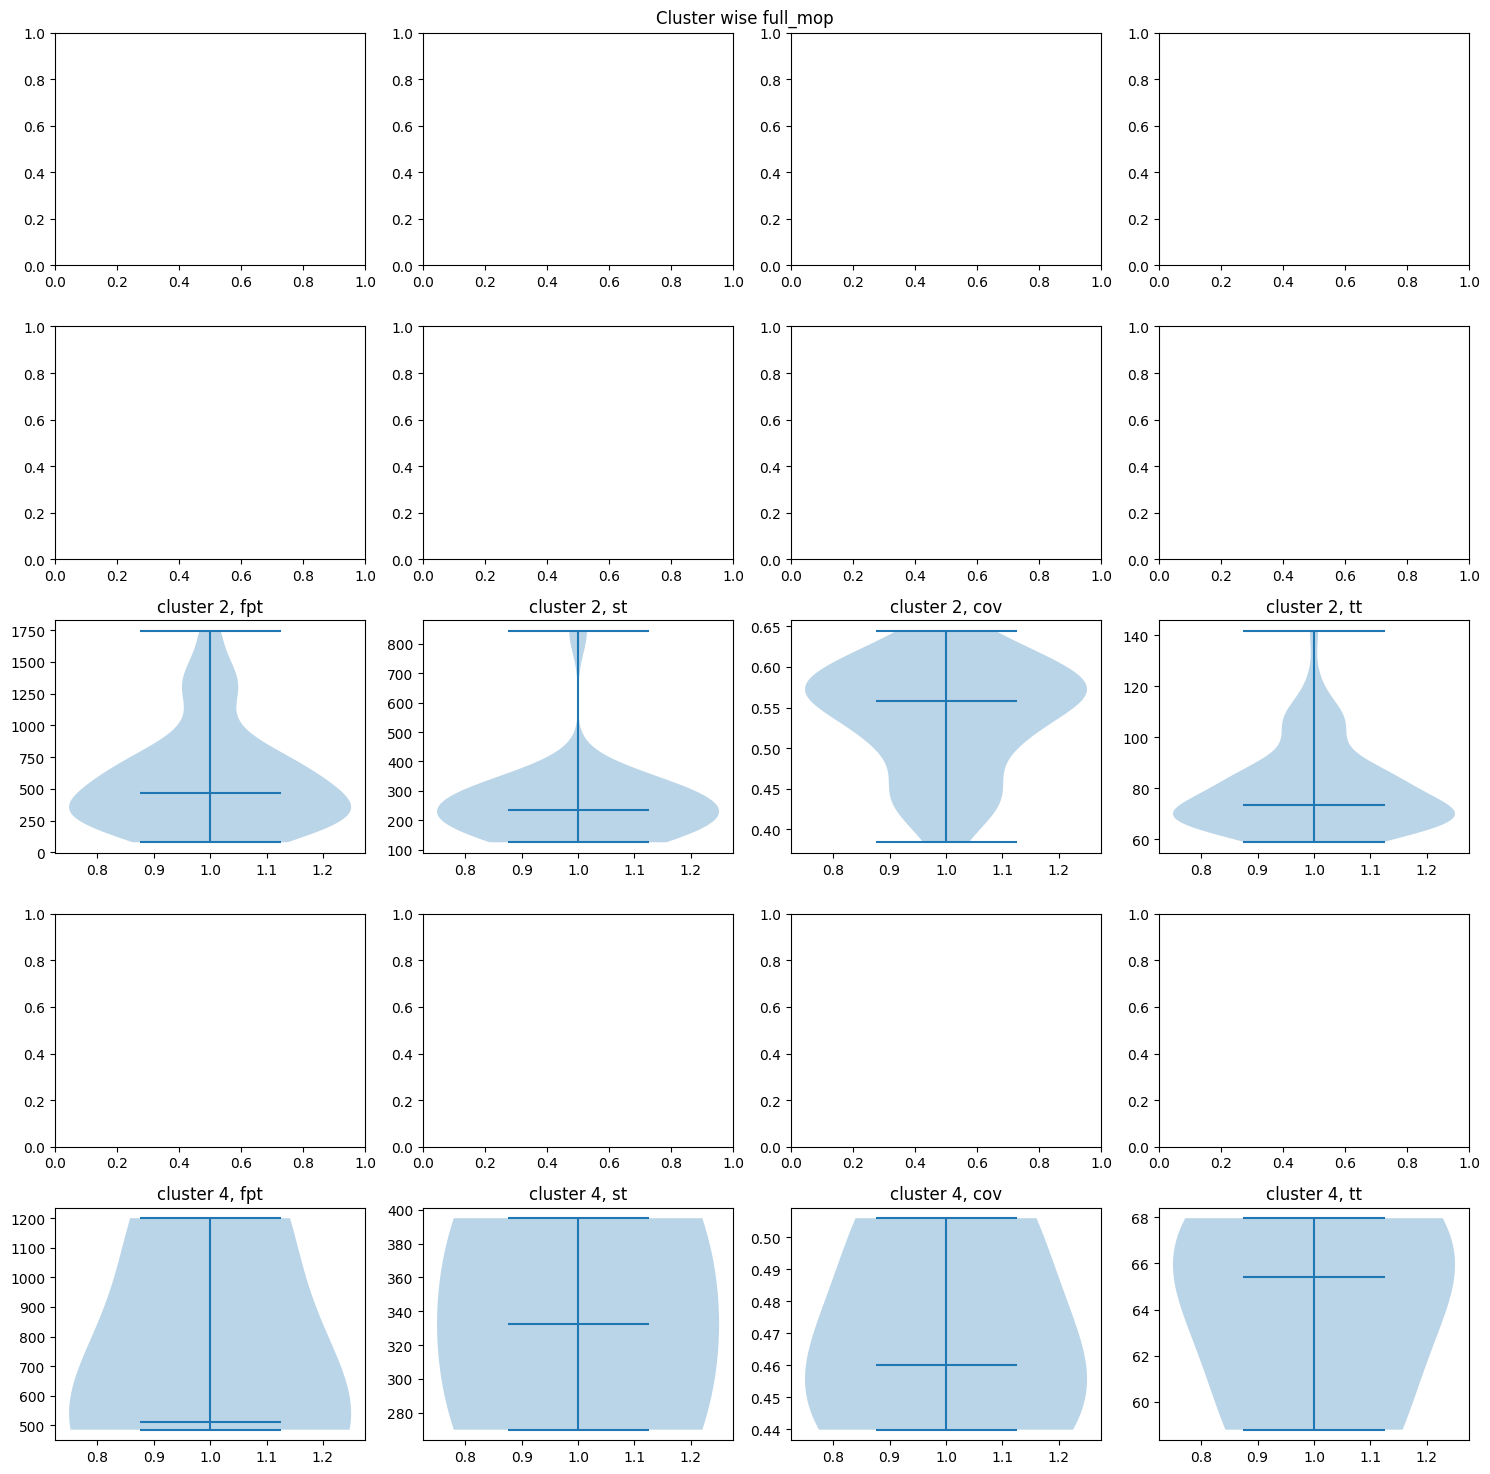

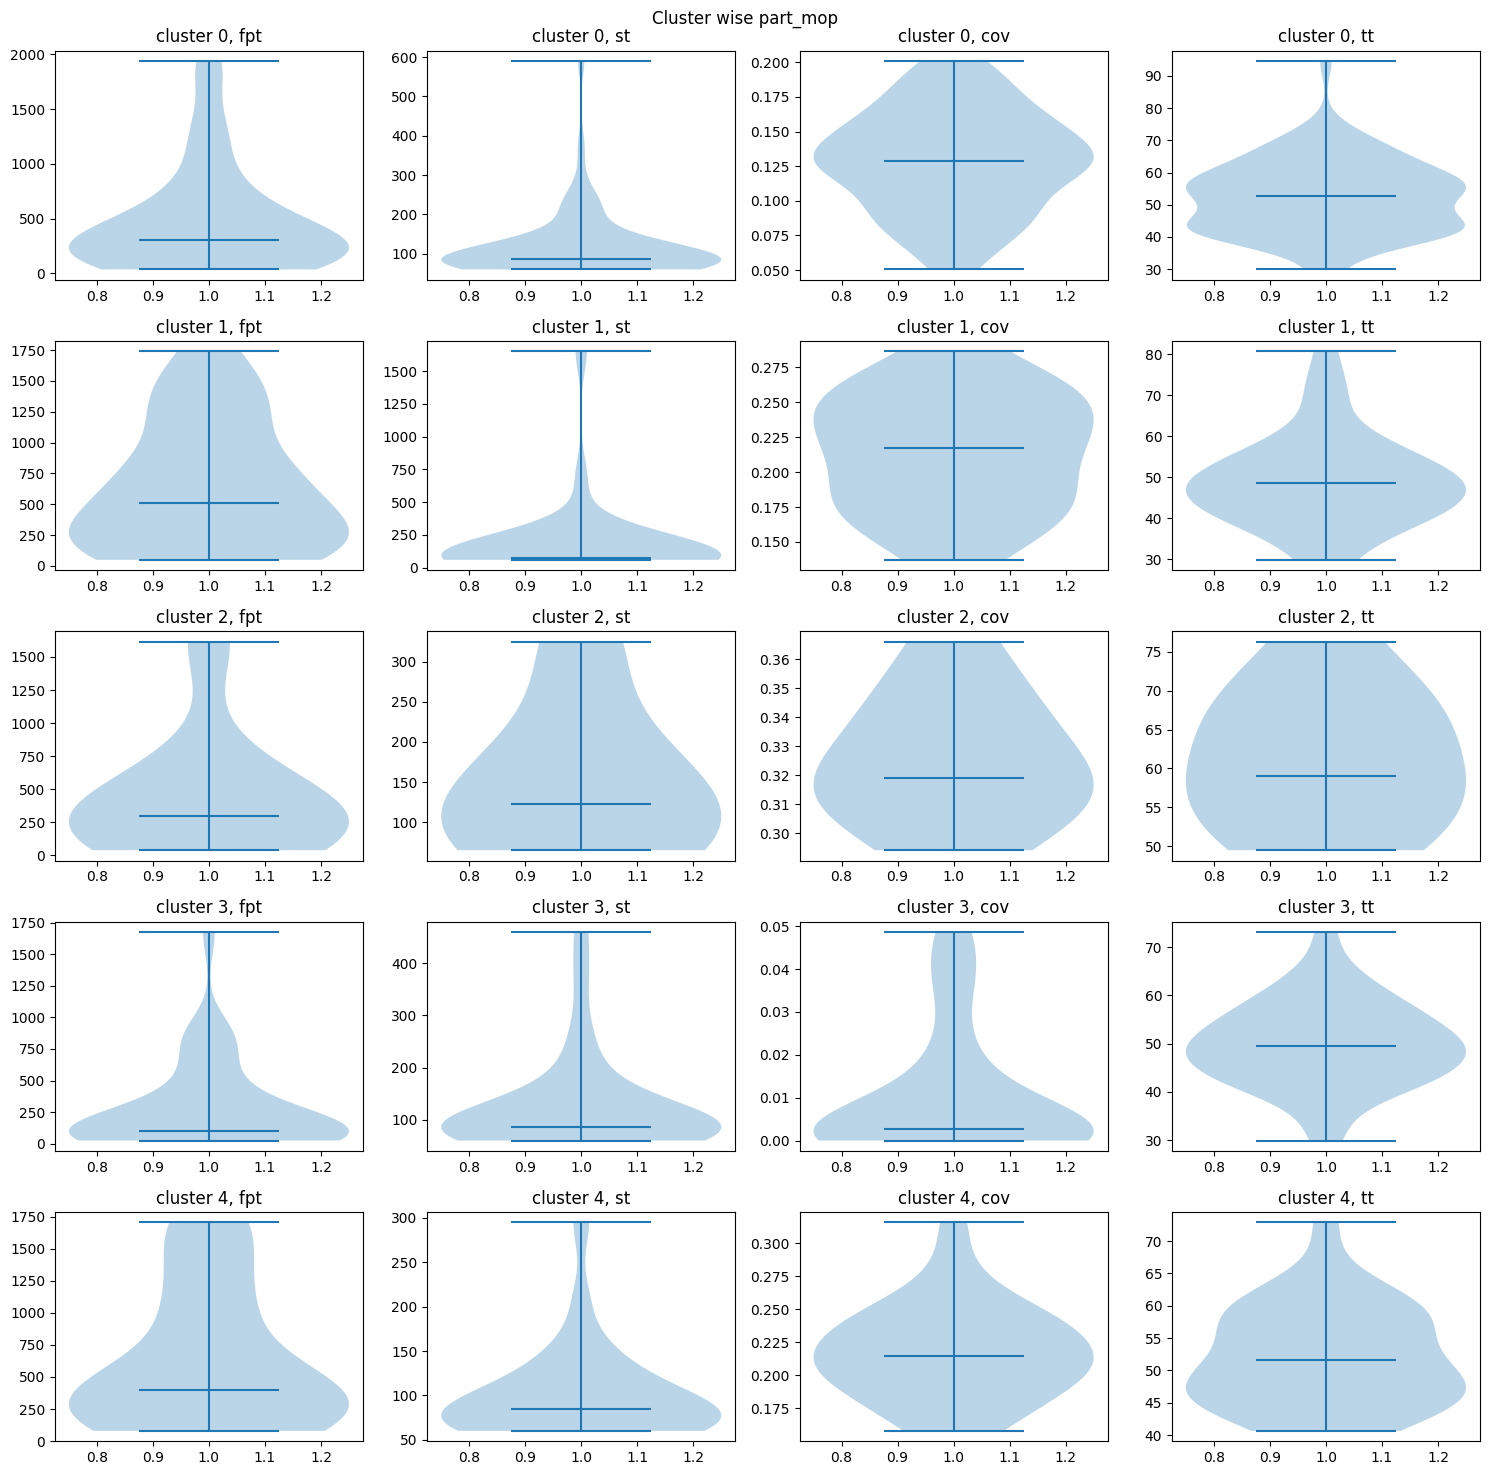

full_mop
full_mos


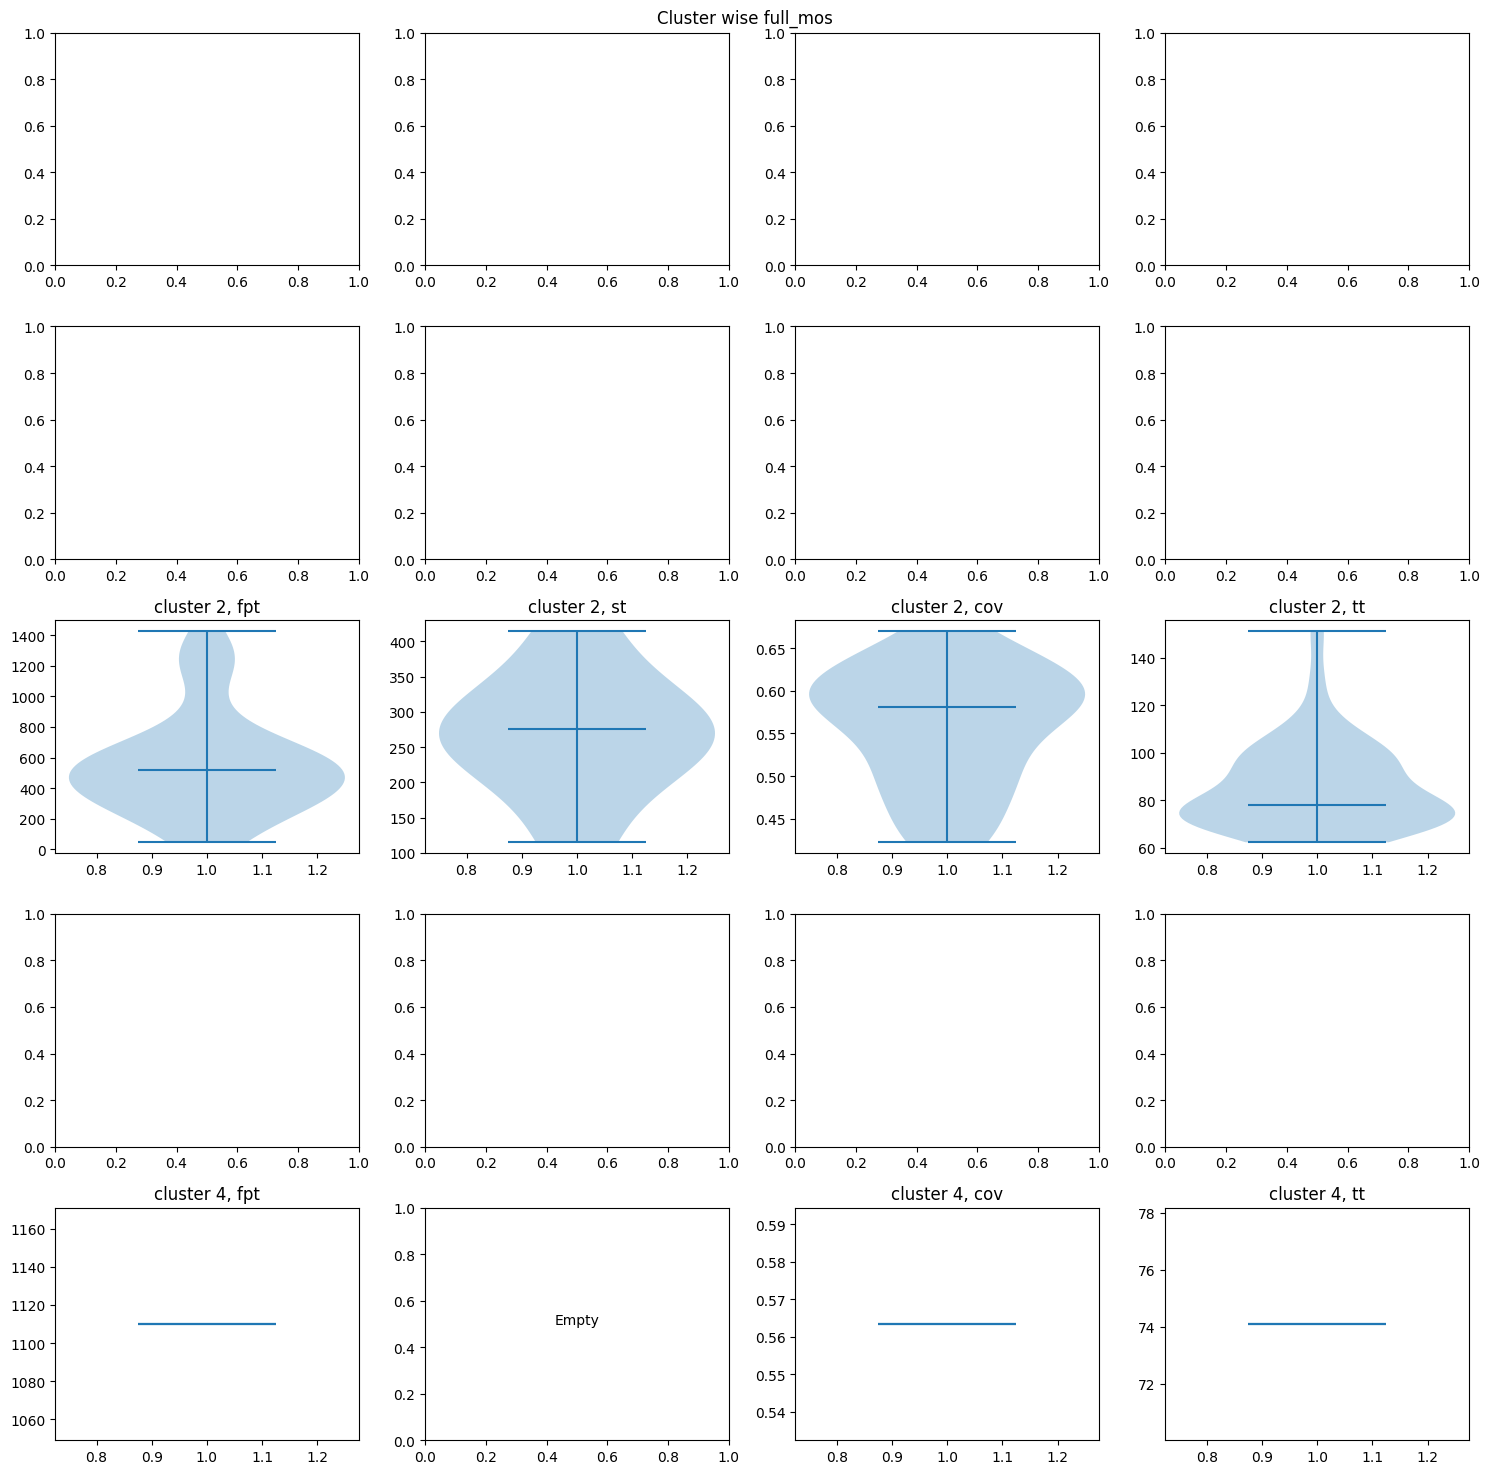

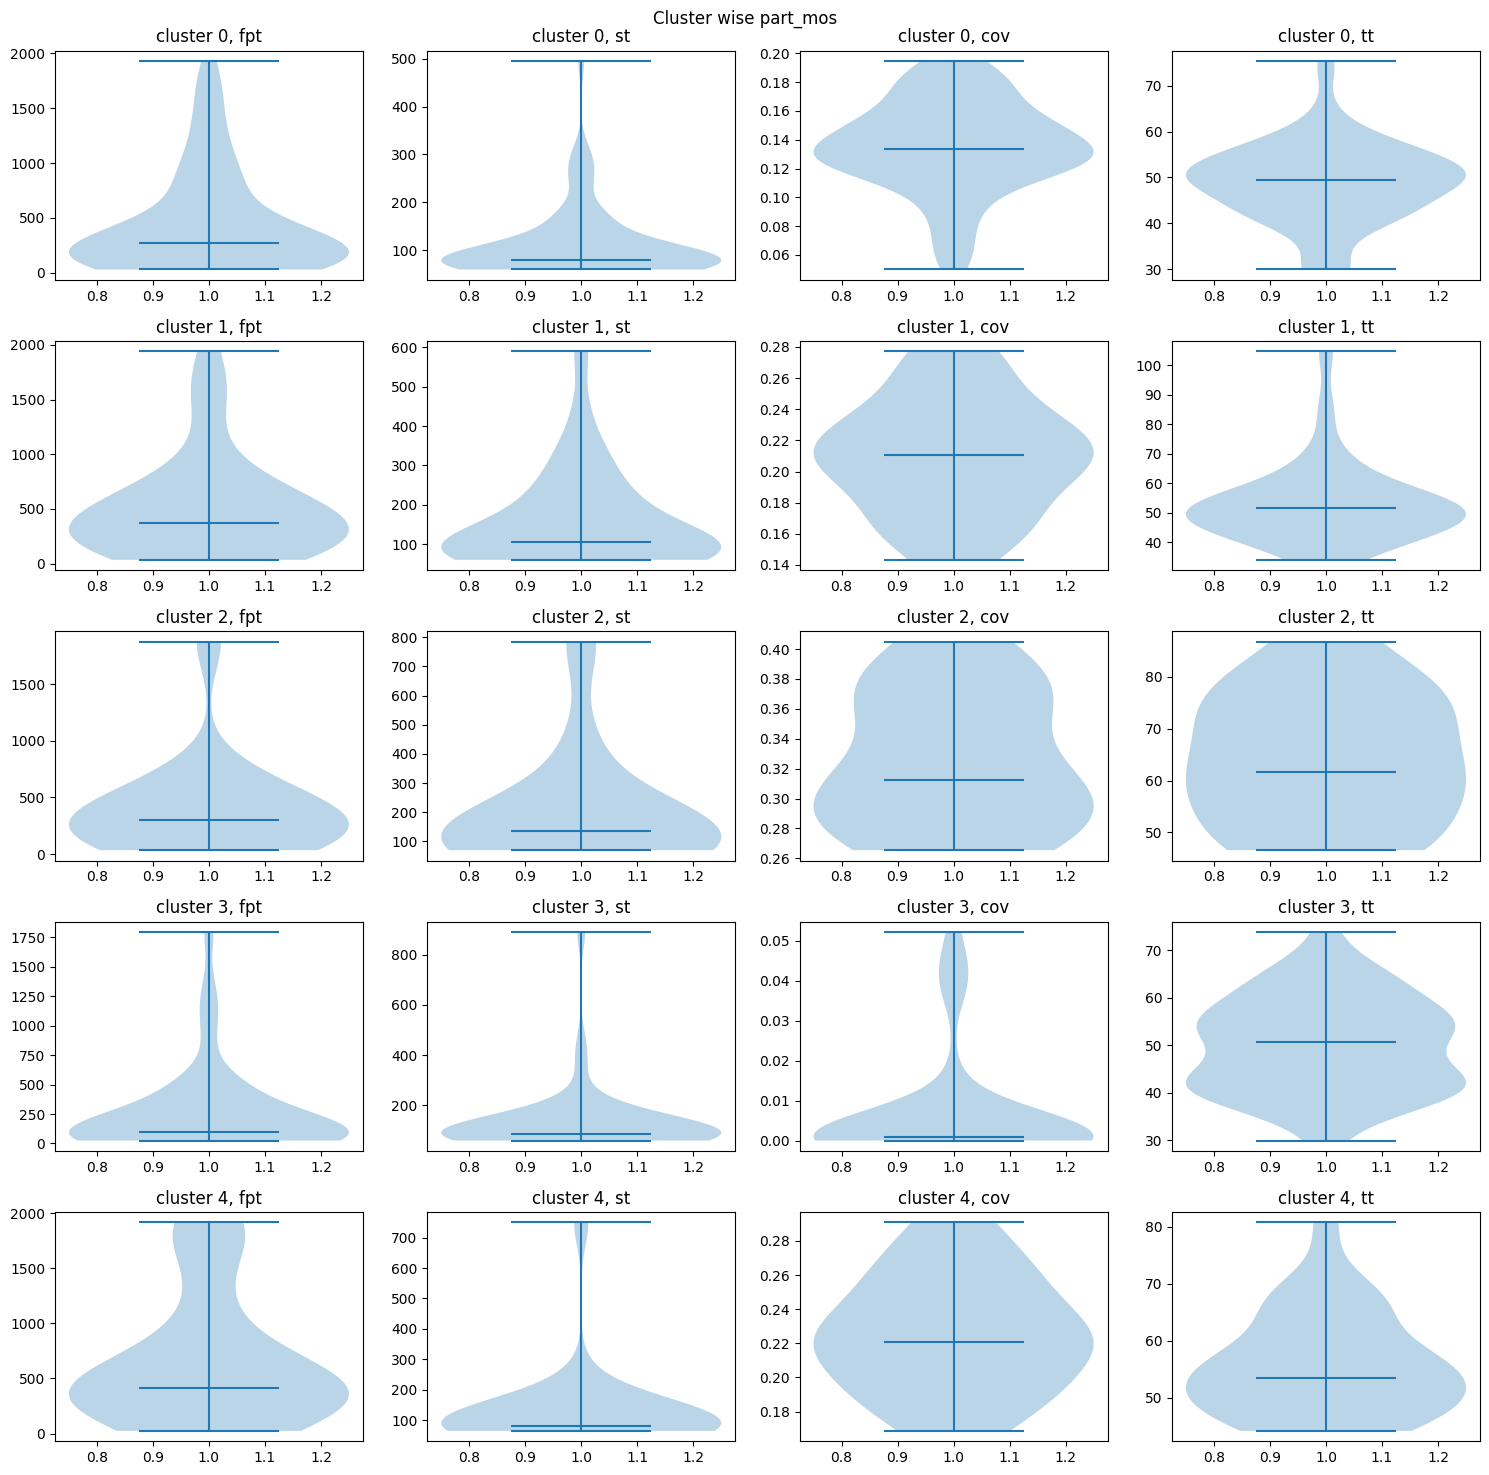

full_mos
full_mrn


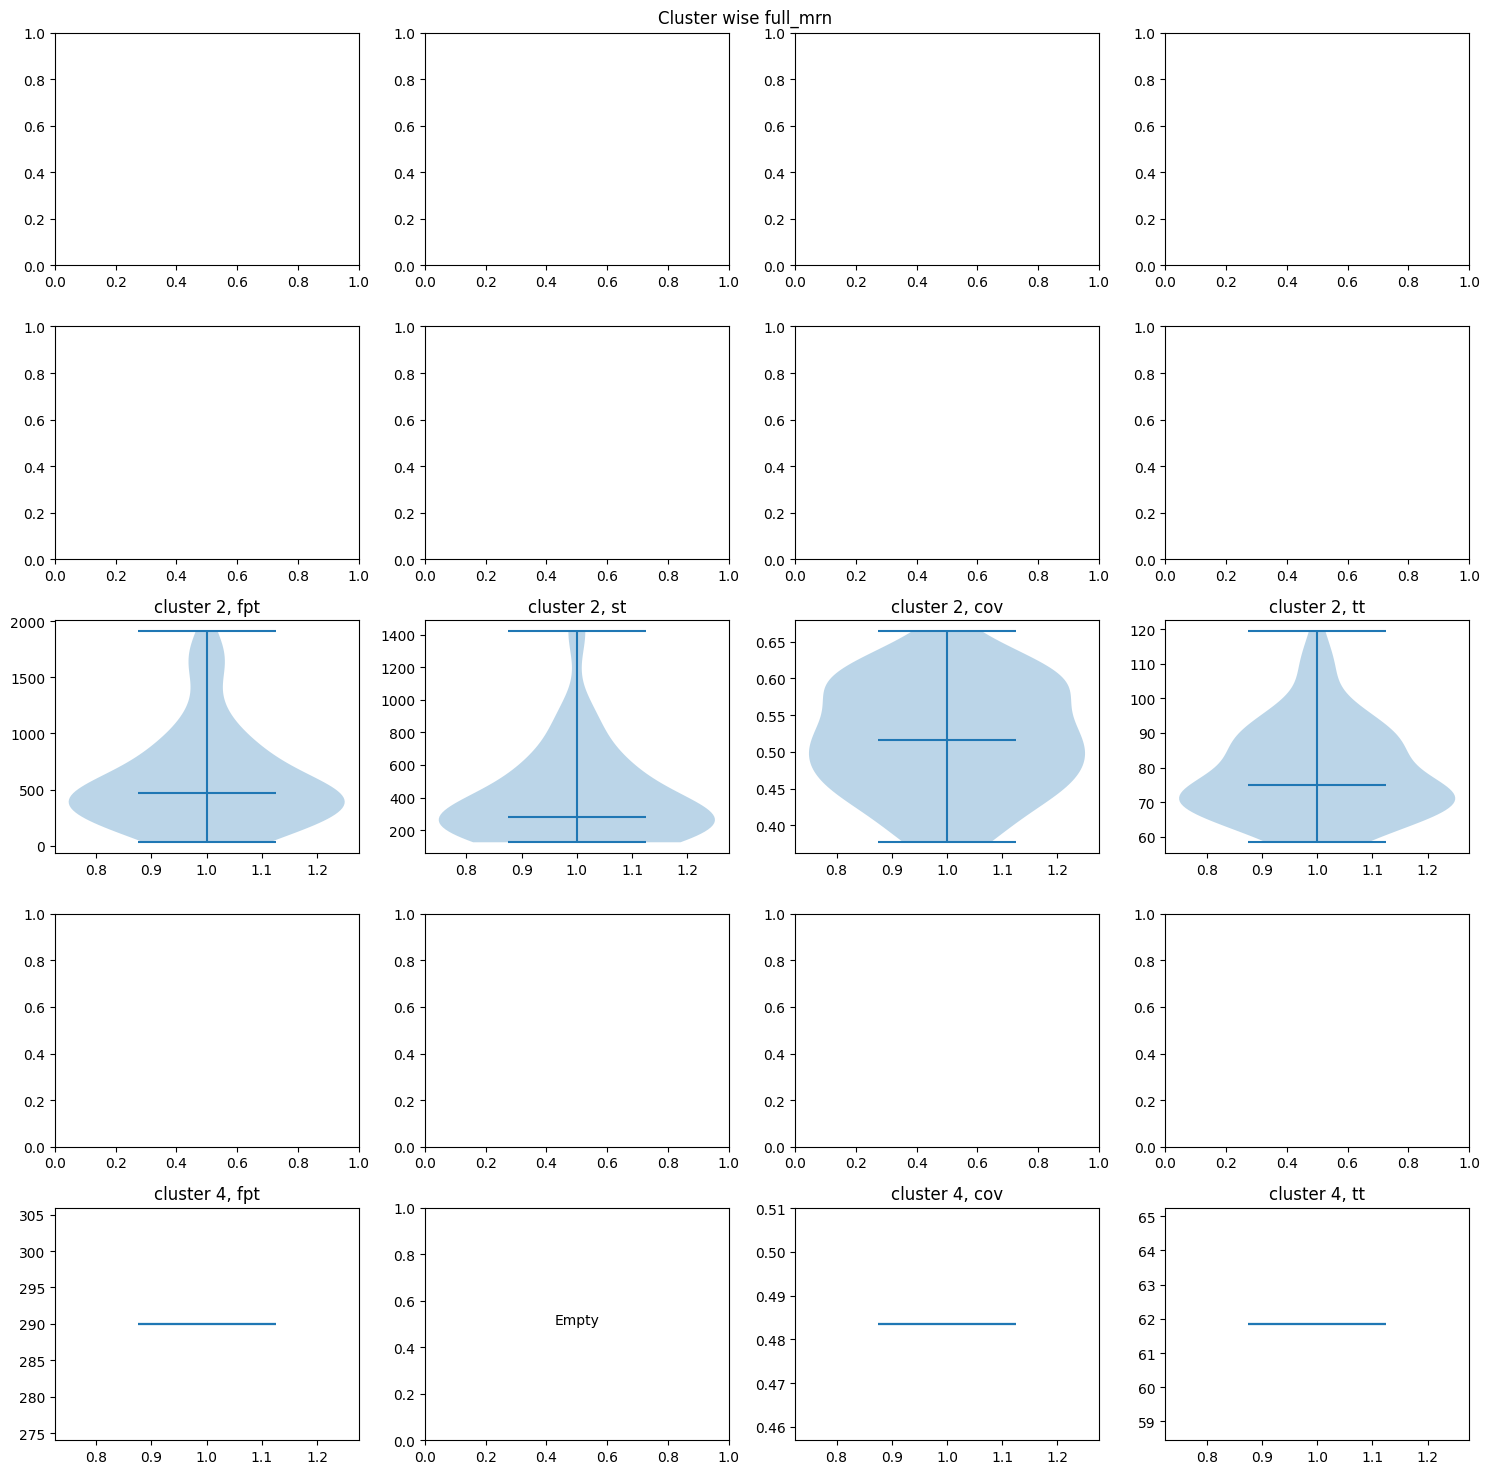

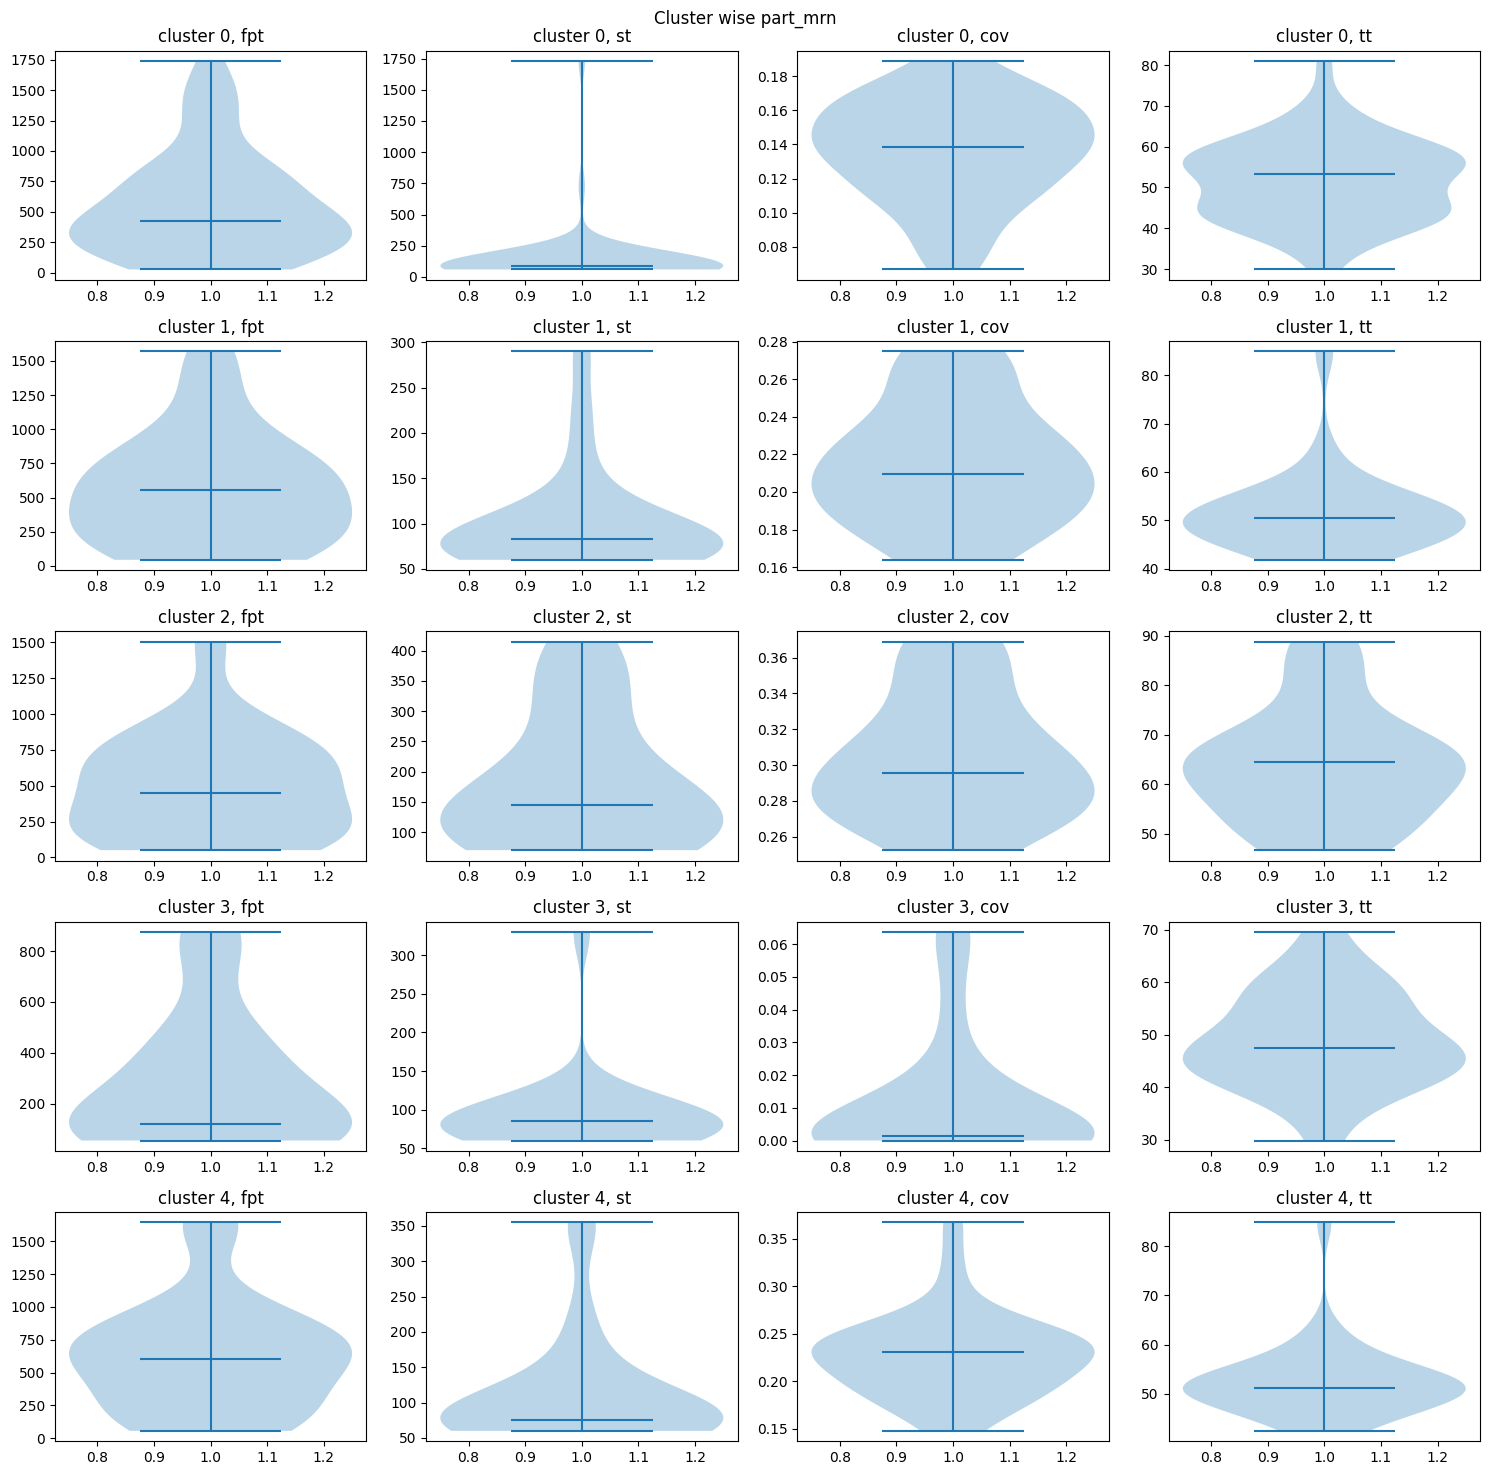

full_mrn
full_orb


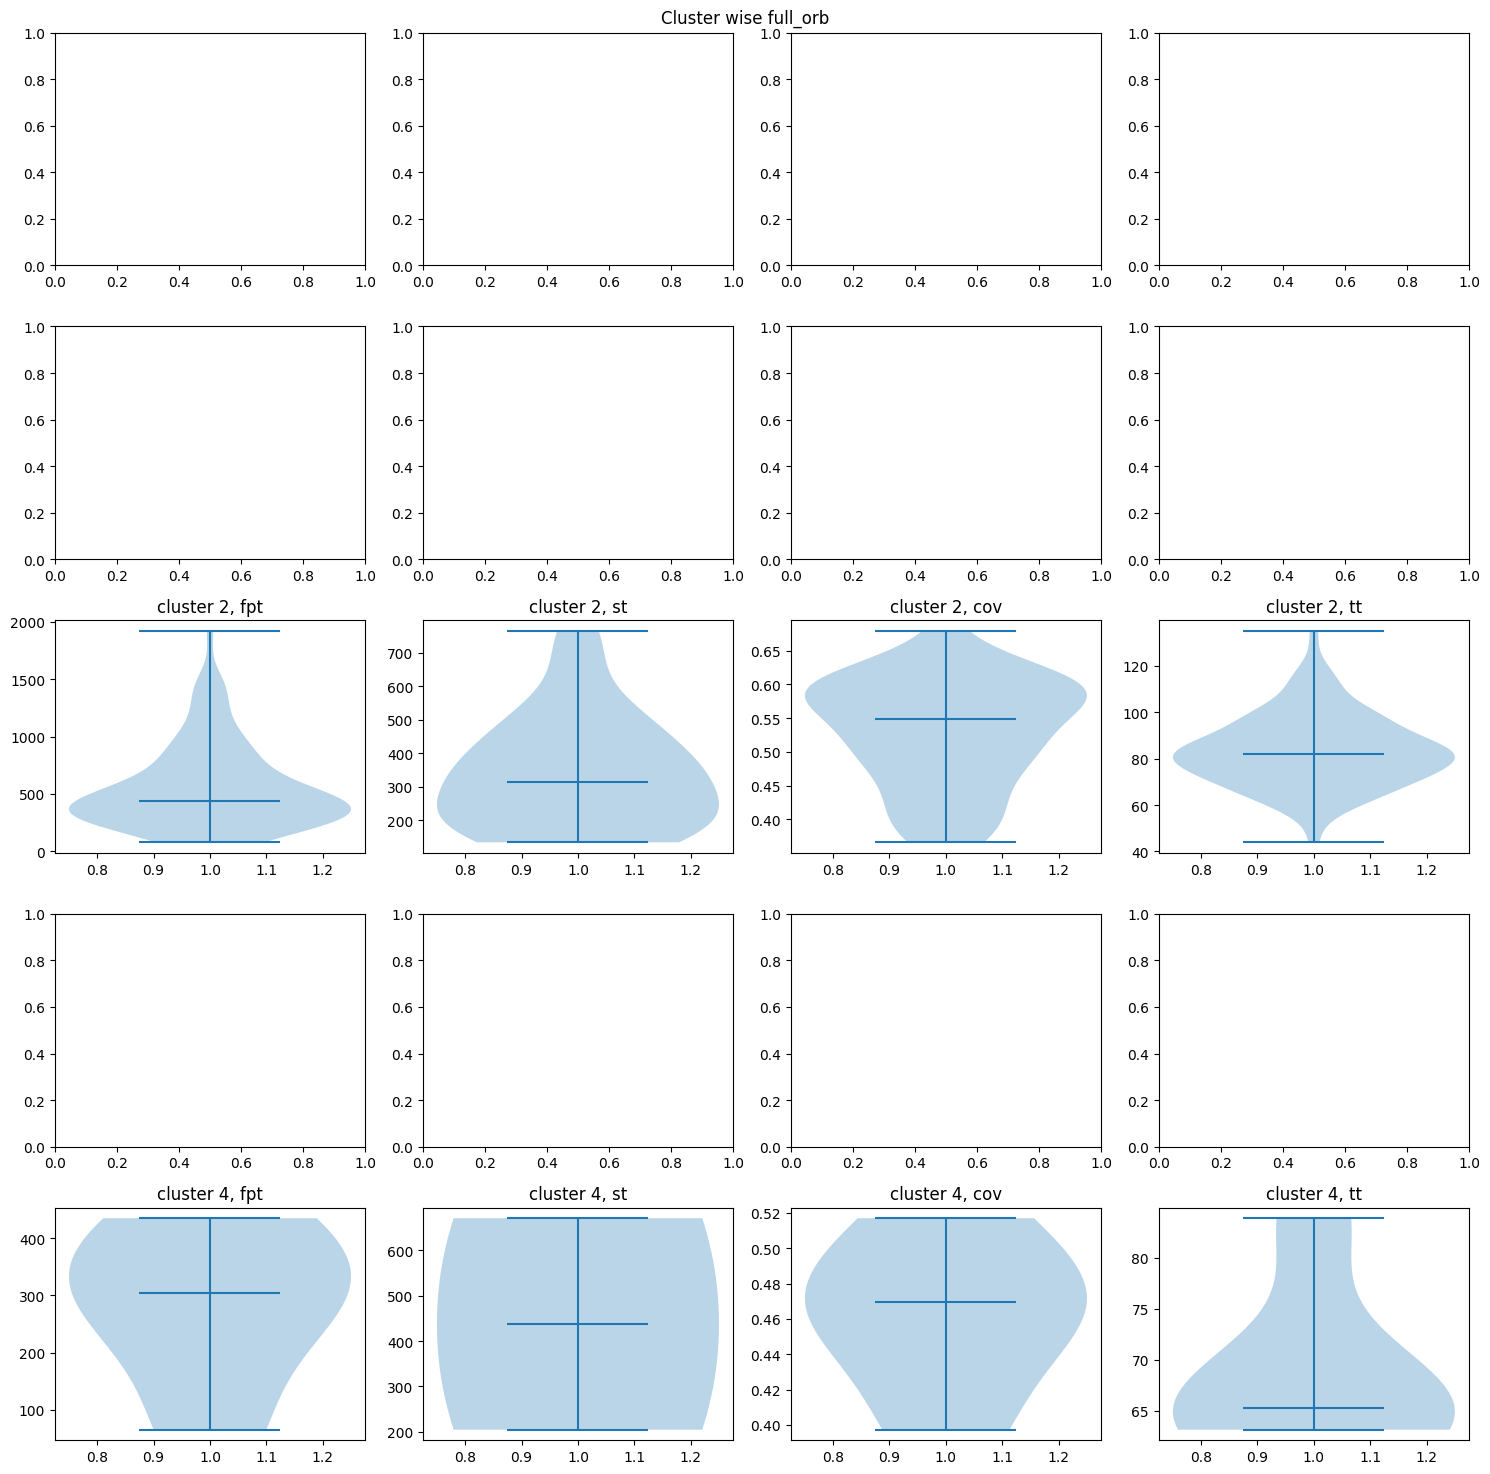

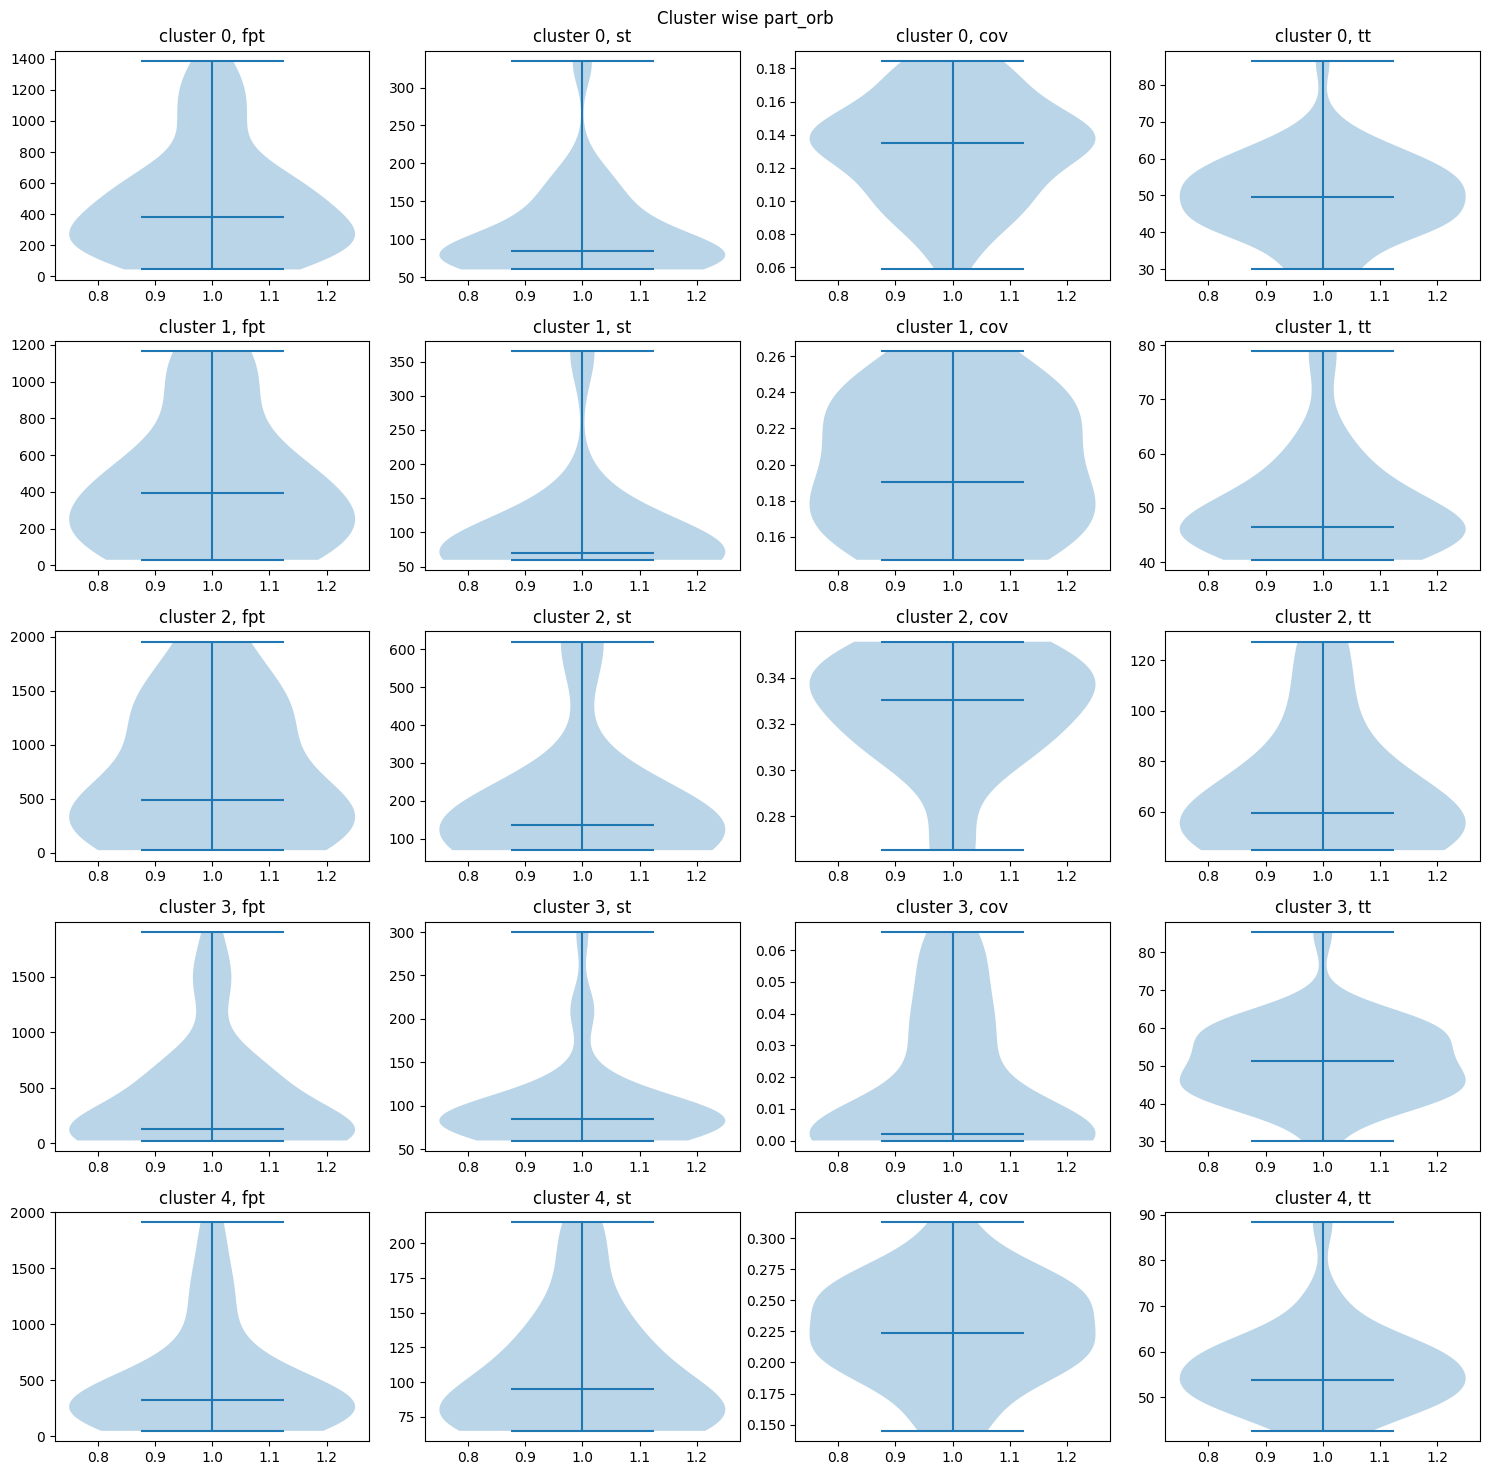

full_orb
full_peri


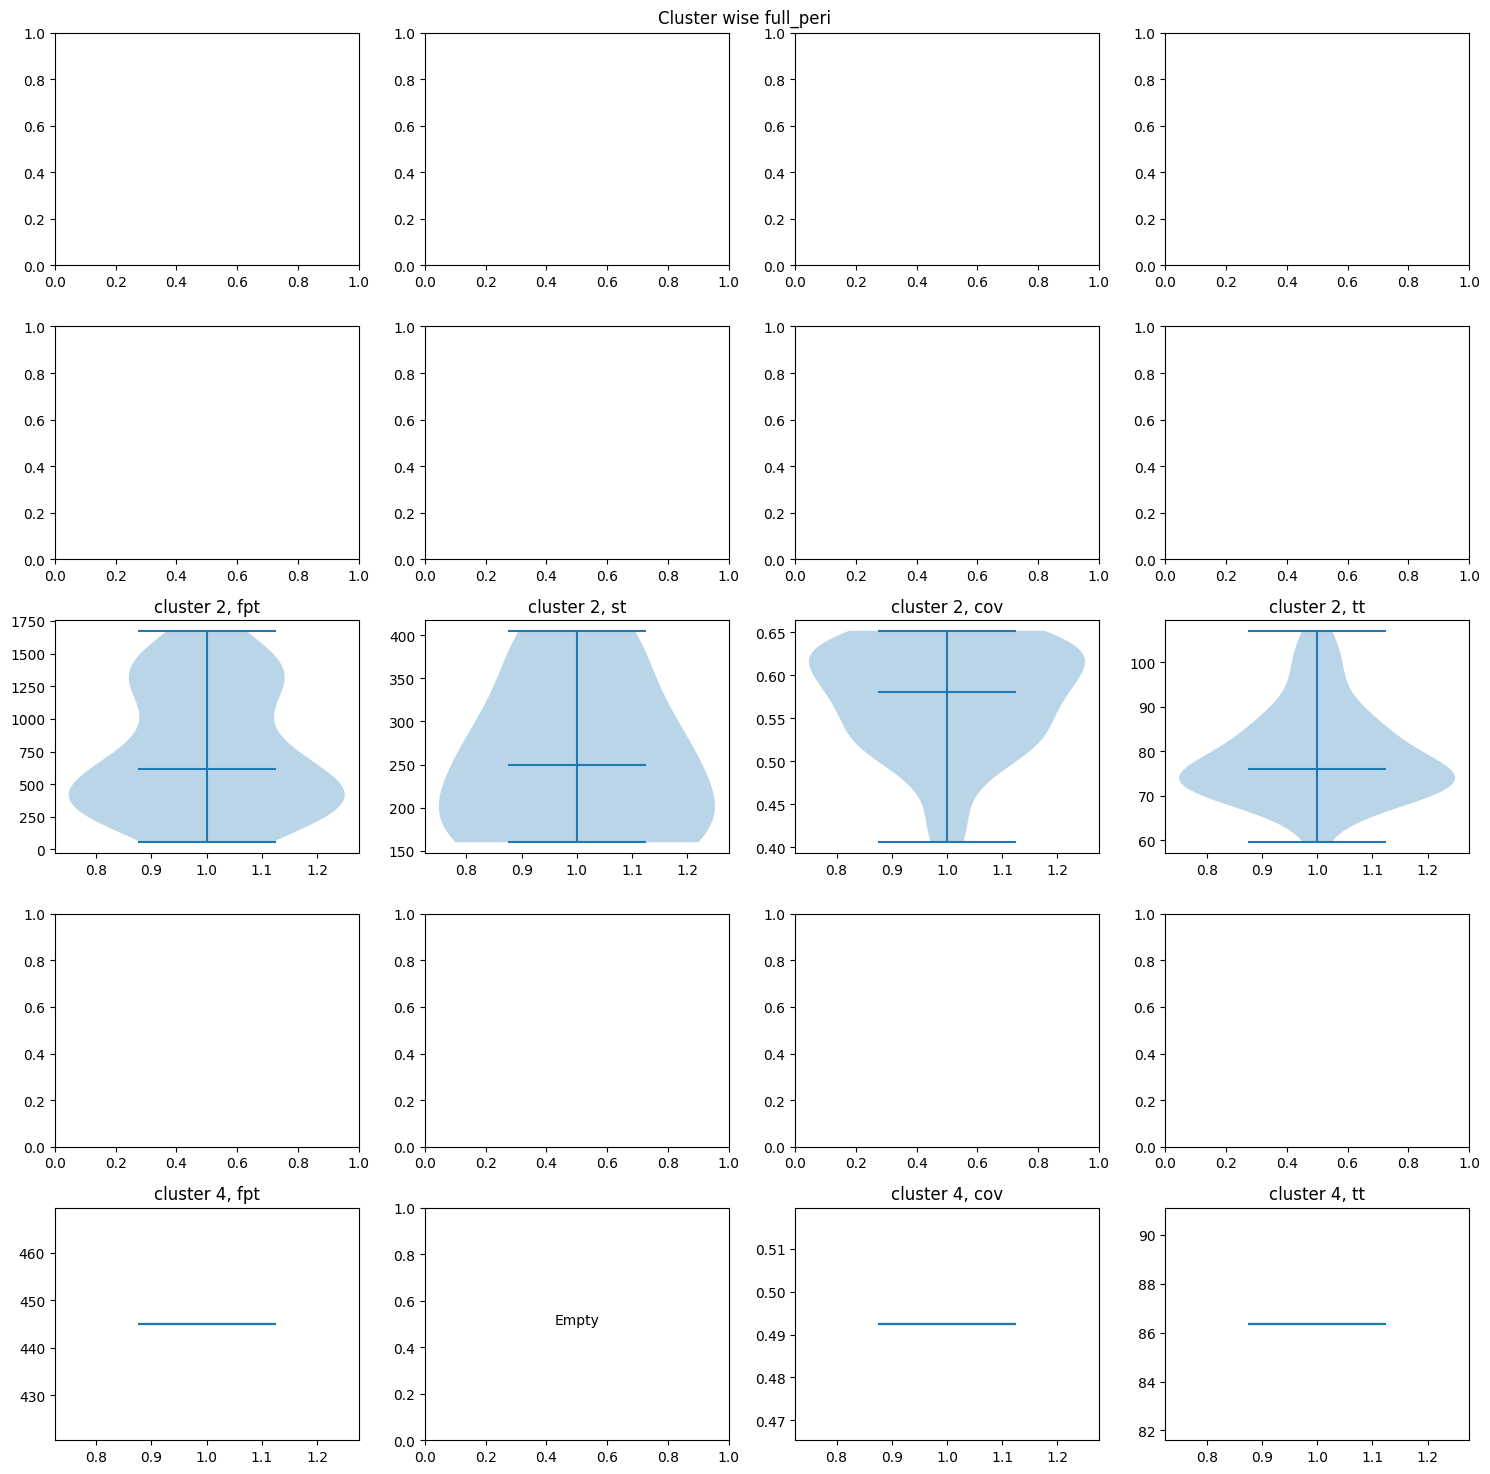

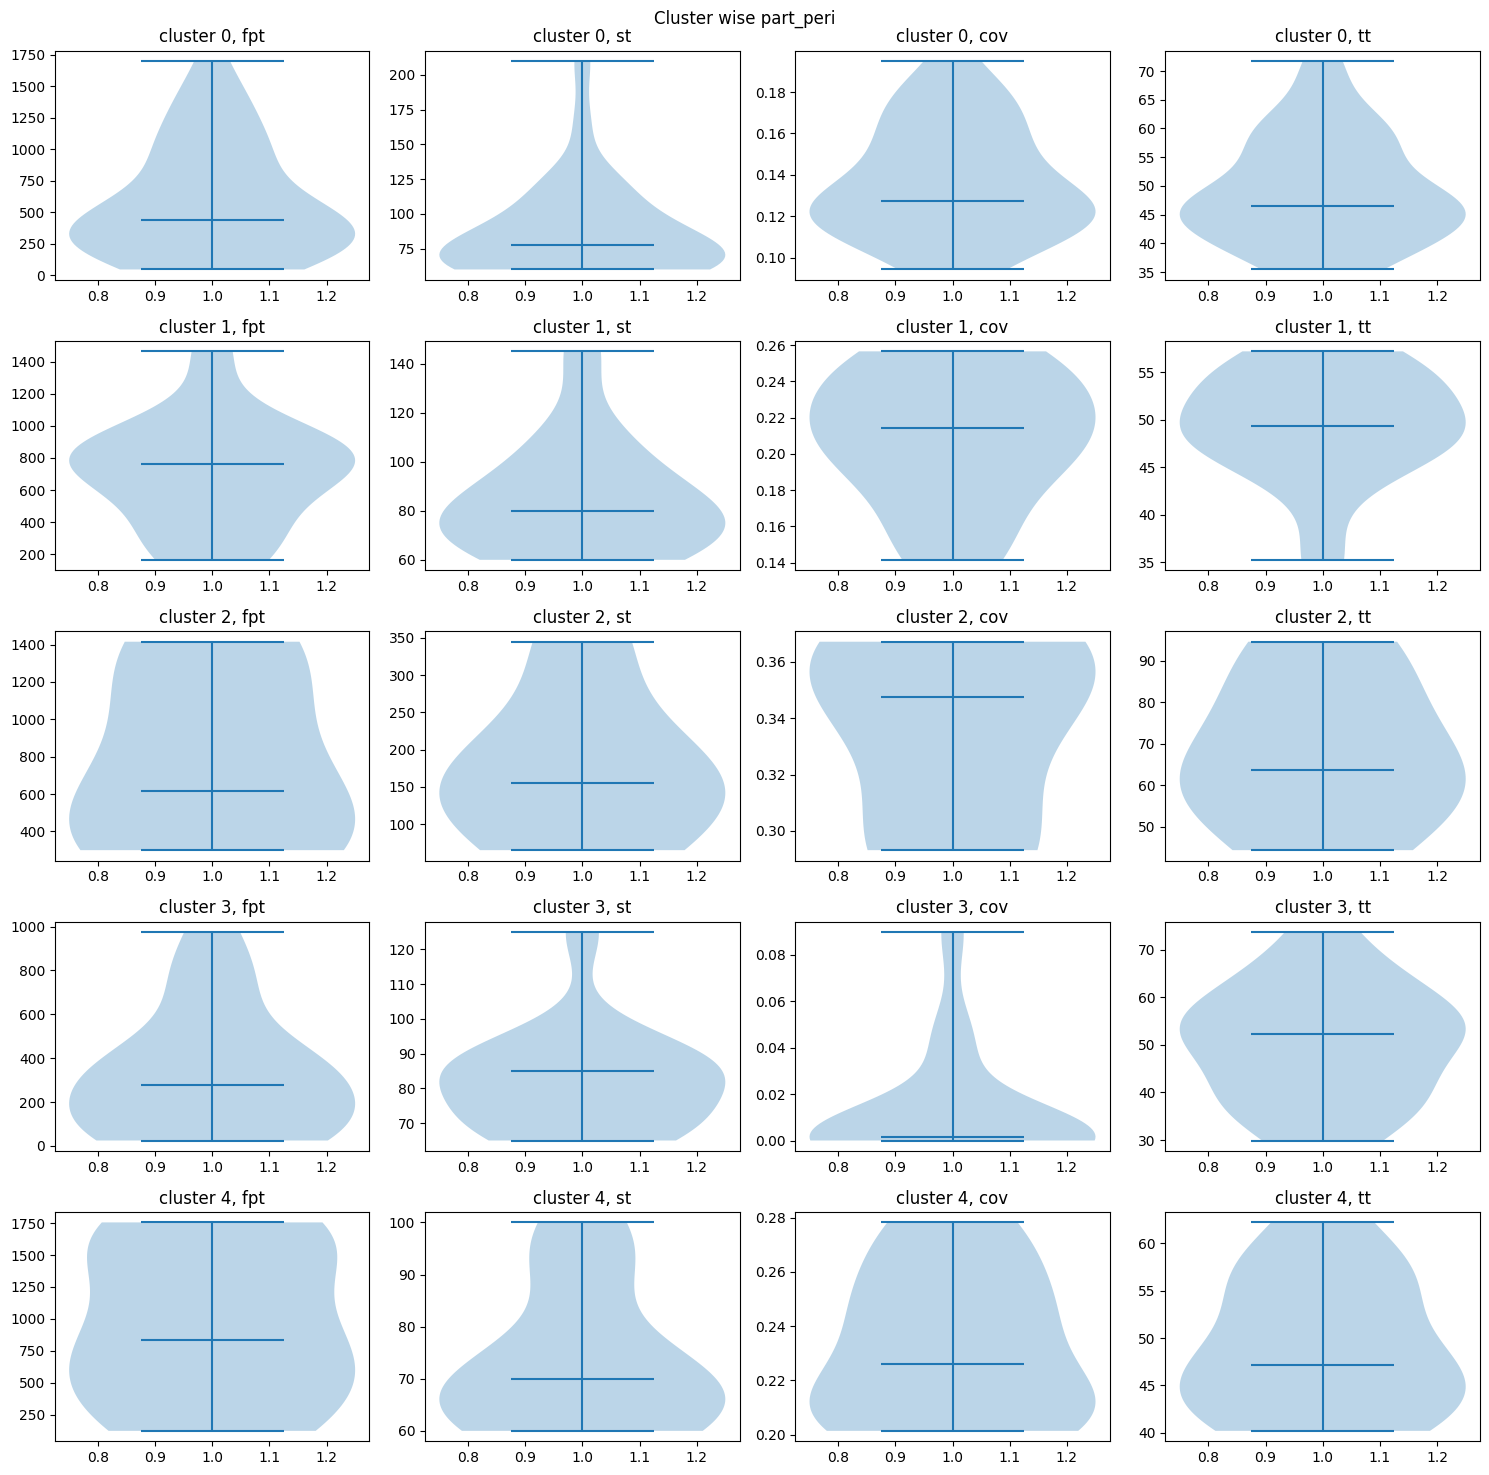

full_peri
full_pir


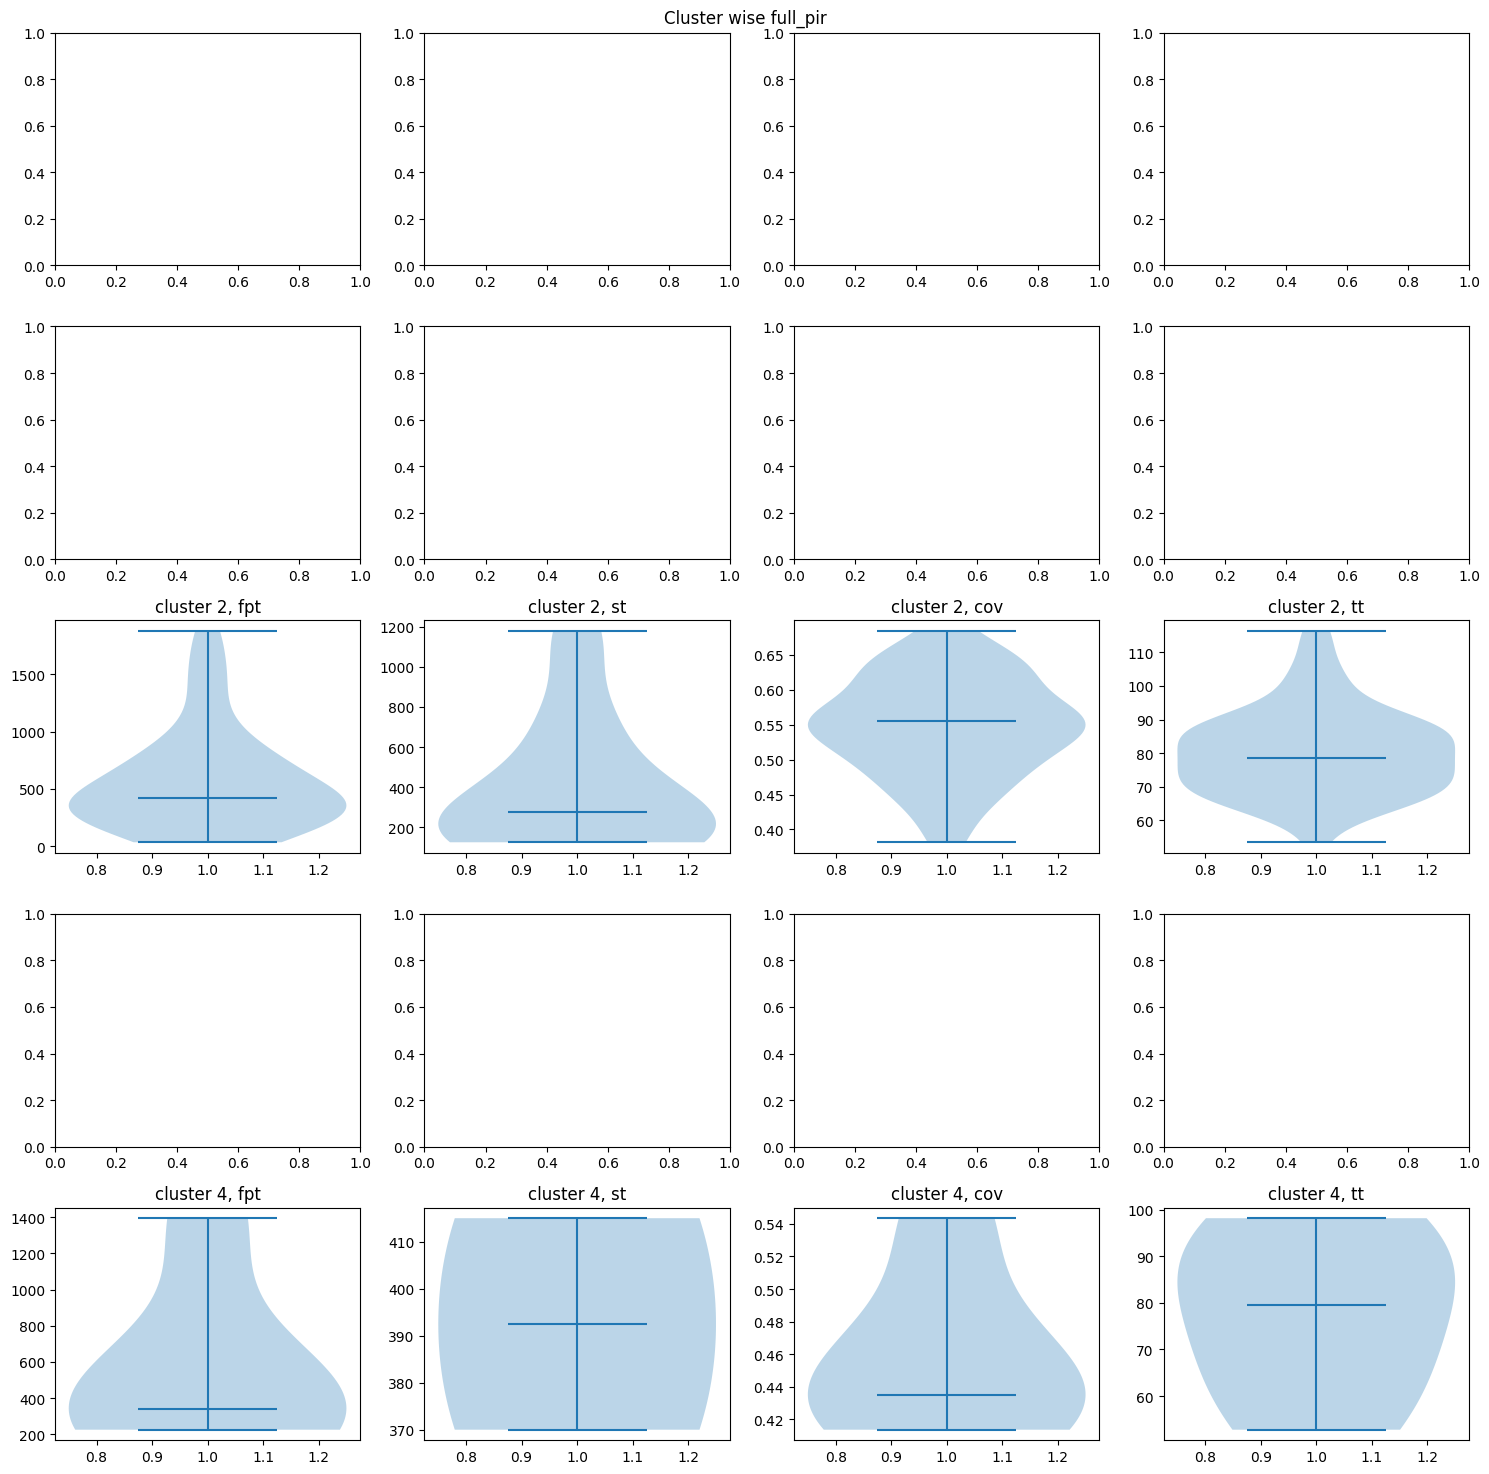

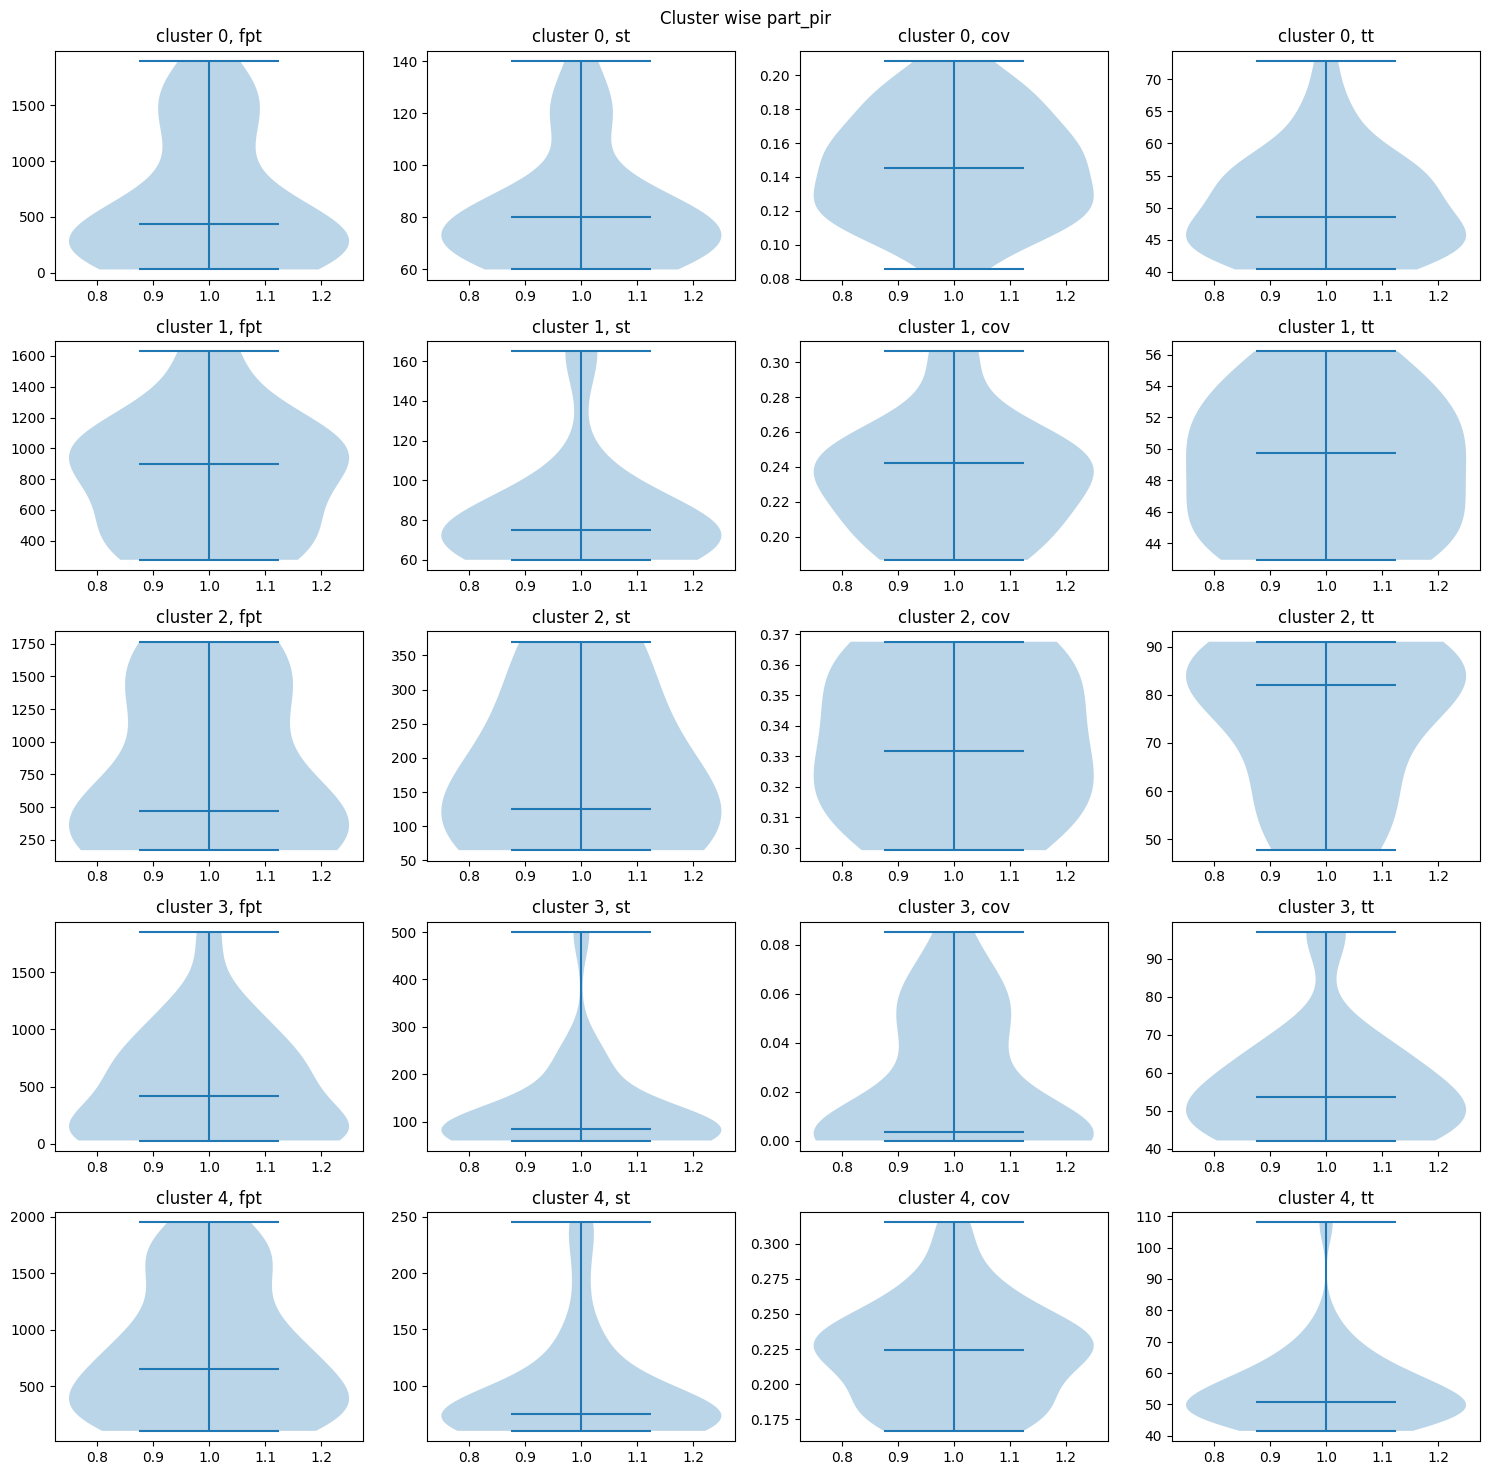

full_pir
full_re


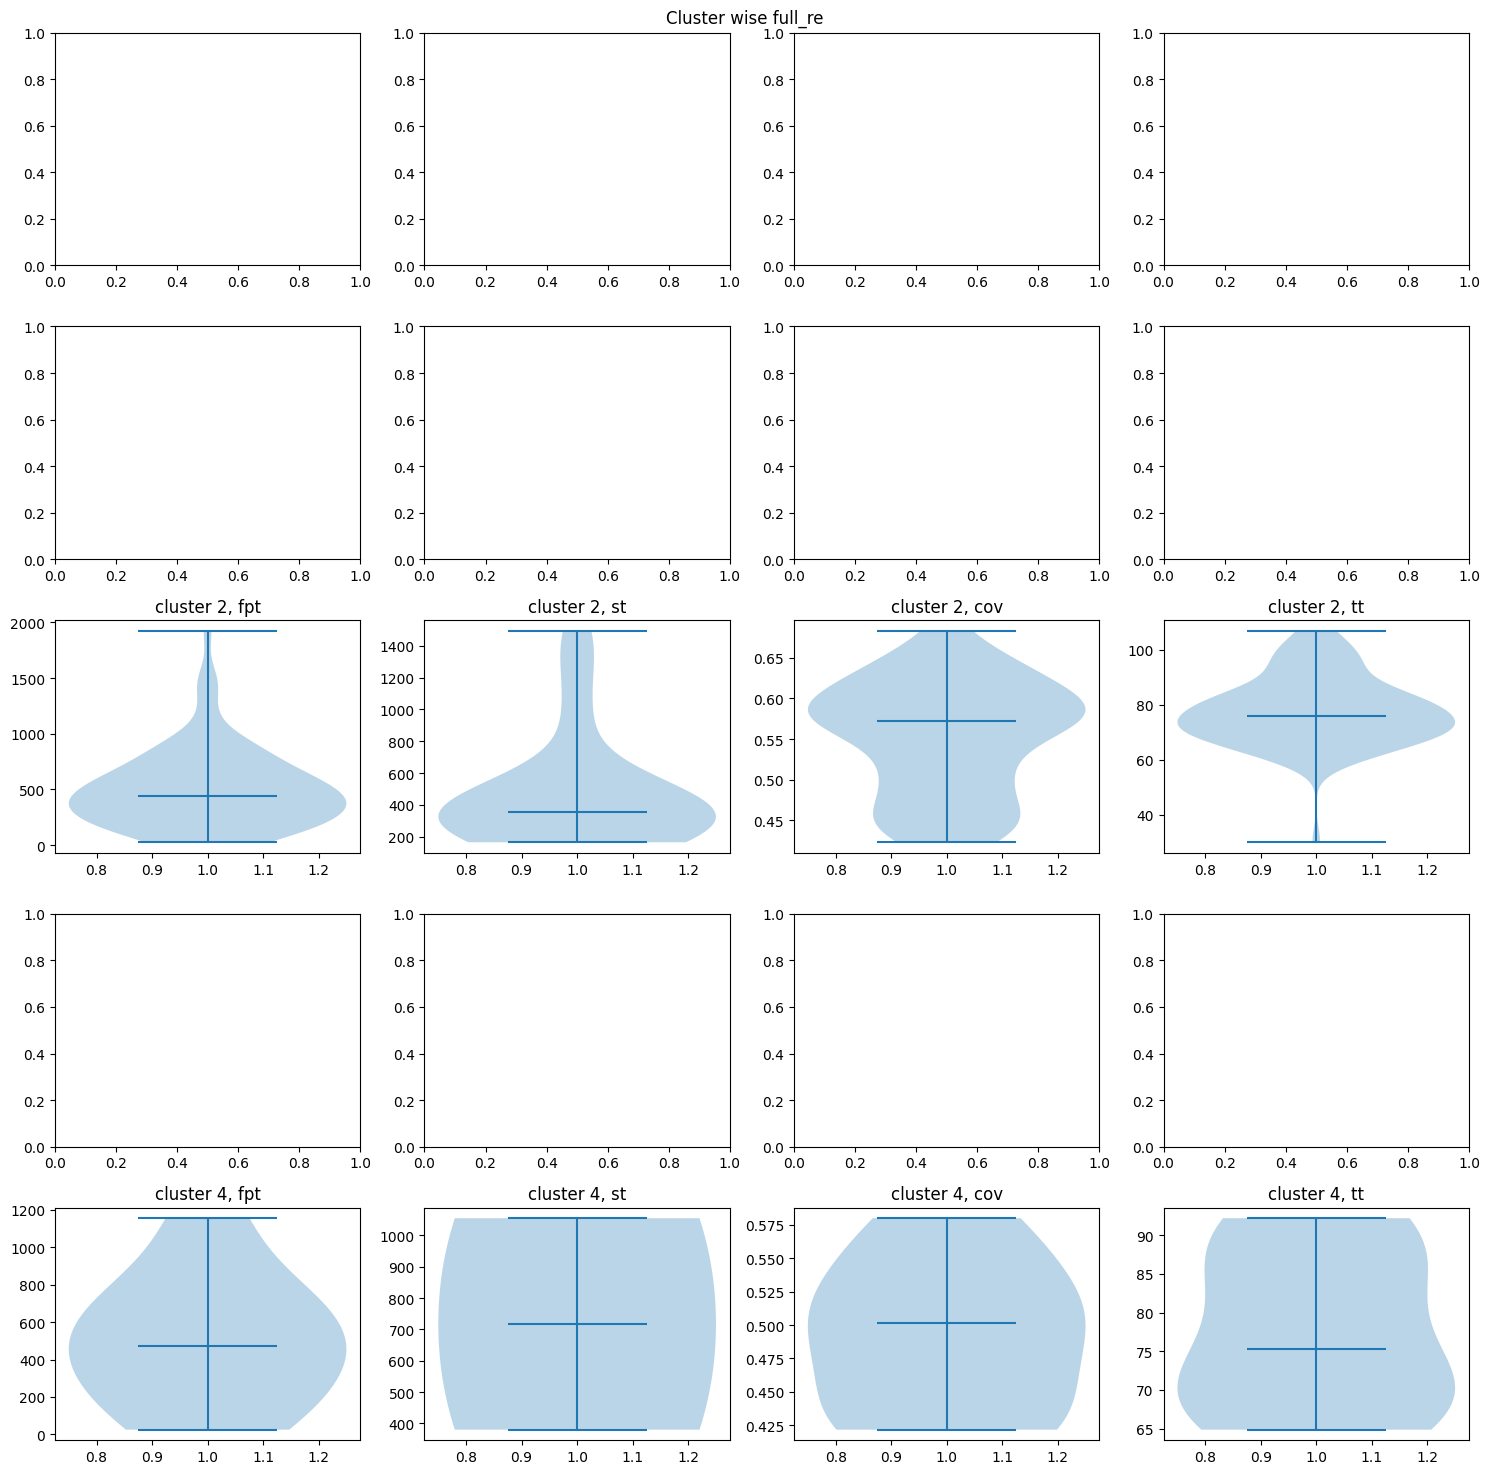

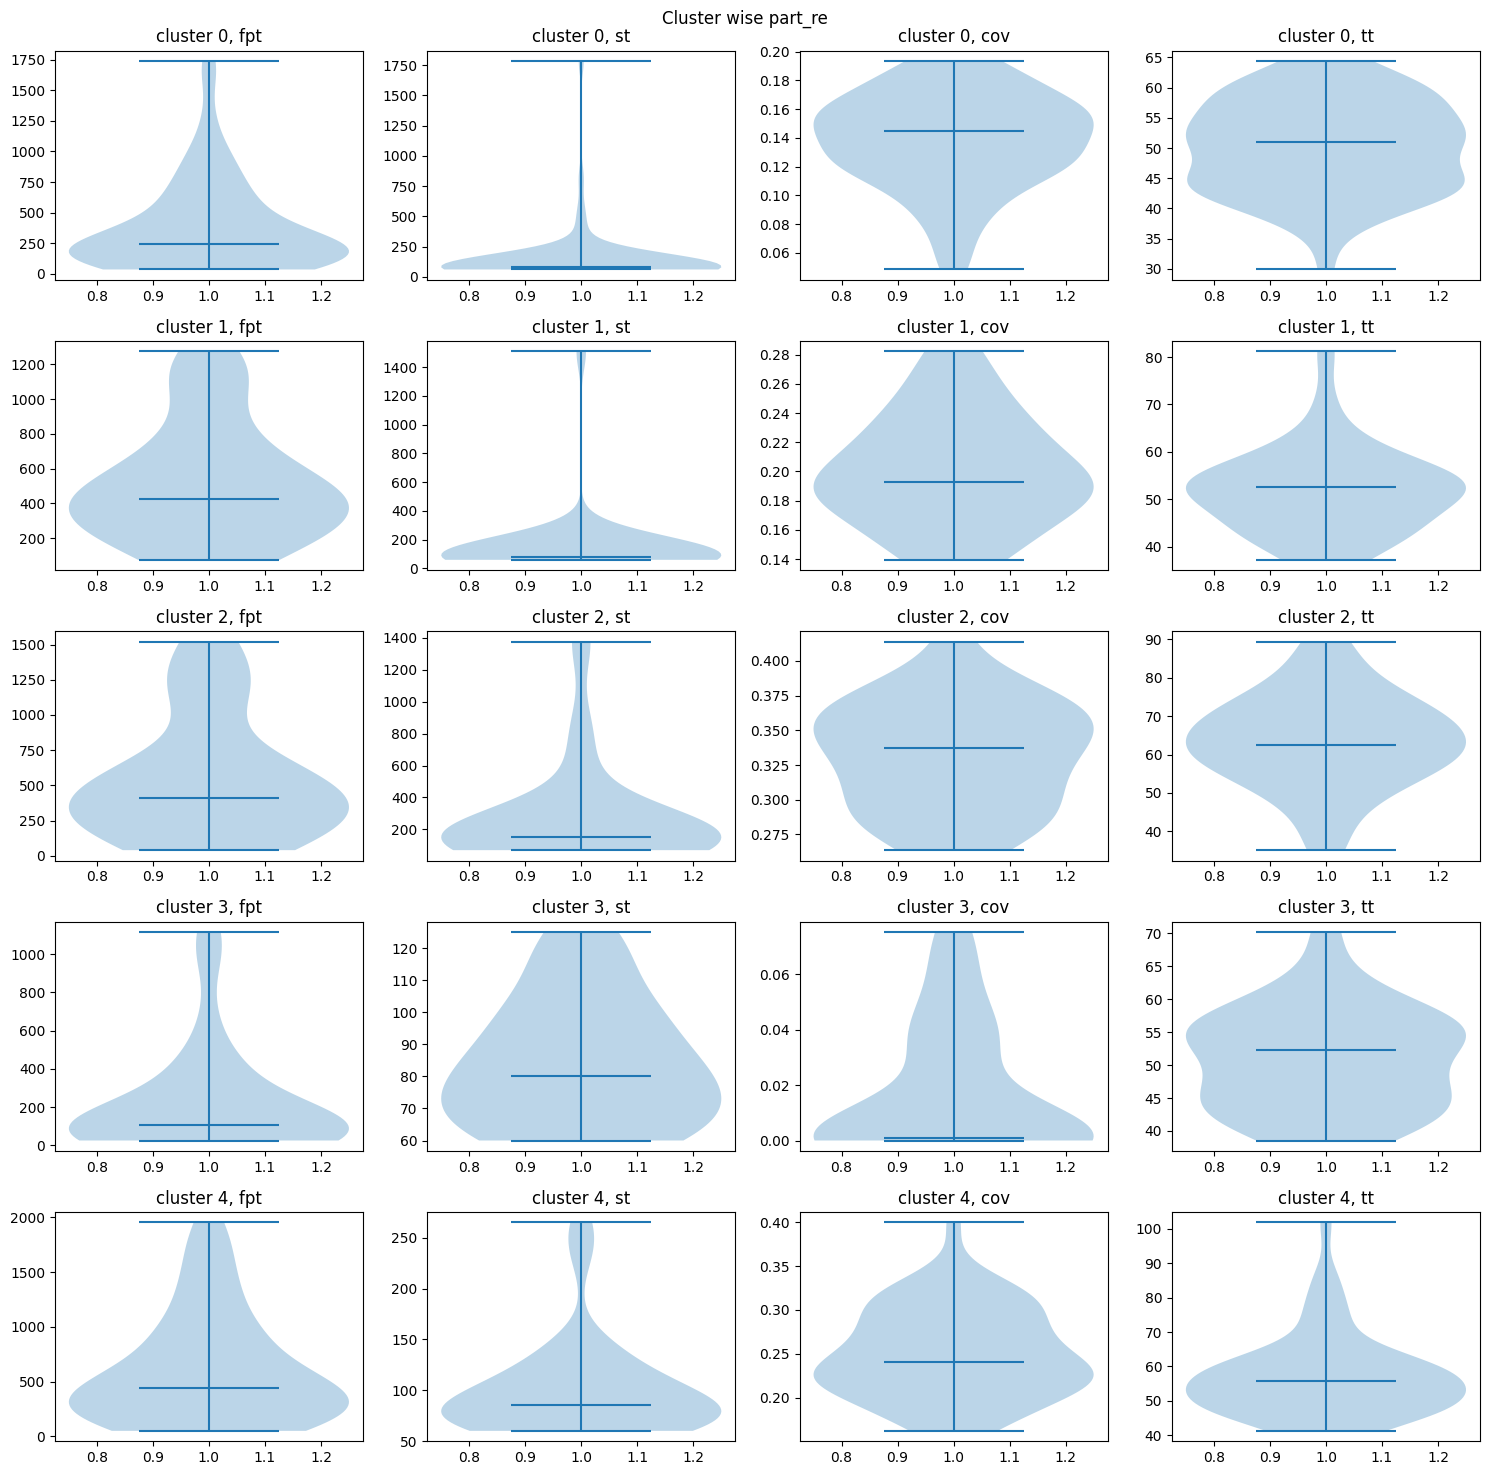

full_re


In [ ]:
for f_full, f_part in zip(file_full,file_part):
    print(f"full_{f_full.split('_')[-1]}")
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)

    plot_params(pkl_full,f"full_{f_full.split('_')[-1]}")

    with open(f_part, "rb") as f:
        pkl_part = pickle.load(f)

    plot_params(pkl_part,f"part_{f_part.split('_')[-1]}")

    print(f"full_{f_full.split('_')[-1]}")

#### Fit st and fpt clusterwise

In [5]:
def fit_piecewiseLinear(data):
    intervals=data.copy()
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)
    # Fit piecewise linear with 3 segments
    x=intervals
    y=log_ccdf
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breaks = my_pwlf.fit(2)
    # Predict
    y_hat = my_pwlf.predict(x)

    return [x,y,y_hat,breaks[1]]

    
    # ax.scatter(x, y)
    # ax.plot(x, y_hat, 'r')
    # ax.set_ylabel("log P(T > t)")
    # ax.set_title(f"Log-CCDF {label} {round(breaks[1])} (2 fits)")
    # ax.legend()
    

In [13]:
import numpy as np
import pandas as pd

def is_empty(arr):
    if arr is None:
        return True
    if isinstance(arr, (list, tuple)):
        return len(arr) == 0
    if isinstance(arr, np.ndarray):
        return arr.size == 0
    if isinstance(arr, (pd.Series, pd.DataFrame)):
        return arr.empty
    return False


In [25]:
def plot_fit(data, label):
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    key_list = ['fpt', 'st', 'cov', 'tt']
    colors = {0: "red", 1: "green", 2: "blue", 3: "orange", 4: "cyan"}
    
    for j in range(2):  # two subplots
        for i in data.keys():  # loop over your 5 dictionaries
            plt_data = data[i][key_list[j]]
            
            # check emptiness
            if plt_data is None or len(plt_data) == 0:
                ax = axes[j]
                ax.text(0.5, 0.5, "Empty", ha='center')
                continue
            
            ax = axes[j]
            try:
                # attempt fit
                l = fit_piecewiseLinear(plt_data)
                x, y, y_hat, breaks = l[0], l[1], l[2], round(l[3])
                
                # pick color based on i
                color = colors.get(i, "black")
                
                # scatter and line with chosen color
                ax.scatter(x, y, color=color, alpha=0.5, label=f"clust {i}")
                ax.plot(x, y_hat, color=color, alpha=0.5)
                
                ax.set_ylabel("log P(T > t)")
                ax.set_title(f"Log-CCDF {label} {key_list[j]}")
                ax.legend()
            
            except Exception as e:
                # if fit fails, skip gracefully
                ax.text(0.5, 0.5, f"Fit failed: cluster {i}", ha='center', fontsize=8)
    
    plt.tight_layout()
    

                
    plt.savefig(f'../../data/results/comm_umap_results/comm_wise_params/cw_{key_list[j]}{label}.pdf', format='pdf')

  


full_bla
full_bla
full_enti
full_enti
full_fn


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\pwlf\pwlf.py:1248: RuntimeWarning: invalid value encountered in divide
  self.slopes = np.divide(


full_fn
full_lha
full_lha
full_lsc


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\pwlf\pwlf.py:1248: RuntimeWarning: invalid value encountered in divide
  self.slopes = np.divide(


full_lsc
full_mob
full_mob
full_mop


...

full_peri
full_pir


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\pwlf\pwlf.py:1248: RuntimeWarning: invalid value encountered in divide
  self.slopes = np.divide(


full_pir
full_re


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\pwlf\pwlf.py:1248: RuntimeWarning: invalid value encountered in divide
  self.slopes = np.divide(


full_re


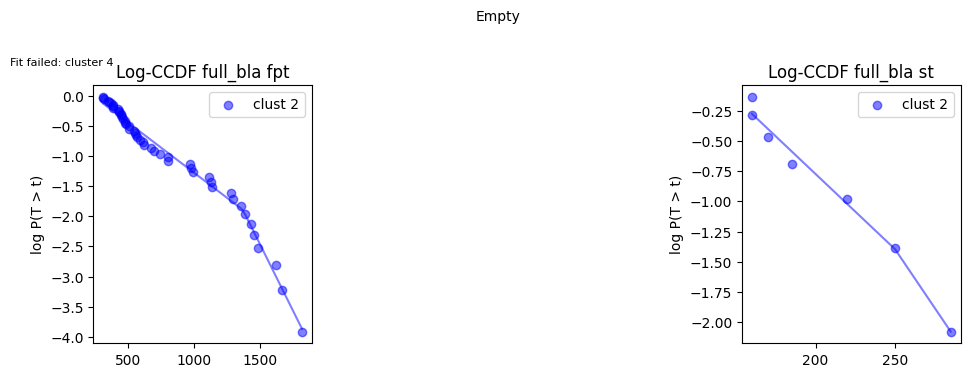

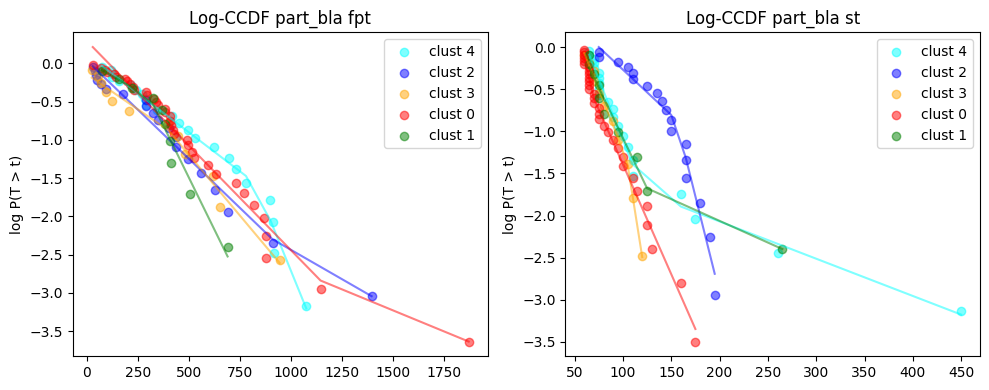

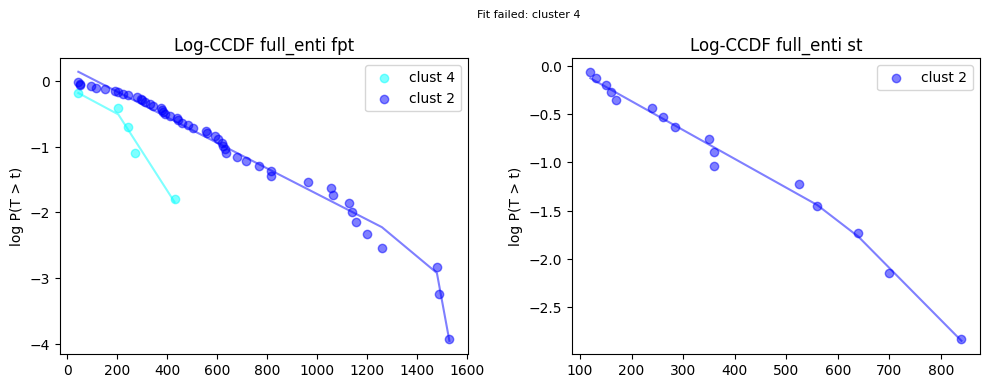

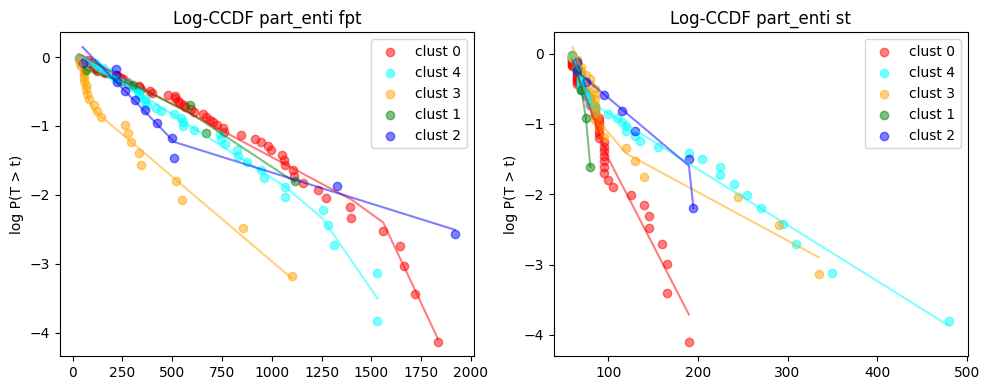

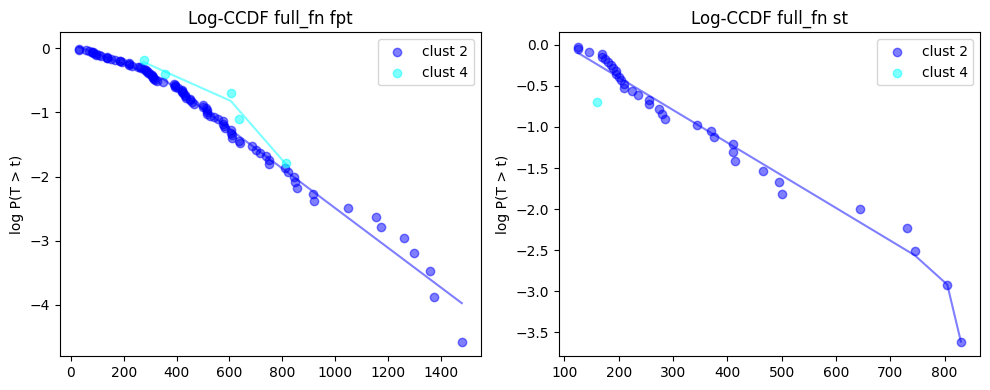

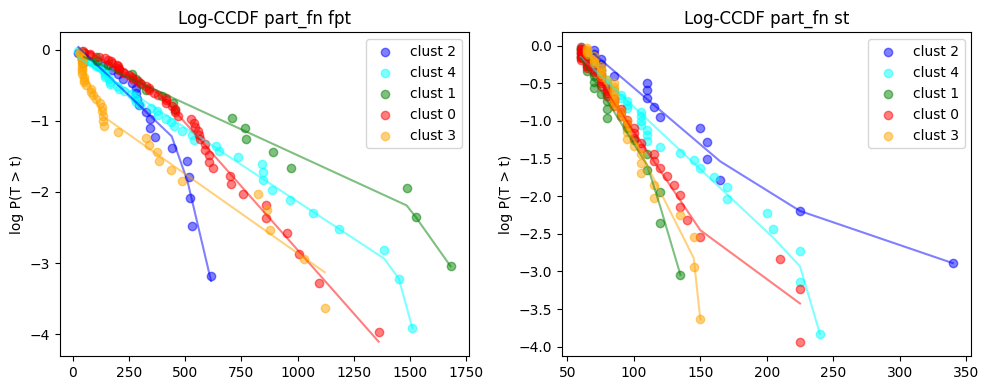

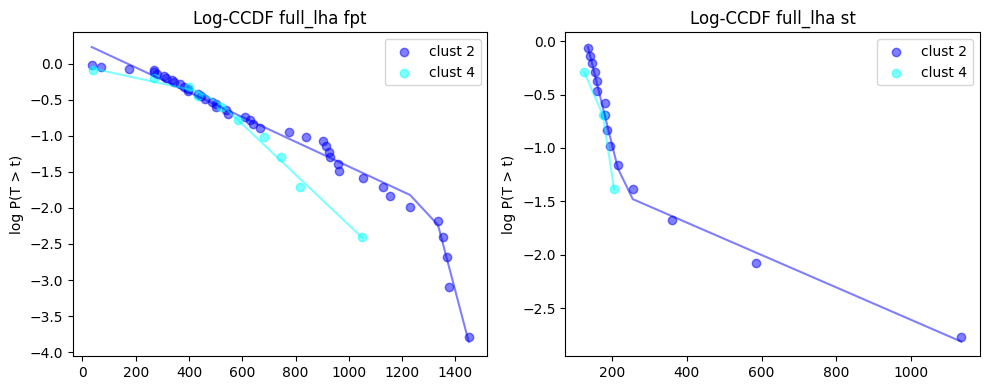

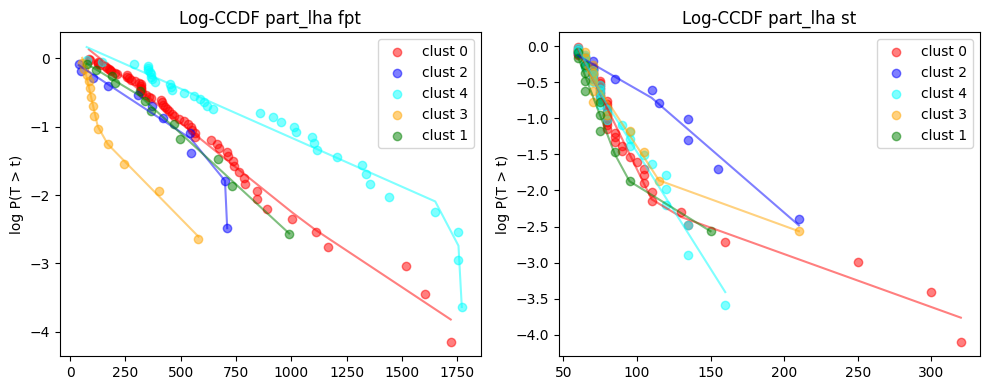

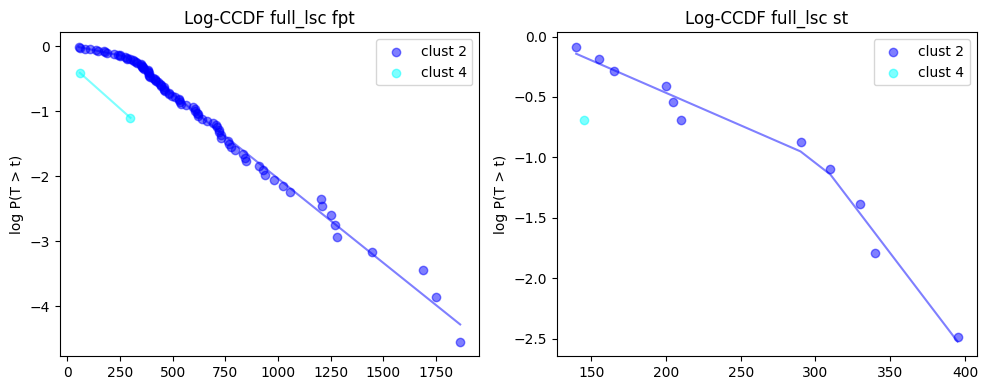

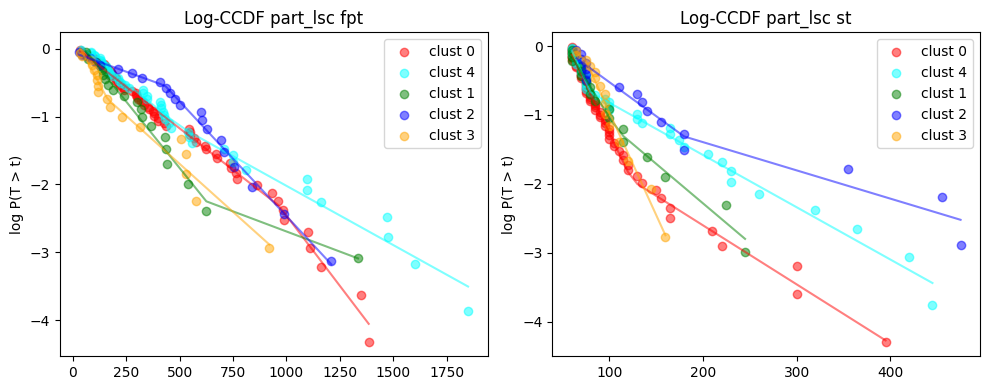

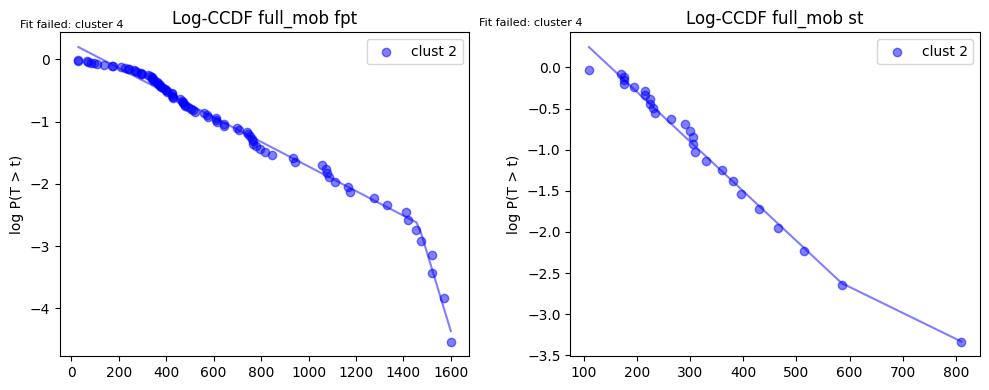

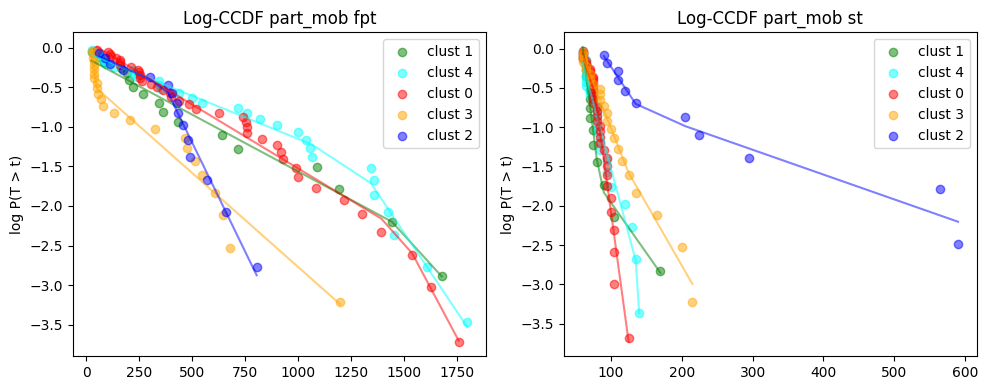

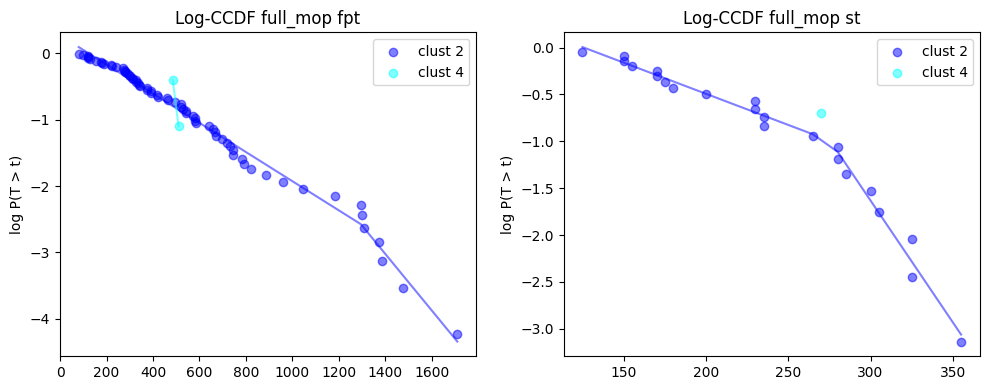

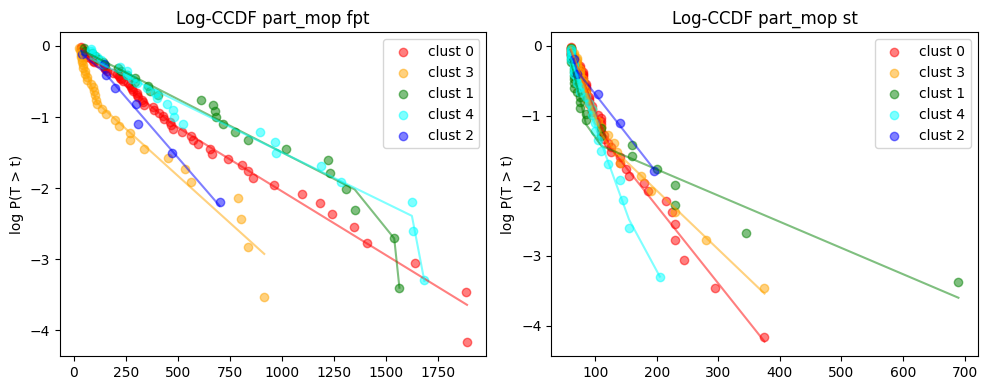

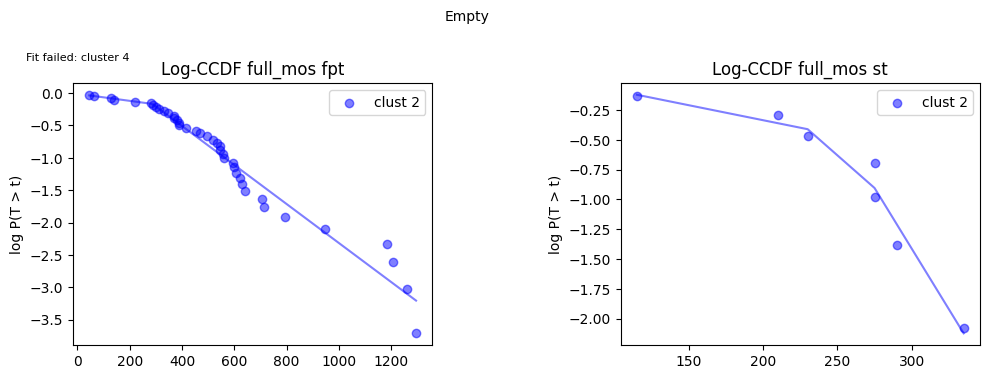

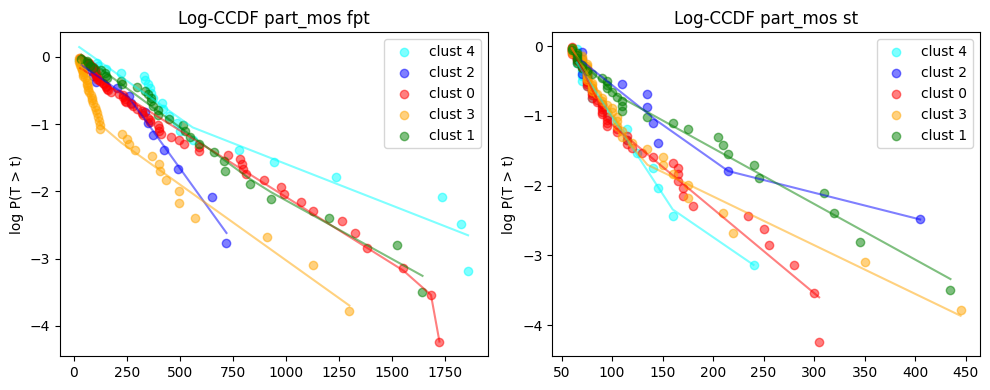

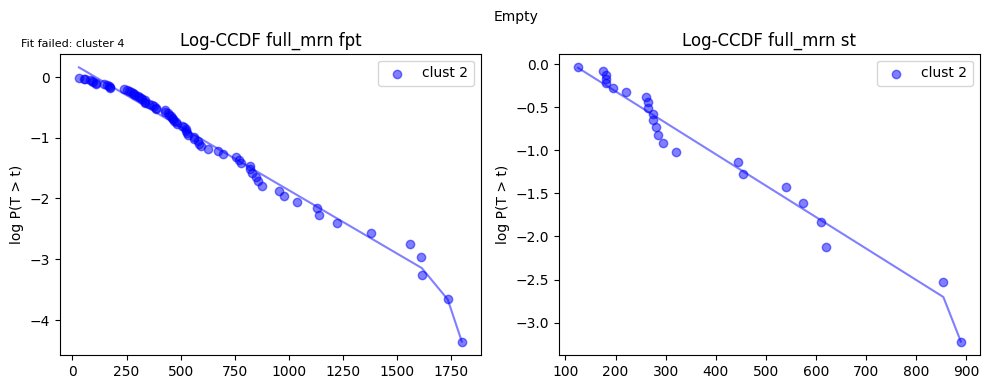

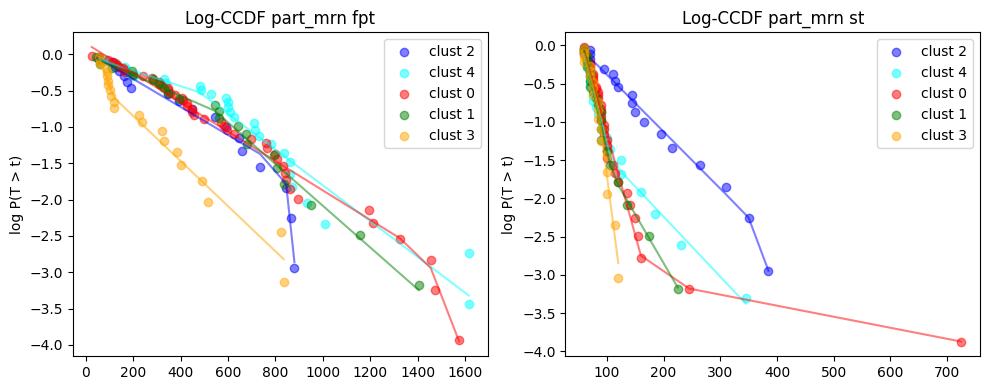

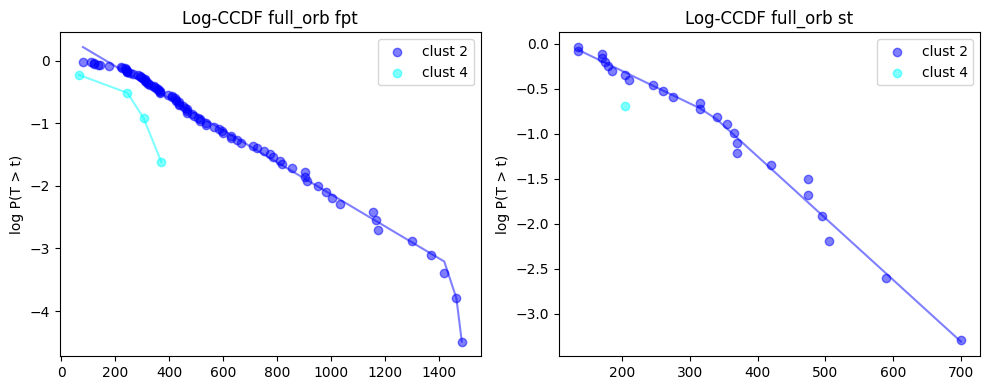

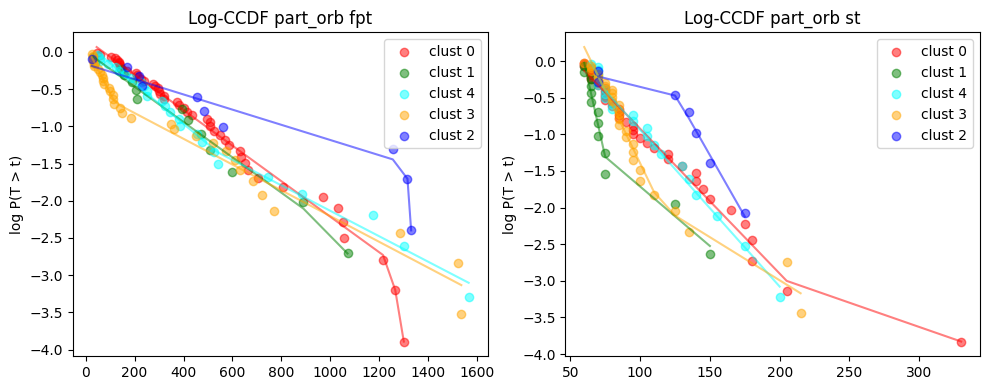

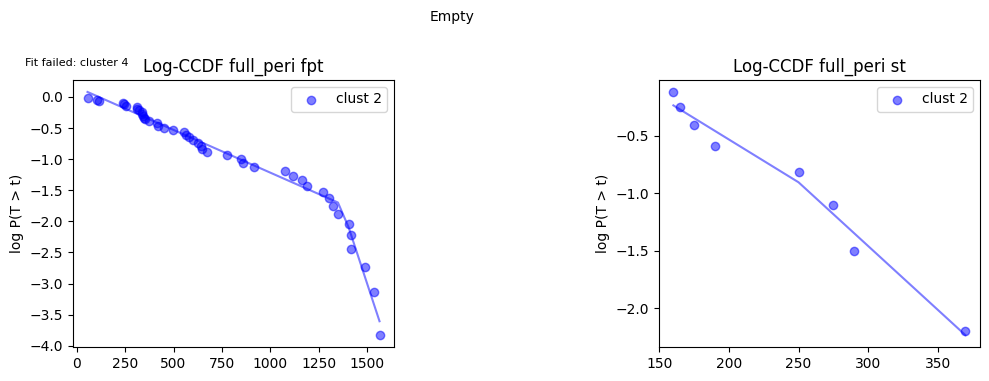

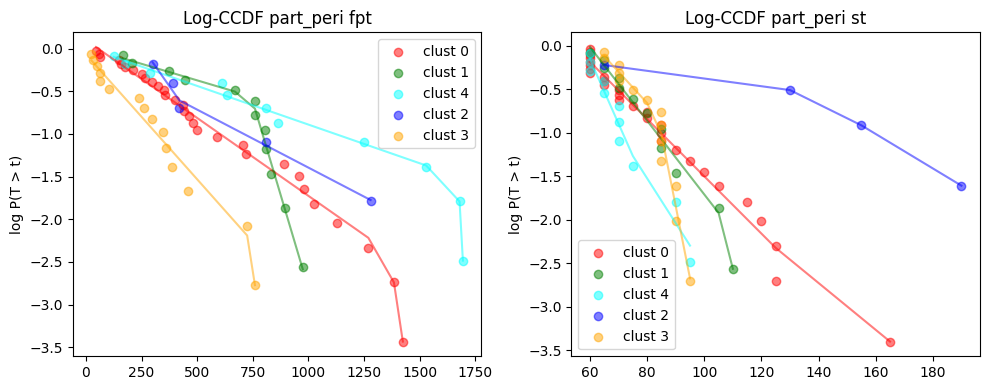

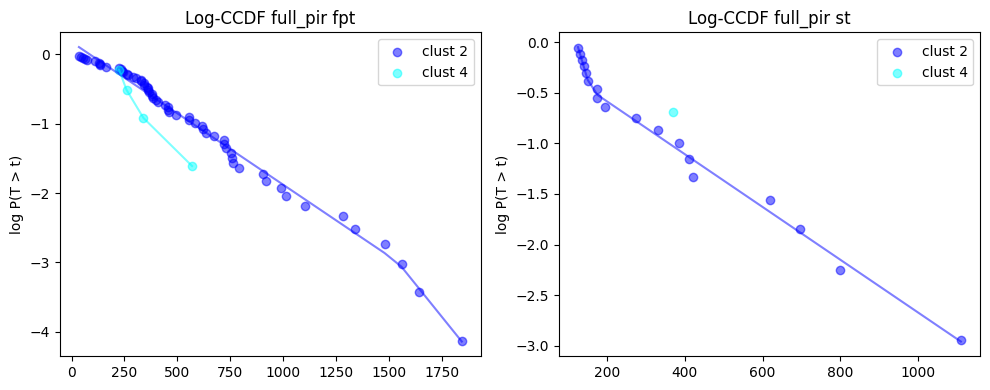

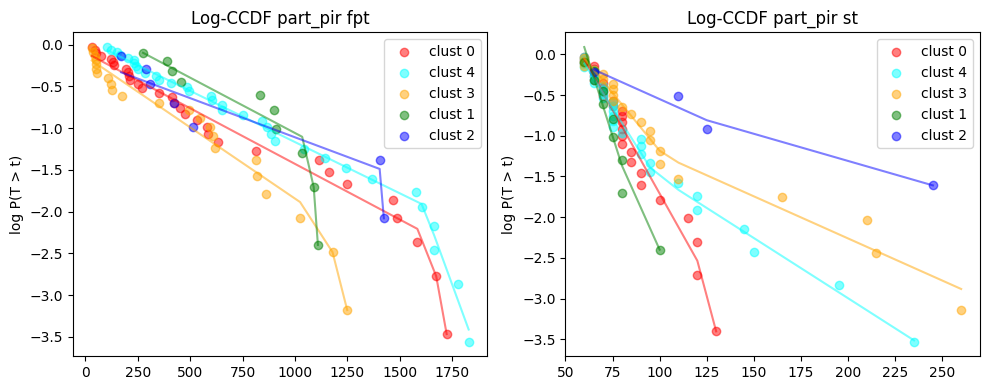

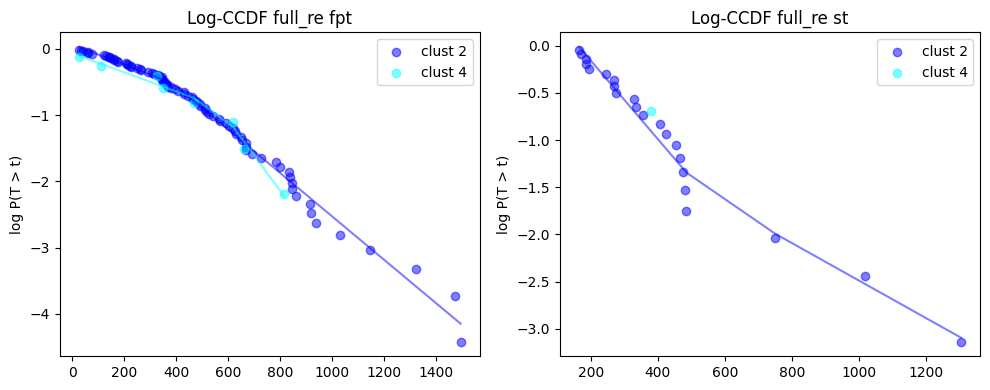

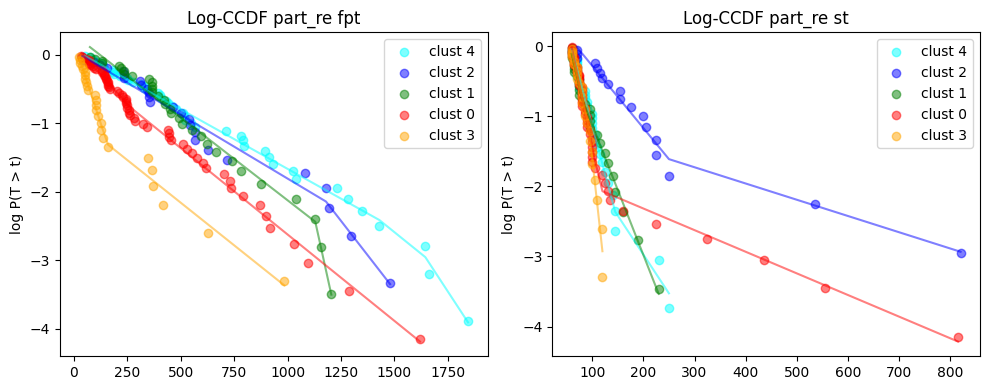

In [26]:
for f_full, f_part in zip(file_full,file_part):
    print(f"full_{f_full.split('_')[-1]}")
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)

    plot_fit(pkl_full,f"full_{f_full.split('_')[-1]}")

    with open(f_part, "rb") as f:
        pkl_part = pickle.load(f)

    plot_fit(pkl_part,f"part_{f_part.split('_')[-1]}")

    print(f"full_{f_full.split('_')[-1]}")